# 19. Machine Learning and Neural Forecasting for Uncertainty-Aware Kelly Allocation

In [9]:
from pathlib import Path
import math
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from joblib import Parallel, delayed
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from threadpoolctl import threadpool_limits

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_nfci, load_yfinance_panel, prices_to_returns_panel
from quantfinlab.ml.features import (
    assemble_forecasting_table,
    breadth,
    build_fci_feature_block,
    clean_feature_columns,
    dispersion,
    drawdown_level,
    realized_vol,
    regime_probability_features,
    relative_return,
    rolling_avg_corr,
    skip_return,
    total_return,
)
from quantfinlab.plotting.curves import set_plot_style
from quantfinlab.plotting.diagrams import (
    activation_loss,
    mlp_architecture,
    lstm_architecture,
    tcn_receptive_field,
    sequence_memory_comparison,
    quantile_forecast,
    linear_regularization_comparison,
    hist_gradient_boosting_diagram
)
from quantfinlab.plotting.portfolio import (
    confidence_exposure_map,
    conformal_shift_chart,
    coverage_reliability,
    disagreement_error_map,
    feature_correlation_map,
    feature_importance_bars,
    forecast_buckets_chart,
    forecast_scatter,
    forecast_to_weight_map,
    kelly_shrinkage_curve,
    kelly_weight_path,
    pca_explained_variance,
    plot_rolling_sharpe,
    plot_strategy_drawdowns,
    plot_strategy_nav,
    rolling_ic_chart,
    target_by_asset,
    target_distribution,
    target_stability,
    uncertainty_error_map,
)
from quantfinlab.portfolio import covariance, expected_returns, optimizers
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary
from quantfinlab.portfolio.universe import make_rebalance_dates
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.reports.risk_report import risk_report

warnings.filterwarnings("ignore")
set_plot_style()

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
annualization = 252.0
cost_bps = 10.0

data_path = Path("../data") if Path("../data/core_cross_asset_etfs.csv").exists() else Path("data")

cpu_count = os.cpu_count() or 1
outer_n_jobs = max(1, min(4, cpu_count))
forest_inner_jobs = max(1, cpu_count // outer_n_jobs)
print({"device": str(device), "cpu_count": cpu_count, "outer_jobs": outer_n_jobs, "forest_inner_jobs": forest_inner_jobs})


{'device': 'cuda', 'cpu_count': 8, 'outer_jobs': 4, 'forest_inner_jobs': 2}


In [ ]:
def _clean_pair(data, y_col, pred_col):
    return (
        data[[y_col, pred_col]]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )


def _spearman(x, y):
    if len(x) < 3 or x.nunique(dropna=True) < 2 or y.nunique(dropna=True) < 2:
        return np.nan
    return float(spearmanr(x, y).correlation)


def pinball_loss(y_true, y_pred, tau):
    y = pd.Series(y_true, dtype=float)
    q = pd.Series(y_pred, dtype=float).reindex(y.index)
    err = y - q
    return float(pd.Series(np.maximum(float(tau) * err, (float(tau) - 1.0) * err)).replace([np.inf, -np.inf], np.nan).dropna().mean())


def interval_coverage(y, q_low, q_high):
    yy = pd.Series(y, dtype=float)
    lo = pd.Series(q_low, dtype=float).reindex(yy.index)
    hi = pd.Series(q_high, dtype=float).reindex(yy.index)
    d = pd.concat([yy.rename("y"), lo.rename("lo"), hi.rename("hi")], axis=1).dropna()
    return float(d["y"].between(d["lo"], d["hi"]).mean()) if len(d) else np.nan


def interval_width(q_low, q_high):
    lo = pd.Series(q_low, dtype=float)
    hi = pd.Series(q_high, dtype=float).reindex(lo.index)
    w = (hi - lo).replace([np.inf, -np.inf], np.nan).dropna()
    return float(w.mean()) if len(w) else np.nan


def forecast_metrics(data, *, y_col, prediction_cols):
    rows = []
    for col in prediction_cols:
        if col not in data.columns:
            continue
        pair = _clean_pair(data, y_col, col)
        if pair.empty:
            continue
        err = pair[col] - pair[y_col]
        rows.append({
            "model": col,
            "n": int(len(pair)),
            "MAE": float(err.abs().mean()),
            "RMSE": float(np.sqrt(np.mean(np.square(err)))),
            "Spearman IC": _spearman(pair[col], pair[y_col]),
            "Directional Accuracy": float((np.sign(pair[col]) == np.sign(pair[y_col])).mean()),
            "Bias": float(err.mean()),
        })
    return pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()


def rank_metrics(data, *, date_col, asset_col, y_col, prediction_cols, top_frac=0.25):
    rows = []
    for col in prediction_cols:
        if col not in data.columns:
            continue
        daily_ic, daily_spread, daily_hit, daily_mono = [], [], [], []
        for _, group in data[[date_col, asset_col, y_col, col]].dropna().groupby(date_col):
            if len(group) < 4:
                continue
            daily_ic.append(_spearman(group[col], group[y_col]))
            n = max(1, int(np.ceil(len(group) * float(top_frac))))
            ordered = group.sort_values(col)
            daily_spread.append(float(ordered.tail(n)[y_col].mean() - ordered.head(n)[y_col].mean()))
            pred_top = set(ordered.tail(n)[asset_col].astype(str))
            actual_top = set(group.sort_values(y_col).tail(n)[asset_col].astype(str))
            daily_hit.append(float(len(pred_top & actual_top) / max(1, n)))
            try:
                bucket = pd.qcut(group[col].rank(method="first"), min(5, len(group)), labels=False) + 1
                bucket_mean = group.assign(_bucket=bucket.astype(int)).groupby("_bucket")[y_col].mean()
                daily_mono.append(_spearman(pd.Series(bucket_mean.index, dtype=float), bucket_mean.astype(float)))
            except ValueError:
                pass
        ic = pd.Series(daily_ic, dtype=float)
        rows.append({
            "model": col,
            "mean_rank_ic": float(ic.mean()) if len(ic) else np.nan,
            "rank_ic_t": float(ic.mean() / ic.std(ddof=1) * np.sqrt(len(ic))) if len(ic) > 2 and ic.std(ddof=1) > 0 else np.nan,
            "bucket_spread": float(pd.Series(daily_spread, dtype=float).mean()) if daily_spread else np.nan,
            "top_k_hit_rate": float(pd.Series(daily_hit, dtype=float).mean()) if daily_hit else np.nan,
            "bucket_monotonicity": float(pd.Series(daily_mono, dtype=float).mean()) if daily_mono else np.nan,
            "positive_ic_share": float((ic > 0).mean()) if len(ic) else np.nan,
        })
    return pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()


def forecast_buckets(data, *, date_col, y_col, score_col, n_buckets=5):
    rows = []
    for dt, group in data[[date_col, y_col, score_col]].dropna().groupby(date_col):
        if len(group) < int(n_buckets):
            continue
        try:
            bucket = pd.qcut(group[score_col].rank(method="first"), int(n_buckets), labels=False) + 1
        except ValueError:
            continue
        rows.append(group.assign(bucket=bucket.astype(int), date=pd.Timestamp(dt)))
    if not rows:
        return pd.DataFrame(columns=["bucket", "mean", "median", "count"])
    stacked = pd.concat(rows, ignore_index=True)
    out = stacked.groupby("bucket")[y_col].agg(["mean", "median", "count"])
    out.index.name = "bucket"
    return out


def quantile_metrics(data, *, y_col, quantile_sets):
    rows = []
    for name, (low_col, mid_col, high_col) in quantile_sets.items():
        cols = [y_col, low_col, mid_col, high_col]
        if not set(cols).issubset(data.columns):
            continue
        d = data[cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if d.empty:
            continue
        rows.append({
            "model": str(name),
            "n": int(len(d)),
            "coverage_80": interval_coverage(d[y_col], d[low_col], d[high_col]),
            "avg_width": interval_width(d[low_col], d[high_col]),
            "pinball_q10": pinball_loss(d[y_col], d[low_col], 0.10),
            "pinball_q50": pinball_loss(d[y_col], d[mid_col], 0.50),
            "pinball_q90": pinball_loss(d[y_col], d[high_col], 0.90),
        })
    return pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()


def conformal_offsets(y, q_low, q_high, *, alpha=0.20):
    yy = pd.Series(y, dtype=float)
    lo = pd.Series(q_low, dtype=float).reindex(yy.index)
    hi = pd.Series(q_high, dtype=float).reindex(yy.index)
    d = pd.concat([yy.rename("y"), lo.rename("lo"), hi.rename("hi")], axis=1).dropna()
    if d.empty:
        return 0.0, 0.0
    q = 1.0 - float(alpha) / 2.0
    return float((d["lo"] - d["y"]).clip(lower=0.0).quantile(q)), float((d["y"] - d["hi"]).clip(lower=0.0).quantile(q))


def apply_rolling_conformal(frame, *, date_col="date", y_col, low_col, high_col, alpha=0.20, lookback_days=504, gap_days=21, min_obs=126, output_low="q_low_c", output_high="q_high_c"):
    data = pd.DataFrame(frame).copy()
    data[date_col] = pd.to_datetime(data[date_col])
    clean = data.replace([np.inf, -np.inf], np.nan).dropna(subset=[date_col, y_col, low_col, high_col])
    rows = []
    q = 1.0 - float(alpha) / 2.0
    for dt in pd.DatetimeIndex(clean[date_col].drop_duplicates()).sort_values():
        start = pd.Timestamp(dt) - pd.tseries.offsets.BDay(int(lookback_days))
        end = pd.Timestamp(dt) - pd.tseries.offsets.BDay(int(gap_days))
        hist = clean[clean[date_col].between(start, end)]
        if len(hist) < int(min_obs):
            rows.append({date_col: pd.Timestamp(dt), "offset_low": 0.0, "offset_high": 0.0, "calibration_n": len(hist)})
        else:
            rows.append({
                date_col: pd.Timestamp(dt),
                "offset_low": float((hist[low_col].astype(float) - hist[y_col].astype(float)).clip(lower=0.0).quantile(q)),
                "offset_high": float((hist[y_col].astype(float) - hist[high_col].astype(float)).clip(lower=0.0).quantile(q)),
                "calibration_n": len(hist),
            })
    offsets = pd.DataFrame(rows)
    out = data.merge(offsets, on=date_col, how="left")
    out[["offset_low", "offset_high", "calibration_n"]] = out[["offset_low", "offset_high", "calibration_n"]].fillna(0.0)
    out[output_low] = out[low_col].astype(float) - out["offset_low"].astype(float)
    out[output_high] = out[high_col].astype(float) + out["offset_high"].astype(float)
    return out


def model_disagreement(predictions):
    return pd.DataFrame(predictions).apply(pd.to_numeric, errors="coerce").std(axis=1, ddof=0).rename("model_disagreement")


def forecast_confidence(mu, width, *, min_width=1e-6, power=1.0):
    m = pd.Series(mu, dtype=float)
    w = pd.Series(width, dtype=float).reindex(m.index).abs().clip(lower=float(min_width))
    return (m.abs() / (m.abs() + w)).clip(0.0, 1.0).pow(float(power)).rename("forecast_confidence")


def disagreement_confidence(disagreement, *, floor=0.10):
    d = pd.Series(disagreement, dtype=float).replace([np.inf, -np.inf], np.nan)
    scale = d.expanding(min_periods=20).median().replace(0.0, np.nan)
    score = 1.0 / (1.0 + d.div(scale).replace([np.inf, -np.inf], np.nan))
    return score.fillna(score.median()).clip(float(floor), 1.0).rename("disagreement_confidence")


def soft_confidence_blend(c_width, c_model=None, c_nll=None, *, index=None, floor=0.50):
    idx = index if index is not None else pd.Series(c_width).index
    cw = pd.Series(c_width, dtype=float).reindex(idx).fillna(0.0).clip(0.0, 1.0)
    cm = pd.Series(c_model, dtype=float).reindex(idx).fillna(1.0).clip(0.0, 1.0) if c_model is not None else pd.Series(1.0, index=idx)
    cn = pd.Series(c_nll, dtype=float).reindex(idx).fillna(1.0).clip(0.0, 1.0) if c_nll is not None else pd.Series(1.0, index=idx)
    return (0.50 + 0.50 * (0.50 * cw + 0.30 * cm + 0.20 * cn)).clip(float(floor), 1.0).rename("c_total")


def confidence_adjusted_mu(mu, c_width, c_model=None, c_nll=None):
    m = pd.Series(mu, dtype=float)
    return (m * soft_confidence_blend(c_width, c_model, c_nll, index=m.index)).rename("mu_adj")


def _cap_series(index, max_weight):
    caps = pd.Series(max_weight, index=index, dtype=float) if not isinstance(max_weight, (pd.Series, dict)) else pd.Series(max_weight, dtype=float).reindex(index).fillna(1.0)
    if float(caps.sum()) < 1.0:
        caps[:] = max(float(caps.max()), 1.0 / max(len(caps), 1))
    return caps.clip(lower=0.0)


def cap_weights(weights, *, max_weight=0.35, min_weight=0.0, normalize=True):
    if isinstance(weights, pd.DataFrame):
        return weights.apply(lambda row: cap_weights(row, max_weight=max_weight, min_weight=min_weight, normalize=normalize), axis=1)
    w = pd.Series(weights, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=float(min_weight))
    caps = _cap_series(w.index, max_weight)
    w = w.clip(upper=caps)
    if not normalize and float(w.sum()) <= 1.0:
        return w
    if float(w.sum()) <= 1e-12:
        w = pd.Series(1.0 / len(w), index=w.index, dtype=float).clip(upper=caps)
    else:
        w = w / float(w.sum())
    for _ in range(50):
        over = w > caps + 1e-12
        if not bool(over.any()):
            break
        excess = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        room = (caps[~over] - w[~over]).clip(lower=0.0)
        if float(room.sum()) <= 1e-12:
            break
        w.loc[room.index] += excess * room / float(room.sum())
    return w.clip(lower=float(min_weight), upper=caps)


def smooth_weights(weights, *, strength=0.35):
    W = pd.DataFrame(weights).astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if W.empty:
        return W
    alpha = float(np.clip(strength, 0.0, 1.0))
    rows, prev = [], None
    for dt, row in W.iterrows():
        use = row if prev is None else (1.0 - alpha) * row + alpha * prev
        use = cap_weights(use, max_weight=1.0)
        rows.append(use.rename(dt))
        prev = use
    return pd.DataFrame(rows).fillna(0.0)


In [3]:
assets = [
    "SPY", "QQQ", "IWM", "EFA", "EEM",
    "VNQ", "DBC", "GLD",
    "IEF", "TLT", "LQD", "HYG",
]
cash_ticker = "SHY"
benchmark_ticker = "SPY"

panels = load_yfinance_panel(
    data_path / "core_cross_asset_etfs.csv",
    fields=("close", "volume"),
    tickers=assets + [cash_ticker],
    source="yfinance_export",
    start="2007-01-01",
)
close = panels["close"].reindex(columns=assets + [cash_ticker]).ffill(limit=3)
volume = panels["volume"].reindex(index=close.index, columns=assets + [cash_ticker]).ffill(limit=3)
close = close.dropna(how="all")
volume = volume.reindex(close.index)

raw_coverage = pd.DataFrame({
    "first_date": close.apply(pd.Series.first_valid_index),
    "last_date": close.apply(pd.Series.last_valid_index),
    "observations": close.notna().sum(),
    "coverage": close.notna().mean(),
})
first_common_price_date = close[assets + [cash_ticker]].dropna(how="any").index.min()
close = close.loc[first_common_price_date:].copy()
volume = volume.reindex(close.index).copy()

used_coverage = pd.DataFrame({
    "first_used_date": close.apply(pd.Series.first_valid_index),
    "last_used_date": close.apply(pd.Series.last_valid_index),
    "used_observations": close.notna().sum(),
    "used_coverage": close.notna().mean(),
})
coverage = raw_coverage.join(used_coverage)
display(coverage.loc[assets + [cash_ticker]])
display(pd.Series({
    "first_common_price_date": first_common_price_date,
    "dropped_leading_price_rows": int((raw_coverage.loc[assets + [cash_ticker], "first_date"] < first_common_price_date).sum()),
    "used_price_rows": len(close),
}).to_frame("data_window"))


,first_date,last_date,observations,coverage,first_used_date,last_used_date,used_observations,used_coverage
SPY,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
QQQ,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
IWM,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
EFA,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
EEM,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
VNQ,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
DBC,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
GLD,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
IEF,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0
TLT,2007-01-03,2026-05-22,4966,1.000000,2007-04-11,2026-05-22,4897,1.0


,data_window
first_common_price_date,2007-04-11 00:00:00
dropped_leading_price_rows,12
used_price_rows,4897


In [4]:
horizon = 21
vol_lookback = 63

r_d = prices_to_returns_panel(close, kind="simple").fillna(0.0)
r_log = np.log(close / close.shift(1))

forward_log = np.log(close[assets].shift(-horizon) / close[assets])
rf_forward_log = horizon * np.log1p(rf_daily)
r_ex_21 = forward_log - rf_forward_log

rolling_vol_63 = r_log[assets].rolling(vol_lookback, min_periods=vol_lookback).std(ddof=1)
sigma_21 = rolling_vol_63 * np.sqrt(horizon)
z_21 = (r_ex_21 / sigma_21.replace(0.0, np.nan)).clip(-4.0, 4.0)
y_alpha = z_21.sub(z_21.median(axis=1), axis=0).clip(-4.0, 4.0)

target_frame = (
    pd.concat({"r_ex_21": r_ex_21, "sigma_21": sigma_21, "z_21": z_21, "y_alpha": y_alpha}, axis=1)
    .stack(level=1)
    .rename_axis(["date", "asset"])
    .reset_index()
)
target_frame = target_frame.replace([np.inf, -np.inf], np.nan).dropna()
target_asset_counts_raw = target_frame.groupby("date")["asset"].nunique()
full_target_dates = target_asset_counts_raw[target_asset_counts_raw.eq(len(assets))].index
target_rows_before_full_xsec = len(target_frame)
target_frame = target_frame[target_frame["date"].isin(full_target_dates)].copy()
target_frame = target_frame.sort_values(["date", "asset"]).reset_index(drop=True)

target_diagnostics = pd.Series({
    "raw_first_target_date": target_asset_counts_raw.index.min(),
    "first_full_cross_section_target_date": target_frame["date"].min(),
    "last_target_date": target_frame["date"].max(),
    "raw_target_rows": target_rows_before_full_xsec,
    "full_cross_section_target_rows": len(target_frame),
    "dropped_partial_cross_section_rows": target_rows_before_full_xsec - len(target_frame),
    "assets_per_target_date": int(target_frame.groupby("date")["asset"].nunique().min()),
})
display(target_diagnostics.to_frame("value"))
display(target_frame[["r_ex_21", "sigma_21", "z_21", "y_alpha"]].describe().T.round(4))

,value
raw_first_target_date,2007-07-09 00:00:00
first_full_cross_section_target_date,2007-07-09 00:00:00
last_target_date,2026-04-23 00:00:00
raw_target_rows,57756
full_cross_section_target_rows,57756
dropped_partial_cross_section_rows,0
assets_per_target_date,12


,count,mean,std,min,25%,50%,75%,max
r_ex_21,57756.0,0.0018,0.0513,-0.6288,-0.0198,0.0043,0.0279,0.4187
sigma_21,57756.0,0.0468,0.0336,0.0057,0.0274,0.0406,0.0568,0.3678
z_21,57756.0,0.0290,1.0385,-4.0000,-0.5535,0.1302,0.6949,4.0000
y_alpha,57756.0,0.0038,0.8408,-4.0000,-0.3934,0.0000,0.3803,4.0000


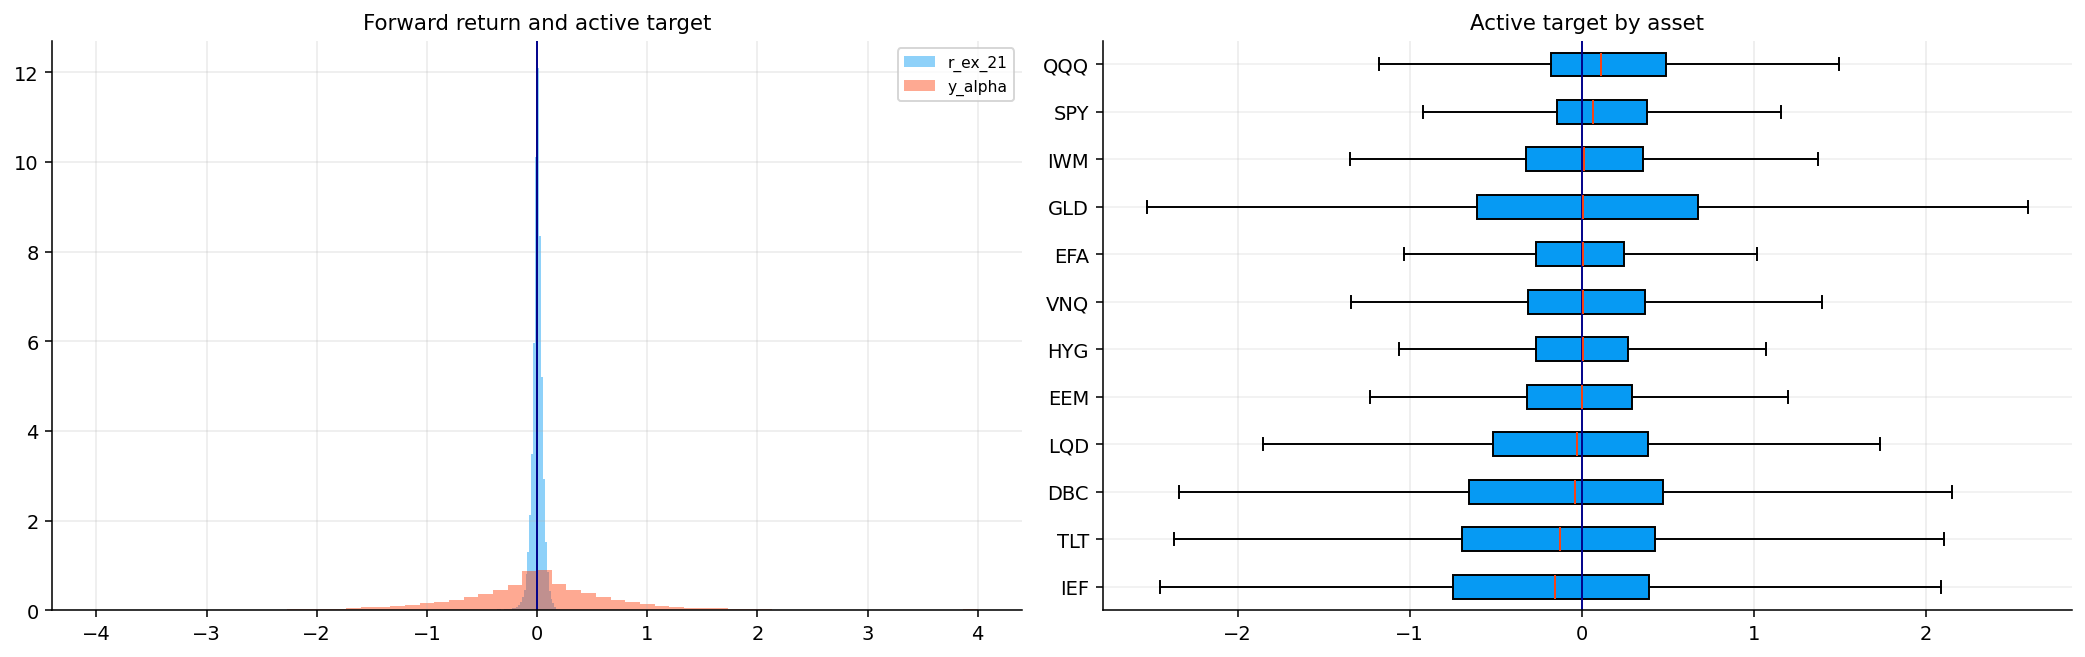

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15.0, 4.8))
target_distribution(axes[0], target_frame, raw_col="r_ex_21", scaled_col="y_alpha", title="Forward return and active target")
target_by_asset(axes[1], target_frame, target_col="y_alpha", asset_col="asset", title="Active target by asset")
fig.tight_layout()
plt.show()

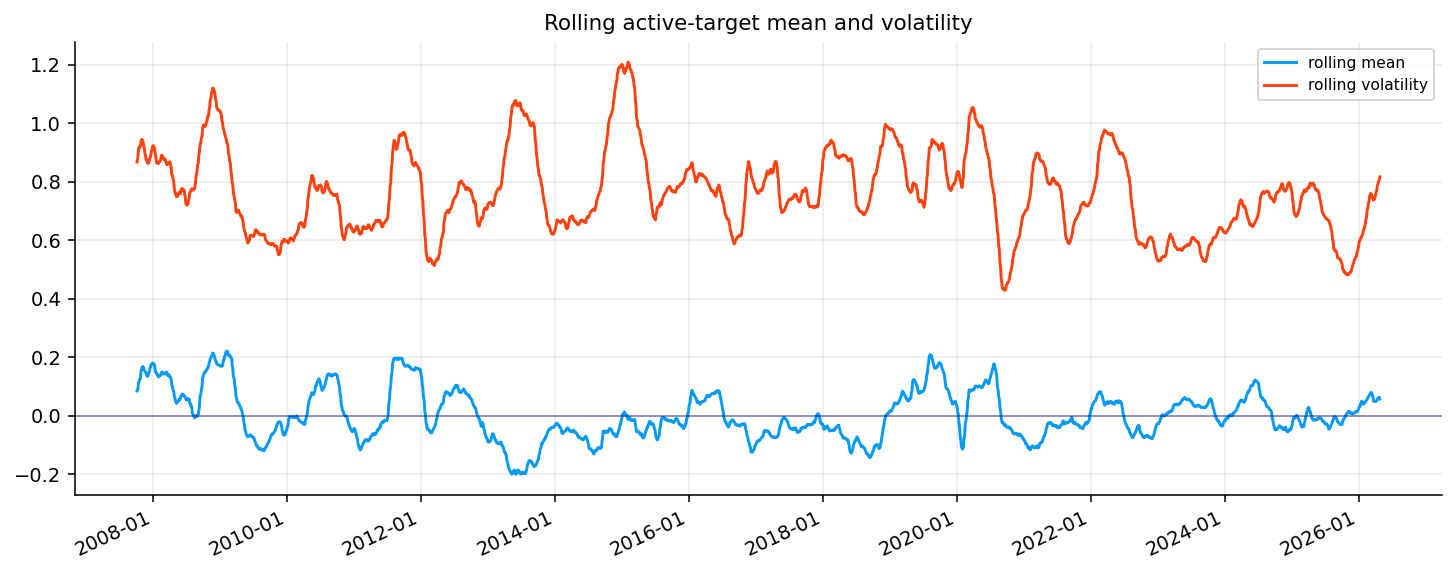

In [6]:
alpha_daily = target_frame[["date", "asset", "y_alpha"]].copy()
alpha_stability = alpha_daily.groupby("date")["y_alpha"].agg(["mean", "std"]).rename(columns={"std": "vol"})
alpha_stability = alpha_stability.rolling(126, min_periods=63).mean()

fig, ax = plt.subplots(figsize=(10.5, 4.2))
target_stability(ax, alpha_stability, title="Rolling active-target mean and volatility")
fig.tight_layout()
plt.show()

In [7]:
rebalance_dates = make_rebalance_dates(close.index, freq="ME", min_history_days=756)
last_label_date = target_frame["date"].max()
rebalance_dates = pd.DatetimeIndex([d for d in rebalance_dates if d <= last_label_date])

base = target_frame[target_frame["date"].isin(rebalance_dates)].copy()
base = base.sort_values(["date", "asset"]).reset_index(drop=True)

display(pd.DataFrame({
    "first_rebalance": [rebalance_dates.min()],
    "last_rebalance": [rebalance_dates.max()],
    "rebalance_count": [len(rebalance_dates)],
    "model_rows": [len(base)],
}))
display(base.head())

,first_rebalance,last_rebalance,rebalance_count,model_rows
0,2010-03-31,2026-03-31,193,2316


,date,asset,r_ex_21,sigma_21,z_21,y_alpha
0,2010-03-31,DBC,0.035102,0.057587,0.609540,-0.140534
1,2010-03-31,EEM,-0.004932,0.067665,-0.072884,-0.822957
2,2010-03-31,EFA,-0.031715,0.058717,-0.540139,-1.290212
3,2010-03-31,GLD,0.053900,0.053996,0.998221,0.248148
4,2010-03-31,HYG,0.015793,0.023606,0.669037,-0.081036


## Benchmarks Before Features

In [8]:
fixed_universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)}
    for dt in rebalance_dates
}

benchmark_grid = run_walkforward_grid(
    returns=r_d[assets],
    close=close[assets],
    volume=volume[assets],
    rebalance_dates=rebalance_dates,
    universe_by_date=fixed_universe_by_date,
    cov_models={"LedoitWolf": covariance.ledoit_wolf_covariance},
    mu_models={"Momentum": expected_returns.momentum_mu},
    optimizers={"EW": optimizers.equal_weight, "MaxSharpe": optimizers.max_sharpe_slsqp},
    strategy_specs=[
        {"name": "Equal Weight", "optimizer": "EW"},
        {
            "name": "MaxSharpe (LedoitWolf, Momentum)",
            "optimizer": "MaxSharpe",
            "cov_model": "LedoitWolf",
            "mu_model": "Momentum",
        },
    ],
    cov_lookback=756,
    mu_lookback=252,
    min_cov_observations=755,
    min_mu_observations=251,
    max_weight=0.35,
    min_weight=0.0,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=10.0,
    rf_daily=rf_daily,
    annualization=annualization,
)

ew_weights = benchmark_grid.weights["Equal Weight"]
maxsharpe_weights = benchmark_grid.weights["MaxSharpe (LedoitWolf, Momentum)"]
display(benchmark_grid.results.round(4))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Equal Weight,EW,-,-,0.0795,0.1029,0.4142,-0.2207,0.3601,0.5233,0.0121,2.3400,0.0012,12.0000,0
"MaxSharpe (LedoitWolf, Momentum)",MaxSharpe,Momentum,LedoitWolf,0.0950,0.1172,0.4986,-0.1728,0.5497,0.6288,0.2633,50.8238,0.0219,3.4942,0


In [9]:
model_rebalance_dates = pd.DatetimeIndex(benchmark_grid.metadata["rebalance_dates"])
w_wasserstein = wasserstein_weight_frame(
    benchmark_grid.cache,
    model_rebalance_dates,
    cov_model="LedoitWolf",
    mu_model="Momentum",
    radius=0.25,
    mv_lambda=3.0,
    w_min=0.0,
    w_max=0.35,
)
wasserstein_result = run_many_weights_backtests(
    {"Wasserstein DRMV": w_wasserstein},
    returns=r_d[assets],
    cost_bps=cost_bps,
    rf_daily=rf_daily,
)["Wasserstein DRMV"]
display(w_wasserstein.tail(2).round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG
2026-01-30,0.2136,0.0,0.0000,0.0000,0.35,0.0,0.0000,0.35,0.0864,0.0,0.0,0.0
2026-02-27,0.0000,0.0,0.0867,0.1183,0.35,0.0,0.0331,0.35,0.0619,0.0,0.0,0.0


In [10]:
p_regime_bench = regime_probability_features(
    close=close,
    returns=r_d,
    assets=assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="LogisticRegression",
    horizon=horizon,
    rebalance_dates=model_rebalance_dates,
    output="features",
    n_jobs=outer_n_jobs,
)
w_regime = regime_probability_features(
    close=close,
    returns=r_d,
    assets=assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="LogisticRegression",
    horizon=horizon,
    rebalance_dates=model_rebalance_dates,
    output="weights",
    max_weight=0.35,
    n_jobs=outer_n_jobs,
)
regime_result = run_many_weights_backtests(
    {"ML Regime-Aware LogisticRegression": w_regime},
    returns=r_d[assets],
    cost_bps=cost_bps,
    rf_daily=rf_daily,
)["ML Regime-Aware LogisticRegression"]
display(p_regime_bench.tail().round(4))

,p_risk_on,p_neutral,p_defensive,regime_confidence
date,,,,
2025-11-28,0.0535,0.3264,0.6201,0.6201
2025-12-31,0.2046,0.5374,0.2580,0.5374
2026-01-30,0.1031,0.5323,0.3646,0.5323
2026-02-27,0.0954,0.3864,0.5182,0.5182
2026-03-31,0.4282,0.4094,0.1624,0.4282


In [11]:
benchmark_results = {
    "Equal Weight": benchmark_grid.backtests["Equal Weight"],
    "MaxSharpe (LedoitWolf, Momentum)": benchmark_grid.backtests["MaxSharpe (LedoitWolf, Momentum)"],
    "Wasserstein DRMV": wasserstein_result,
    "ML Regime-Aware LogisticRegression": regime_result,
}
benchmark_summary = build_strategy_summary(benchmark_results, rf_daily=rf_daily, annualization=annualization)
display(benchmark_summary.round(4))
display(pd.concat({
    "EW": ew_weights.tail(1).T.iloc[:, 0],
    "MaxSharpe": maxsharpe_weights.tail(1).T.iloc[:, 0],
    "W-DRO": w_wasserstein.tail(1).T.iloc[:, 0],
    "Regime": w_regime.tail(1).T.iloc[:, 0],
}, axis=1).round(4))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Equal Weight,EW,-,-,0.0795,0.1029,0.4142,-0.2207,0.3601,0.5233,0.0121,2.3400,0.0012,12.0000,0
"MaxSharpe (LedoitWolf, Momentum)",MaxSharpe,Momentum,LedoitWolf,0.0950,0.1172,0.4986,-0.1728,0.5497,0.6288,0.2633,50.8238,0.0219,3.4942,0
Wasserstein DRMV,Wasserstein DRMV,-,-,0.0928,0.1032,0.5298,-0.1646,0.5636,0.6790,0.3069,58.9247,0.0271,3.5826,0
ML Regime-Aware LogisticRegression,ML Regime-Aware LogisticRegression,-,-,0.0958,0.0874,0.6395,-0.1982,0.4835,0.8083,0.2082,40.1824,0.0205,7.6405,0


,EW,MaxSharpe,W-DRO,Regime
SPY,0.0833,0.0009,0.0000,0.0384
QQQ,0.0833,0.0009,0.0000,0.0341
IWM,0.0833,0.0139,0.0867,0.0341
EFA,0.0833,0.1380,0.1183,0.0341
EEM,0.0833,0.3498,0.3500,0.0341
VNQ,0.0833,0.0000,0.0000,0.0392
DBC,0.0833,0.1471,0.0331,0.3473
GLD,0.0833,0.3495,0.3500,0.1492
IEF,0.0833,0.0000,0.0619,0.0803
TLT,0.0833,0.0000,0.0000,0.0669


## Features

In [12]:
main_asset_groups = {
    "SPY": "us_equity", "QQQ": "us_equity", "IWM": "us_equity",
    "EFA": "intl_equity", "EEM": "intl_equity", "VNQ": "real_asset",
    "DBC": "real_asset", "GLD": "real_asset",
    "IEF": "bond", "TLT": "bond", "LQD": "credit", "HYG": "credit",
}

def _local_cross_sectional_zscore(series):
    s = pd.Series(series, dtype=float)
    std = s.std(ddof=0)
    if not np.isfinite(std) or std <= 1e-12:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std

asset_feature_rows = []
for asset in assets:
    p = close[asset].astype(float)
    r = r_d[asset].astype(float)
    frame = pd.DataFrame(index=close.index)
    frame["r_1"] = r
    for window in [5, 21, 63, 126]:
        frame[f"r_{window}"] = total_return(p, window)
    frame["skip_r_21_252"] = skip_return(p, lookback=252, skip=21)
    for window in [21, 63, 126]:
        frame[f"vol_{window}"] = realized_vol(r, window, annualization=annualization)
    frame["down_vol_63"] = r.where(r < 0).rolling(63, min_periods=21).std(ddof=1) * np.sqrt(annualization)
    frame["drawdown_126"] = drawdown_level(p, 126)
    frame["drawdown_252"] = drawdown_level(p, 252)
    frame["sharpe_63"] = (r - rf_daily).rolling(63, min_periods=21).mean() / r.rolling(63, min_periods=21).std(ddof=1) * np.sqrt(annualization)
    frame["sharpe_126"] = (r - rf_daily).rolling(126, min_periods=42).mean() / r.rolling(126, min_periods=42).std(ddof=1) * np.sqrt(annualization)
    frame["skew_63"] = r.rolling(63, min_periods=42).skew()
    frame["autocorr_63"] = r.rolling(63, min_periods=42).corr(r.shift(1))
    vol_21_daily = r.rolling(21, min_periods=15).std(ddof=1)
    frame["vol_of_vol_63"] = vol_21_daily.rolling(63, min_periods=42).std(ddof=1) * np.sqrt(annualization)
    frame["downside_asymmetry_63"] = frame["down_vol_63"].div(frame["vol_63"].replace(0.0, np.nan))
    frame["trend_consistency"] = pd.concat([frame["r_5"], frame["r_21"], frame["r_63"], frame["r_126"]], axis=1).gt(0.0).mean(axis=1)
    spy_r = r_d[benchmark_ticker].astype(float)
    spy_var = spy_r.rolling(63, min_periods=42).var(ddof=1)
    beta_spy = r.rolling(63, min_periods=42).cov(spy_r).div(spy_var.replace(0.0, np.nan))
    frame["corr_spy_63"] = r.rolling(63, min_periods=42).corr(spy_r)
    frame["beta_spy_63"] = beta_spy
    frame["resid_mom_63_spy"] = frame["r_63"] - beta_spy * total_return(close[benchmark_ticker], 63)
    for ref in ["IEF", "TLT", "GLD"]:
        frame[f"corr_{ref.lower()}_63"] = r.rolling(63, min_periods=42).corr(r_d[ref].astype(float))
    vol_log = np.log1p(volume[asset])
    frame["volume_z_63"] = (vol_log - vol_log.rolling(63, min_periods=21).mean()) / vol_log.rolling(63, min_periods=21).std(ddof=1)
    frame.insert(0, "asset", asset)
    frame.insert(0, "date", frame.index)
    asset_feature_rows.append(frame.reset_index(drop=True))

asset_features = pd.concat(asset_feature_rows, ignore_index=True)
grouped_assets = asset_features.assign(_asset_group=asset_features["asset"].map(main_asset_groups).fillna("other"))
for col in ["r_21", "r_63", "r_126", "skip_r_21_252", "sharpe_126", "drawdown_126", "vol_63", "trend_consistency", "resid_mom_63_spy"]:
    asset_features[f"xs_z_{col}"] = asset_features.groupby("date", sort=False)[col].transform(_local_cross_sectional_zscore)
    group_mean = grouped_assets.groupby(["date", "_asset_group"], sort=False)[col].transform("mean")
    asset_features[f"group_rel_{col}"] = asset_features[col] - group_mean

asset_feature_cols = [c for c in asset_features.columns if c not in {"date", "asset"}]
asset_feature_availability = asset_features.groupby("date")[asset_feature_cols].apply(lambda frame: frame.notna().mean().mean())
first_asset_feature_75 = asset_feature_availability[asset_feature_availability >= 0.75].index.min()
asset_feature_profile = pd.DataFrame({
    "first_valid": asset_features[asset_feature_cols].apply(lambda s: asset_features.loc[s.notna(), "date"].min() if s.notna().any() else pd.NaT),
    "missing_share": asset_features[asset_feature_cols].isna().mean(),
}).sort_values("first_valid")
display(pd.Series({
    "asset_feature_count": len(asset_feature_cols),
    "first_asset_feature_coverage_75": first_asset_feature_75,
    "first_asset_feature_coverage_90": asset_feature_availability[asset_feature_availability >= 0.90].index.min(),
}).to_frame("value"))
display(asset_feature_profile.head(20))
asset_feature_preview = asset_features.loc[asset_features["date"].ge(first_asset_feature_75)].head().copy()
_preview_numeric = asset_feature_preview.select_dtypes(include=[np.number]).columns
asset_feature_preview[_preview_numeric] = asset_feature_preview[_preview_numeric].round(4)
display(asset_feature_preview)

,value
asset_feature_count,44
first_asset_feature_coverage_75,2007-07-09 00:00:00
first_asset_feature_coverage_90,2007-10-05 00:00:00


,first_valid,missing_share
xs_z_skip_r_21_252,2007-04-11,0.000000
xs_z_r_126,2007-04-11,0.000000
xs_z_r_63,2007-04-11,0.000000
group_rel_trend_consistency,2007-04-11,0.000000
xs_z_trend_consistency,2007-04-11,0.000000
xs_z_r_21,2007-04-11,0.000000
xs_z_resid_mom_63_spy,2007-04-11,0.000000
xs_z_vol_63,2007-04-11,0.000000
trend_consistency,2007-04-11,0.000000
xs_z_drawdown_126,2007-04-11,0.000000


,date,asset,r_1,r_5,r_21,r_63,r_126,skip_r_21_252,vol_21,vol_63,...,xs_z_sharpe_126,group_rel_sharpe_126,xs_z_drawdown_126,group_rel_drawdown_126,xs_z_vol_63,group_rel_vol_63,xs_z_trend_consistency,group_rel_trend_consistency,xs_z_resid_mom_63_spy,group_rel_resid_mom_63_spy
63,2007-07-09,SPY,0.0008,0.0086,0.0180,0.0676,NaN,NaN,0.1218,0.1059,...,1.0033,-0.0998,0.8311,-0.0012,-0.1912,-0.0152,0.9124,0.0000,0.3782,-0.0063
64,2007-07-10,SPY,-0.0142,-0.0093,0.0018,0.0478,NaN,NaN,0.1325,0.1100,...,0.8549,-0.2258,0.4525,-0.0024,-0.1600,-0.0141,0.0874,-0.0833,0.2833,-0.0070
65,2007-07-11,SPY,0.0071,-0.0023,0.0200,0.0504,NaN,NaN,0.1283,0.1105,...,0.9023,-0.1885,0.6152,-0.0019,-0.1585,-0.0139,0.2294,-0.0833,0.3328,-0.0067
66,2007-07-12,SPY,0.0158,0.0145,0.0208,0.0570,NaN,NaN,0.1294,0.1132,...,0.9732,-0.1081,0.8024,0.0000,-0.1221,-0.0126,0.8222,0.0000,0.3475,-0.0044
67,2007-07-13,SPY,0.0030,0.0122,0.0174,0.0573,NaN,NaN,0.1282,0.1132,...,0.9706,-0.1193,0.7999,0.0000,-0.1170,-0.0127,0.7809,0.0000,0.2661,-0.0072


In [13]:
cross_features = pd.DataFrame(index=close.index)
cross_features["breadth_21"] = breadth(close, 21, assets)
cross_features["breadth_63"] = breadth(close, 63, assets)
cross_features["dispersion_21"] = dispersion(close, 21, assets)
cross_features["dispersion_63"] = dispersion(close, 63, assets)
cross_features["rolling_avg_corr_63"] = rolling_avg_corr(r_d[assets], 63)
cross_features["rolling_avg_corr_126"] = rolling_avg_corr(r_d[assets], 126)
cross_features["spy_r_63"] = total_return(close["SPY"], 63)
cross_features["qqq_spy_63"] = relative_return(close["QQQ"], close["SPY"], 63)
cross_features["hyg_lqd_63"] = relative_return(close["HYG"], close["LQD"], 63)
cross_features["hyg_lqd_change_63"] = cross_features["hyg_lqd_63"].diff(63)
cross_features["tlt_ief_63"] = relative_return(close["TLT"], close["IEF"], 63)
cross_features["tlt_shy_63"] = relative_return(close["TLT"], close[cash_ticker], 63)
cross_features["gld_spy_126"] = relative_return(close["GLD"], close["SPY"], 126)
cross_features["dbc_ief_126"] = relative_return(close["DBC"], close["IEF"], 126)
risk_ret_63 = total_return(close[["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG"]], 63).mean(axis=1)
defensive_ret_63 = total_return(close[["IEF", "TLT", "LQD", "GLD", cash_ticker]], 63).mean(axis=1)
cross_features["risk_defensive_spread_63"] = risk_ret_63 - defensive_ret_63
cross_features["avg_vol_change_63"] = realized_vol(r_d[assets], 21).mean(axis=1) - realized_vol(r_d[assets], 63).mean(axis=1)
cross_features.index.name = "date"
display(cross_features.tail().round(4))

,breadth_21,breadth_63,dispersion_21,dispersion_63,rolling_avg_corr_63,rolling_avg_corr_126,spy_r_63,qqq_spy_63,hyg_lqd_63,hyg_lqd_change_63,tlt_ief_63,tlt_shy_63,gld_spy_126,dbc_ief_126,risk_defensive_spread_63,avg_vol_change_63
date,,,,,,,,,,,,,,,,
2026-05-18,0.4167,0.5000,0.0503,0.1134,0.4620,0.4128,0.0847,0.0907,0.0242,0.0247,-0.0307,-0.0573,0.0099,0.4273,0.0971,-0.0229
2026-05-19,0.3333,0.5000,0.0505,0.1096,0.4649,0.4159,0.0720,0.0875,0.0245,0.0226,-0.0315,-0.0597,-0.0187,0.4314,0.0938,-0.0212
2026-05-20,0.5833,0.5833,0.0407,0.1008,0.4699,0.4194,0.0859,0.0973,0.0238,0.0227,-0.0281,-0.0519,-0.0118,0.4053,0.1052,-0.0205
2026-05-21,0.5833,0.5833,0.0364,0.0994,0.4705,0.4220,0.0781,0.0947,0.0223,0.0176,-0.0259,-0.0496,-0.0289,0.4212,0.0999,-0.0223
2026-05-22,0.5833,0.5833,0.0365,0.1046,0.4786,0.4221,0.0892,0.0981,0.0249,0.0228,-0.0258,-0.0522,-0.0159,0.4338,0.1164,-0.0231


In [14]:
macro_factors = load_macro_factors(data_path / "us_macro_factors.csv", start="1990-01-01")
nfci = load_nfci(data_path / "nfci.csv")
fci_features = build_fci_feature_block(macro_factors, nfci, index=close.index)
fci_features.index.name = "date"
fci_availability = pd.DataFrame({
    "first_valid": fci_features.apply(pd.Series.first_valid_index),
    "last_valid": fci_features.apply(pd.Series.last_valid_index),
    "missing_share": fci_features.isna().mean(),
    "unique_values": fci_features.nunique(dropna=True),
}).sort_values("first_valid")
display(pd.Series({
    "macro_monthly_first": macro_factors.index.min(),
    "macro_monthly_last": macro_factors.index.max(),
    "nfci_monthly_first": nfci.index.min(),
    "nfci_monthly_last": nfci.index.max(),
    "daily_alignment_first": fci_features.index.min(),
    "daily_alignment_last": fci_features.index.max(),
}).to_frame("value"))
display(fci_availability)
display(fci_features.dropna(how="all").tail().round(4))


,value
macro_monthly_first,1990-01-31
macro_monthly_last,2026-01-31
nfci_monthly_first,1971-01-31
nfci_monthly_last,2026-05-31
daily_alignment_first,2007-04-11
daily_alignment_last,2026-05-22


,first_valid,last_valid,missing_share,unique_values
fci_level,2007-04-11,2026-05-22,0.0,227
fci_percentile,2007-04-11,2026-05-22,0.0,225
fci_change_21,2007-04-11,2026-05-22,0.0,227
fci_change_63,2007-04-11,2026-05-22,0.0,227
stress_breadth,2007-04-11,2026-05-22,0.0,227
policy_pressure,2007-04-11,2026-05-22,0.0,227
inflation_pressure,2007-04-11,2026-05-22,0.0,227
growth_pressure,2007-04-11,2026-05-22,0.0,227
nfci_level,2007-04-11,2026-05-22,0.0,201
nfci_change_21,2007-04-11,2026-05-22,0.0,186


,fci_level,fci_percentile,fci_change_21,fci_change_63,stress_breadth,policy_pressure,inflation_pressure,growth_pressure,nfci_level,nfci_change_21,nfci_change_63,nfci_risk,nfci_credit,nfci_leverage,nfci_nonfinancial_leverage
date,,,,,,,,,,,,,,,
2026-05-18,-0.4037,0.3064,0.145,-0.2047,-1.046,-0.0571,0.3999,-0.0583,-0.494,-0.043,0.065,-0.574,-0.019,0.234,-0.413
2026-05-19,-0.4037,0.3064,0.145,-0.2047,-1.046,-0.0571,0.3999,-0.0583,-0.494,-0.043,0.065,-0.574,-0.019,0.234,-0.413
2026-05-20,-0.4037,0.3064,0.145,-0.2047,-1.046,-0.0571,0.3999,-0.0583,-0.494,-0.043,0.065,-0.574,-0.019,0.234,-0.413
2026-05-21,-0.4037,0.3064,0.145,-0.2047,-1.046,-0.0571,0.3999,-0.0583,-0.494,-0.043,0.065,-0.574,-0.019,0.234,-0.413
2026-05-22,-0.4037,0.3064,0.145,-0.2047,-1.046,-0.0571,0.3999,-0.0583,-0.494,-0.043,0.065,-0.574,-0.019,0.234,-0.413


In [15]:
p_regime = p_regime_bench.reindex(close.index.union(p_regime_bench.index)).sort_index().ffill().reindex(close.index)
p_regime.index.name = "date"
display(p_regime.dropna().tail().round(4))

,p_risk_on,p_neutral,p_defensive,regime_confidence
date,,,,
2026-05-18,0.4282,0.4094,0.1624,0.4282
2026-05-19,0.4282,0.4094,0.1624,0.4282
2026-05-20,0.4282,0.4094,0.1624,0.4282
2026-05-21,0.4282,0.4094,0.1624,0.4282
2026-05-22,0.4282,0.4094,0.1624,0.4282


In [ ]:
required_table_features = {"skew_63", "autocorr_63", "resid_mom_63_spy", "rank_r_63", "y_alpha"}

data = assemble_forecasting_table(target_frame, asset_features, cross_features, fci_features, p_regime)
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["y_alpha", "z_21", "sigma_21"])
data = data[data["asset"].isin(assets)].copy()
full_data_dates = data.groupby("date")["asset"].nunique()
data = data[data["date"].isin(full_data_dates[full_data_dates.eq(len(assets))].index)].copy()
data = data.sort_values(["date", "asset"]).reset_index(drop=True)
display(pd.DataFrame({"rows": [len(data)], "features_before_filter": [data.shape[1] - 6]}))

,rows,features_before_filter
0,57756,120


In [17]:
train_end = pd.Timestamp("2018-12-31")
validation_start = pd.Timestamp("2017-01-01")
test_start = pd.Timestamp("2019-01-01")
train_label_cutoff = train_end - pd.tseries.offsets.BDay(horizon)
validation_end = train_label_cutoff

blocked_cols = {"date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21"}
candidate_feature_cols = [c for c in data.columns if c not in blocked_cols]
initial_stage1_features = clean_feature_columns(
    data,
    candidate_feature_cols,
    max_missing=0.30,
    min_std=1e-8,
    max_abs_corr=0.985,
)
feature_coverage_by_date = data.groupby("date")[initial_stage1_features].apply(lambda frame: frame.notna().mean().mean())
asset_count_by_date = data.groupby("date")["asset"].nunique()
target_complete_by_date = data.groupby("date")[["y_alpha", "sigma_21"]].apply(lambda frame: frame.notna().all(axis=1).mean())
date_quality = pd.DataFrame({
    "feature_coverage": feature_coverage_by_date,
    "asset_count": asset_count_by_date,
    "target_complete": target_complete_by_date,
})
model_ready_dates = date_quality.index[
    (date_quality["feature_coverage"] >= 0.75)
    & (date_quality["asset_count"] >= len(assets))
    & (date_quality["target_complete"] >= 1.0)
]
first_model_date = pd.Timestamp(model_ready_dates.min()) if len(model_ready_dates) else pd.Timestamp(data["date"].min())
rows_before_trim = len(data)
data = data.loc[pd.to_datetime(data["date"]) >= first_model_date].copy().reset_index(drop=True)

stage1_features = clean_feature_columns(
    data,
    candidate_feature_cols,
    max_missing=0.30,
    min_std=1e-8,
    max_abs_corr=0.985,
)

for col in stage1_features:
    data[col] = data.groupby("asset")[col].transform(lambda s: s.fillna(s.expanding().median().shift(1)))
train_medians = data.loc[data["date"] <= train_label_cutoff, stage1_features].median()
data[stage1_features] = data[stage1_features].fillna(train_medians).fillna(0.0)

date_quality_window = date_quality.loc[:first_model_date].tail(10)
display(pd.Series({
    "train_end": train_end,
    "train_label_cutoff": train_label_cutoff,
    "validation_start": validation_start,
    "validation_end": validation_end,
    "first_model_date": first_model_date,
    "rows_before_availability_trim": rows_before_trim,
    "rows_after_availability_trim": len(data),
    "trimmed_rows": rows_before_trim - len(data),
    "initial_stage1_feature_count": len(initial_stage1_features),
    "stage1_feature_count": len(stage1_features),
}).to_frame("setting"))
display(date_quality_window.round(4))
display(pd.DataFrame({"stage1_features": stage1_features}))

,setting
train_end,2018-12-31 00:00:00
train_label_cutoff,2018-11-30 00:00:00
validation_start,2017-01-01 00:00:00
validation_end,2018-11-30 00:00:00
first_model_date,2007-07-09 00:00:00
rows_before_availability_trim,57756
rows_after_availability_trim,57756
trimmed_rows,0
initial_stage1_feature_count,115
stage1_feature_count,115


,feature_coverage,asset_count,target_complete
date,,,
2007-07-09,0.763,12,1.0


,stage1_features
0,r_1
1,r_5
2,r_21
3,r_63
4,r_126
...,...
110,skip_21_252_vol126_x_fci
111,rank_r_63_x_p_risk_on
112,rank_vol_63_x_p_defensive
113,rel_r_63_avg_x_fci


In [18]:
train_data = data[data["date"] <= train_label_cutoff].copy()

rf_screen = RandomForestRegressor(
    n_estimators=800,
    max_depth=6,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf_screen.fit(train_data[stage1_features], train_data["y_alpha"])
rf_importance = pd.Series(rf_screen.feature_importances_, index=stage1_features).sort_values(ascending=False)
display(rf_importance.head(25).to_frame("rf_importance").round(4))

,rf_importance
beta_spy_63,0.0262
corr_spy_63,0.0259
nfci_leverage,0.0248
p_defensive,0.0247
nfci_level,0.0243
mom_126_vol126,0.0242
vol_126,0.0226
xs_z_skip_r_21_252,0.0226
sharpe_126,0.0196
growth_pressure,0.0192


In [19]:
enet_scaler = StandardScaler()
x_train_screen = enet_scaler.fit_transform(train_data[stage1_features])
enet_screen = ElasticNet(alpha=0.003, l1_ratio=0.25, max_iter=12000, random_state=42)
enet_screen.fit(x_train_screen, train_data["y_alpha"])
enet_coef = pd.Series(np.abs(enet_screen.coef_), index=stage1_features).sort_values(ascending=False)
display(enet_coef.head(25).to_frame("elastic_net_abs_coef").round(4))

,elastic_net_abs_coef
mom_21_sigma21,0.1536
trend_21_63,0.1496
vol_63_x_stress_breadth,0.1440
sharpe_63,0.1378
rank_r_126,0.1304
vol_126,0.1241
downside_asymmetry_63,0.1184
rel_r_63_avg,0.1133
nfci_change_63,0.1115
corr_ief_63,0.1108


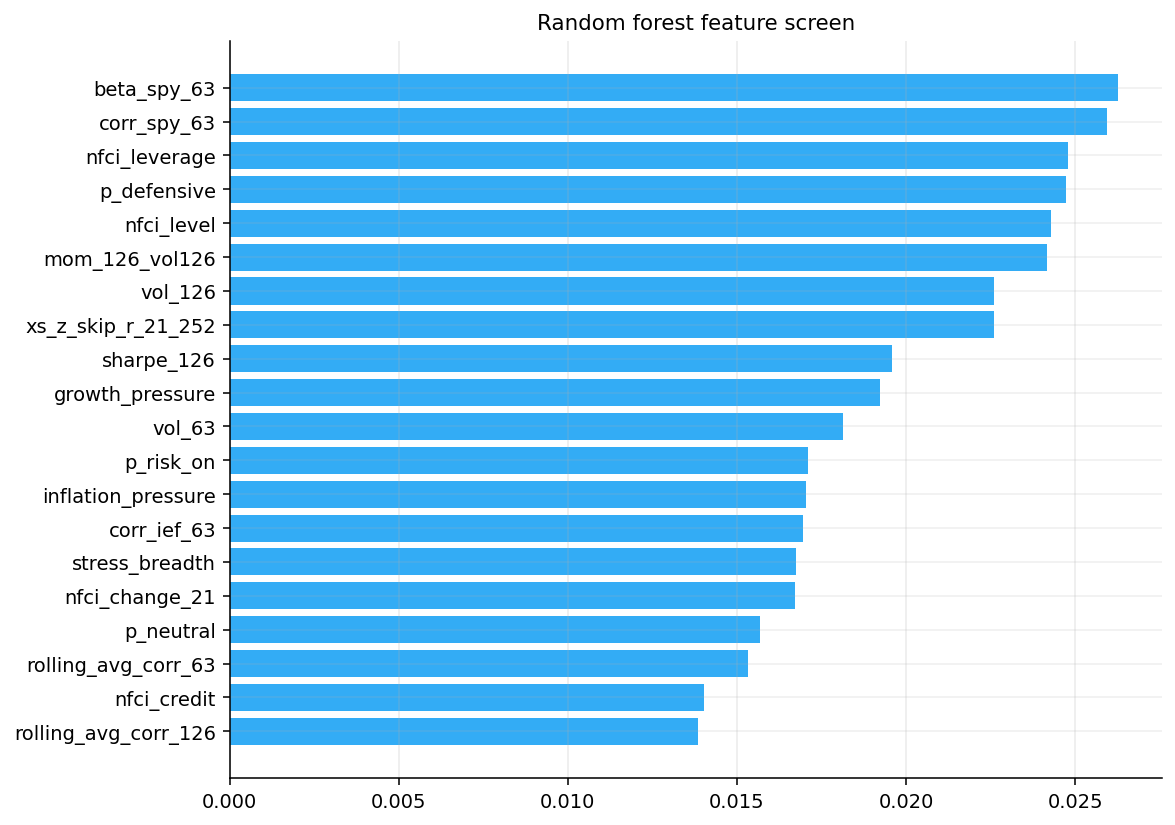

,feature,rf_importance,elastic_net_abs_coef,valid_rank_ic,valid_bucket_spread
0,beta_spy_63,0.0262,0.1070,0.1469,0.2803
1,vol_126,0.0226,0.1241,0.1143,0.3419
2,sharpe_63,0.0127,0.1378,0.1349,0.2367
3,sharpe_126,0.0196,0.0947,0.0814,0.1627
4,rank_r_126,0.0120,0.1304,0.0782,0.1720
5,down_vol_63,0.0131,0.0595,0.0986,0.1623
6,xs_z_vol_63,0.0081,0.0896,0.0963,0.2817
7,trend_21_63_x_stress,0.0063,0.0941,0.1398,0.2659
8,rel_r_63_avg_x_fci,0.0082,0.0778,0.1118,0.2303
9,vol_63,0.0181,0.0151,0.0963,0.2817


,selected_features_nn
0,corr_spy_63
1,rank_corr_spy_63
2,vol_126
3,trend_21_63_x_stress
4,vol_of_vol_63
5,rank_vol_of_vol_63
6,sharpe_63
7,rank_vol_63
8,vol_63
9,xs_z_vol_63


In [20]:
valid_feature_screen = data[data["date"].between(validation_start, validation_end)].copy()
feature_rank_rows = []
for col in stage1_features:
    daily_ic = []
    daily_spread = []
    for _, group in valid_feature_screen[["date", "asset", "y_alpha", col]].dropna().groupby("date"):
        if len(group) < 4 or group[col].nunique() < 2:
            continue
        daily_ic.append(group[col].corr(group["y_alpha"], method="spearman"))
        n = max(1, int(np.ceil(len(group) * 0.25)))
        ordered = group.sort_values(col)
        daily_spread.append(ordered.tail(n)["y_alpha"].mean() - ordered.head(n)["y_alpha"].mean())
    feature_rank_rows.append({
        "feature": col,
        "valid_rank_ic": float(pd.Series(daily_ic).mean()) if daily_ic else np.nan,
        "valid_bucket_spread": float(pd.Series(daily_spread).mean()) if daily_spread else np.nan,
    })
feature_rank_screen = pd.DataFrame(feature_rank_rows).set_index("feature")
feature_rank_screen["valid_score"] = 0.55 * feature_rank_screen["valid_rank_ic"].fillna(0.0) + 0.45 * feature_rank_screen["valid_bucket_spread"].fillna(0.0)

screen_rank = pd.concat(
    [
        rf_importance.rank(ascending=False).rename("rf_rank"),
        enet_coef.rank(ascending=False).rename("enet_rank"),
        feature_rank_screen["valid_score"].rank(ascending=False).rename("valid_rank"),
    ],
    axis=1,
)
screen_rank["mean_rank"] = screen_rank.mean(axis=1)
core_features = screen_rank.sort_values("mean_rank").head(40).index.tolist()
forecast_feature_keywords = ["rank_", "xs_z_", "group_rel_", "corr_", "resid_", "trend_consistency", "autocorr", "skew", "vol_of_vol", "downside_asym"]
cs_features = [
    f for f in feature_rank_screen["valid_score"].sort_values(ascending=False).index
    if any(k in f for k in forecast_feature_keywords)
]
selected_features = list(dict.fromkeys(core_features + cs_features[:25]))[:60]
selected_features_tree = selected_features[:46]

nn_feature_keywords = [
    "rank_", "xs_z_", "group_rel_", "r_", "skip_r", "vol_", "sharpe_", "drawdown_",
    "trend_consistency", "autocorr", "skew", "vol_of_vol", "downside_asym", "corr_", "resid_",
    "p_risk", "p_neutral", "p_defensive", "regime_confidence", "fci", "stress",
]
macro_penalty_keywords = ["inflation", "growth", "policy", "NFCI", "ANFCI", "leverage"]
ranked_for_nn = feature_rank_screen["valid_score"].sort_values(ascending=False).index.tolist()
selected_features_nn = [
    f for f in ranked_for_nn
    if f in selected_features and any(k in f for k in nn_feature_keywords)
]
selected_features_nn += [f for f in selected_features if f not in selected_features_nn and not any(k in f for k in macro_penalty_keywords)]
selected_features_nn = list(dict.fromkeys(selected_features_nn))[:28]
selected_features = selected_features_tree

selected_feature_table = pd.DataFrame({
    "feature": selected_features,
    "rf_importance": rf_importance.reindex(selected_features).values,
    "elastic_net_abs_coef": enet_coef.reindex(selected_features).values,
    "valid_rank_ic": feature_rank_screen.reindex(selected_features)["valid_rank_ic"].values,
    "valid_bucket_spread": feature_rank_screen.reindex(selected_features)["valid_bucket_spread"].values,
})

fig, ax = plt.subplots(figsize=(8.5, 6.0))
feature_importance_bars(ax, rf_importance.head(20), title="Random forest feature screen")
fig.tight_layout()
plt.show()
display(selected_feature_table.round(4))
display(pd.DataFrame({"selected_features_nn": selected_features_nn}))

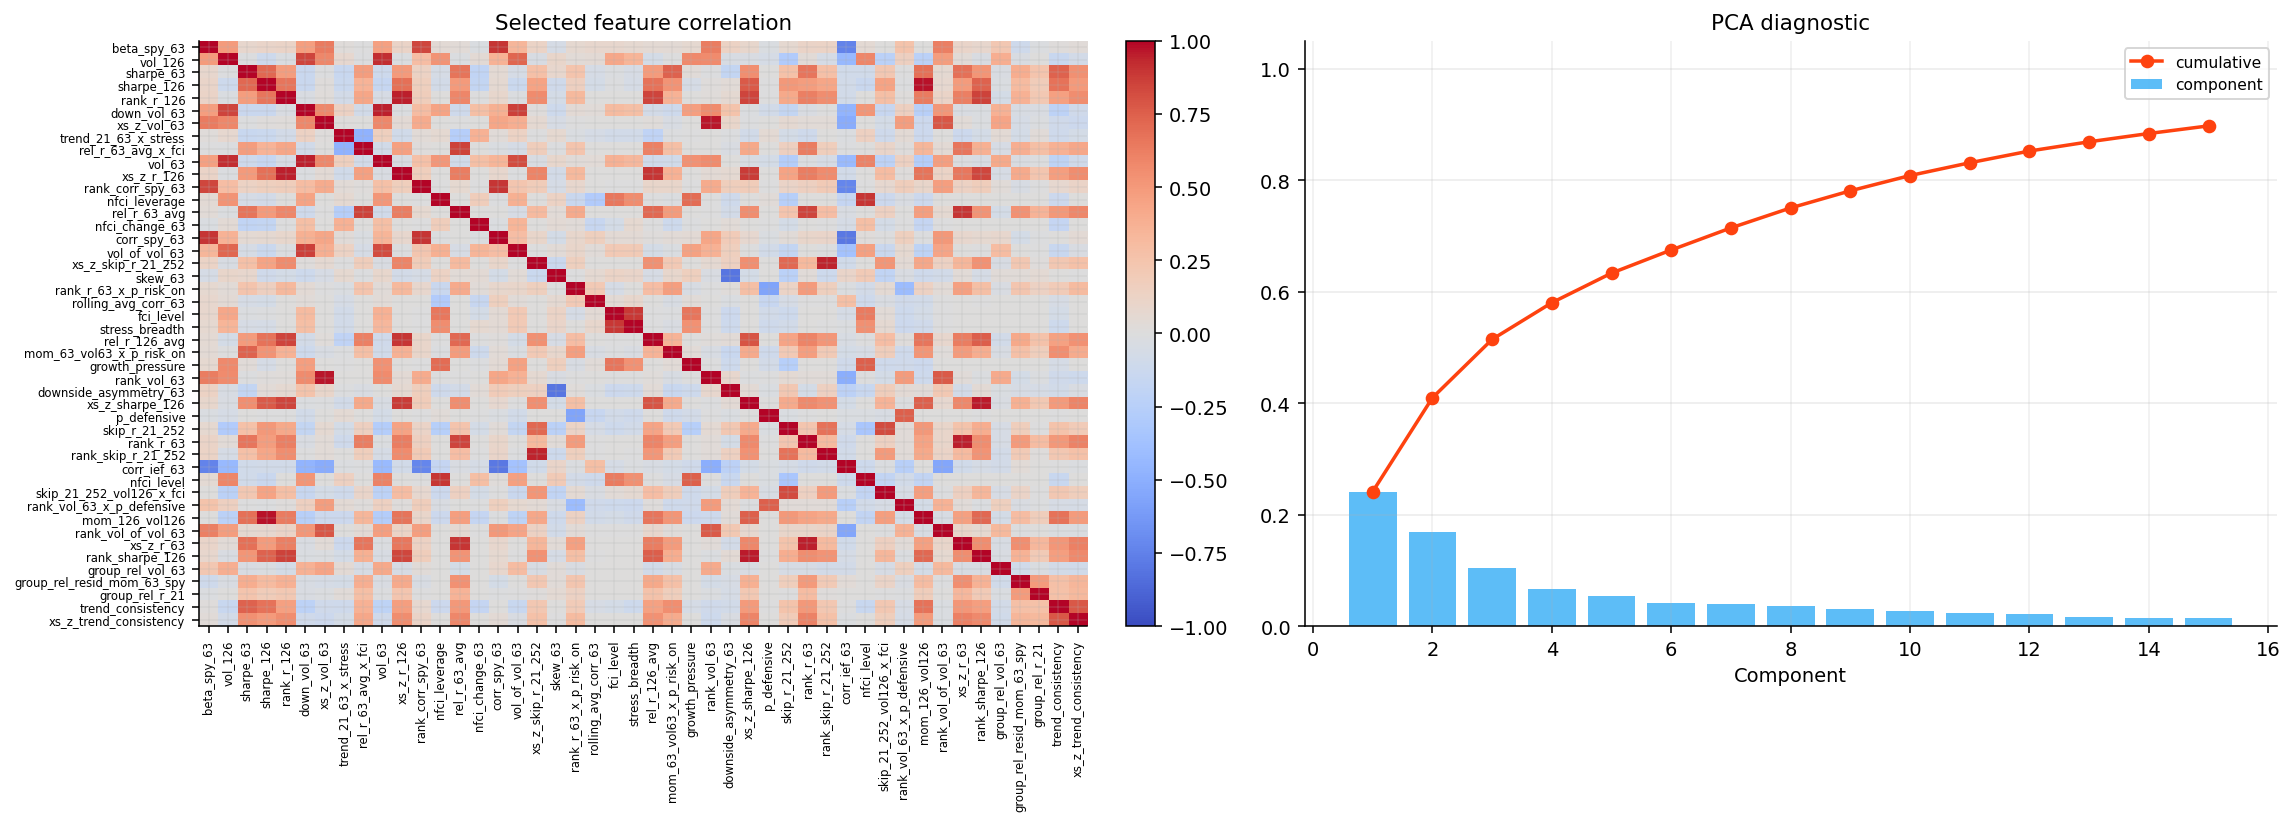

In [21]:
pca_explained = pd.DataFrame()
pca_x = data.loc[data["date"] <= train_label_cutoff, selected_features].copy()
pca_x = pca_x.replace([np.inf, -np.inf], np.nan).fillna(pca_x.median()).fillna(0.0)
pca_z = StandardScaler().fit_transform(pca_x)
pca = PCA(n_components=min(15, len(selected_features)), random_state=42).fit(pca_z)
pca_explained = pd.DataFrame({
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
})

fig, axes = plt.subplots(1, 2, figsize=(16.5, 6.0))
feature_correlation_map(axes[0], data[selected_features].corr(), title="Selected feature correlation")
pca_explained_variance(axes[1], pca_explained, title="PCA diagnostic")
fig.tight_layout()
plt.show()

In [22]:
x = data[selected_features_tree].copy()
x_nn = data[selected_features_nn].copy()
y = data["y_alpha"].copy()
dates = pd.to_datetime(data["date"])
asset_name = data["asset"].copy()
asset_map = {asset: i for i, asset in enumerate(assets)}
asset_id = asset_name.map(asset_map).astype(int)
x_np = x.to_numpy(dtype=np.float32)
y_np = y.to_numpy(dtype=np.float32)
dates_np = dates.to_numpy()
asset_np = asset_name.to_numpy()

def _concat_nonempty(frames):
    frames = [f for f in frames if f is not None and len(f)]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

display(pd.DataFrame({
    "rows": [len(x)],
    "tree_features": [x.shape[1]],
    "nn_features": [x_nn.shape[1]],
    "target": ["y_alpha"],
    "first_date": [dates.min()],
    "last_date": [dates.max()],
}))

,rows,tree_features,nn_features,target,first_date,last_date
0,57756,46,28,y_alpha,2007-07-09,2026-04-23


## Tabular Forecasting Baselines

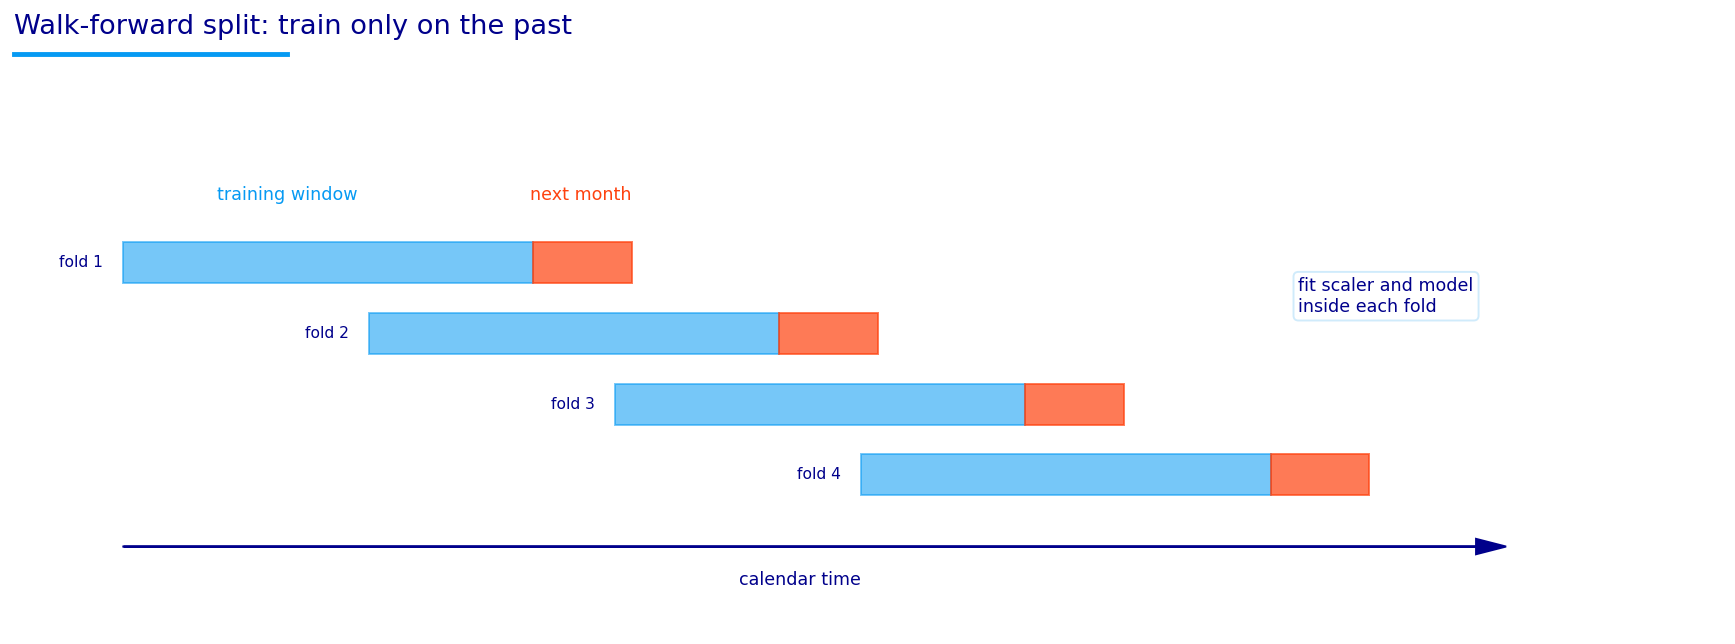

(2383,
 111,
 38,
 Timestamp('2017-01-03 00:00:00'),
 Timestamp('2026-04-23 00:00:00'))

In [ ]:
wf_dates = pd.DatetimeIndex([d for d in rebalance_dates if d >= validation_start and d in set(dates)])
forecast_dates = pd.DatetimeIndex(pd.to_datetime(data.loc[data["date"] >= validation_start, "date"].drop_duplicates())).sort_values()
TABULAR_TRAIN_WINDOW = 252 * 8

refit_dates = pd.DatetimeIndex(
    pd.Series(forecast_dates, index=forecast_dates)
    .groupby(forecast_dates.to_period("Q"))
    .first()
    .to_list()
)
def masks_for_date(dt):
    label_end = pd.Timestamp(dt) - pd.tseries.offsets.BDay(horizon)
    train_mask = dates <= label_end
    test_mask = dates.eq(pd.Timestamp(dt))
    return train_mask, test_mask

def train_mask_for_refit(dt):
    label_end = pd.Timestamp(dt) - pd.tseries.offsets.BDay(horizon)
    train_start = label_end - pd.tseries.offsets.BDay(TABULAR_TRAIN_WINDOW)
    return dates.between(train_start, label_end), label_end

def prediction_dates_for_refit(i):
    start = refit_dates[i]
    end = refit_dates[i + 1] if i + 1 < len(refit_dates) else forecast_dates.max() + pd.tseries.offsets.BDay(1)
    return pd.DatetimeIndex([d for d in forecast_dates if pd.Timestamp(start) <= d < pd.Timestamp(end)])

def prediction_frame_from_model(model, pred_dates):
    frames = []
    for pred_dt in pd.DatetimeIndex(pred_dates):
        test_mask = dates.eq(pd.Timestamp(pred_dt))
        if test_mask.sum() == 0:
            continue
        frames.append(pd.DataFrame({
            "date": dates.loc[test_mask].values,
            "asset": asset_name.loc[test_mask].values,
            "prediction": model.predict(x.loc[test_mask]),
        }))
    return _concat_nonempty(frames)

len(forecast_dates), len(wf_dates), len(refit_dates), forecast_dates.min(), forecast_dates.max()

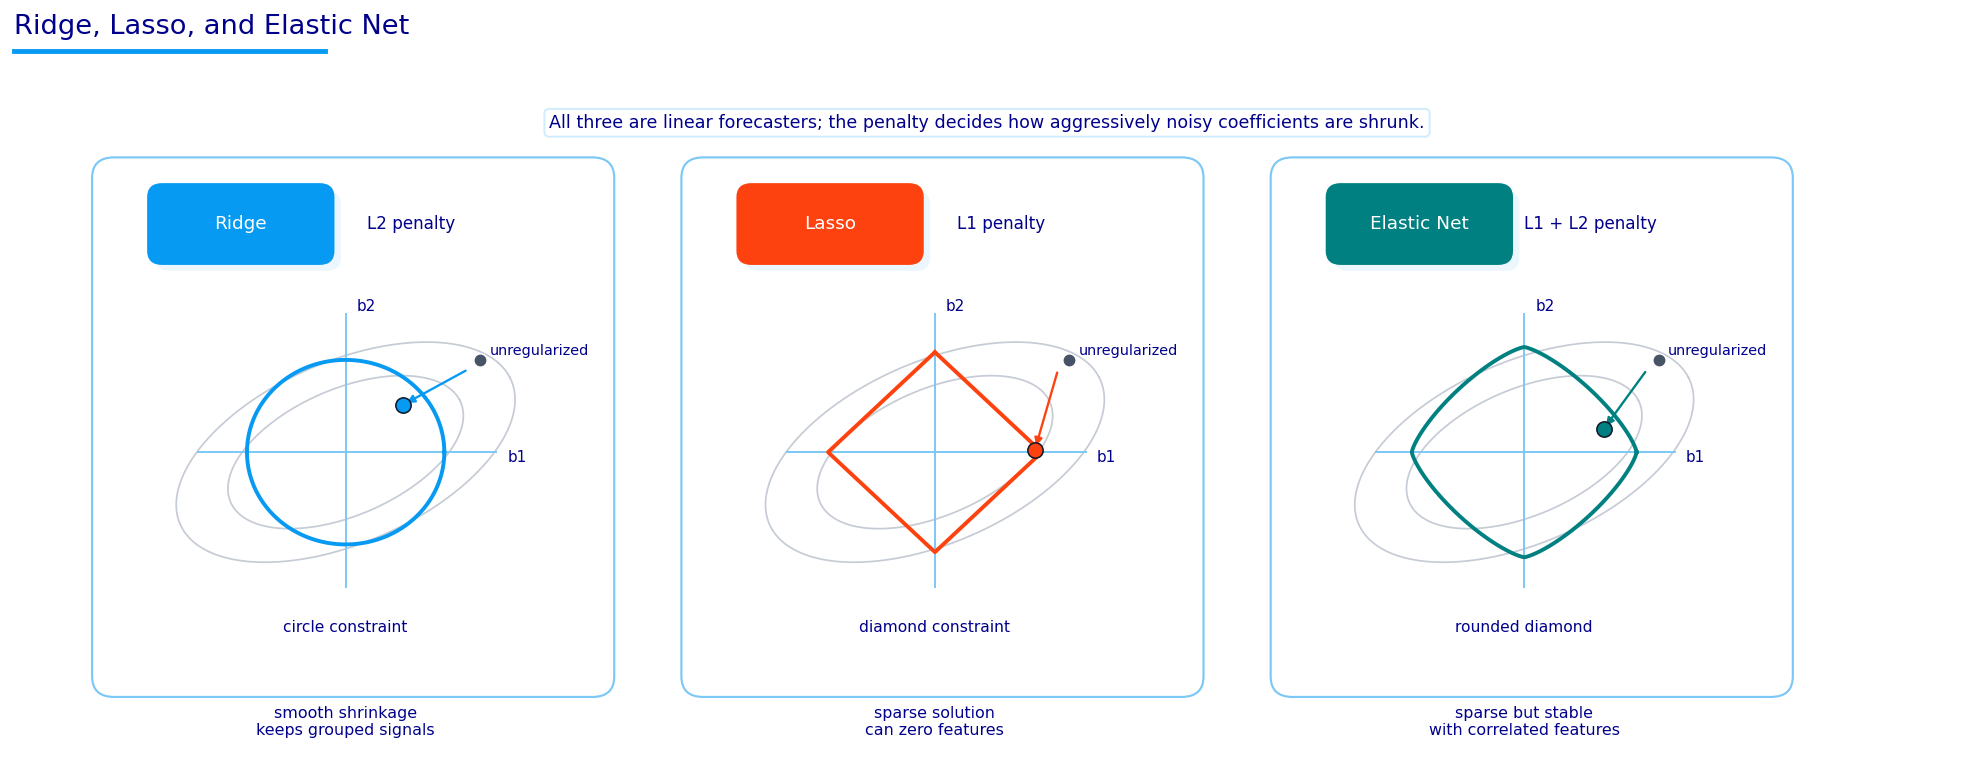

In [3]:
fig, ax = linear_regularization_comparison()
plt.show()

In [25]:
enet_grid = [(a, l1) for a in [0.0005, 0.001, 0.002, 0.003, 0.005] for l1 in [0.05, 0.15, 0.25, 0.50]]

def select_enet_params_once():
    core_end = validation_start - pd.tseries.offsets.BDay(horizon)
    core_start = core_end - pd.tseries.offsets.BDay(TABULAR_TRAIN_WINDOW)
    core_mask = dates.between(core_start, core_end)
    valid_mask = dates.between(validation_start, train_end)
    if core_mask.sum() < 500 or valid_mask.sum() < 100:
        return (0.003, 0.25, np.nan)
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x.loc[core_mask])
    x_valid = scaler.transform(x.loc[valid_mask])
    valid_frame = data.loc[valid_mask, ["date", "asset", "y_alpha"]].copy()
    best_score = -np.inf
    best_params = (0.003, 0.25)
    for alpha, l1_ratio in enet_grid:
        trial = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=12000, random_state=42)
        with threadpool_limits(limits=forest_inner_jobs):
            trial.fit(x_train, y.loc[core_mask])
        trial_eval = valid_frame.copy()
        trial_eval["pred"] = trial.predict(x_valid)
        score = rank_metrics(
            trial_eval,
            date_col="date",
            asset_col="asset",
            y_col="y_alpha",
            prediction_cols=["pred"],
        ).loc["pred", "mean_rank_ic"]
        if np.isfinite(score) and score > best_score:
            best_score = float(score)
            best_params = (alpha, l1_ratio)
    return best_params[0], best_params[1], best_score

enet_alpha, enet_l1_ratio, enet_valid_rank_ic = select_enet_params_once()

def fit_enet_for_refit(i, dt):
    train_mask, _ = train_mask_for_refit(dt)
    pred_dates = prediction_dates_for_refit(i)
    if train_mask.sum() < 500 or len(pred_dates) == 0:
        return None
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x.loc[train_mask])
    model = ElasticNet(alpha=enet_alpha, l1_ratio=enet_l1_ratio, max_iter=12000, random_state=42)
    with threadpool_limits(limits=forest_inner_jobs):
        model.fit(x_train, y.loc[train_mask])
    frames = []
    for pred_dt in pred_dates:
        test_mask = dates.eq(pd.Timestamp(pred_dt))
        if test_mask.sum() == 0:
            continue
        x_test = scaler.transform(x.loc[test_mask])
        frames.append(pd.DataFrame({
            "date": dates.loc[test_mask].values,
            "asset": asset_name.loc[test_mask].values,
            "z_enet": model.predict(x_test),
            "enet_alpha": enet_alpha,
            "enet_l1_ratio": enet_l1_ratio,
            "enet_valid_rank_ic": enet_valid_rank_ic,
        }))
    return _concat_nonempty(frames)

enet_rows = Parallel(n_jobs=outer_n_jobs, prefer="threads", batch_size=1)(
    delayed(fit_enet_for_refit)(i, dt) for i, dt in enumerate(refit_dates)
)
pred_enet = _concat_nonempty(enet_rows)
display(pd.Series({"enet_alpha": enet_alpha, "enet_l1_ratio": enet_l1_ratio, "enet_valid_rank_ic": enet_valid_rank_ic}).to_frame("selected"))
display(pred_enet.tail())

,selected
enet_alpha,0.001000
enet_l1_ratio,0.500000
enet_valid_rank_ic,0.134975


,date,asset,z_enet,enet_alpha,enet_l1_ratio,enet_valid_rank_ic
28591,2026-04-23,LQD,-0.151458,0.001,0.5,0.134975
28592,2026-04-23,QQQ,0.010342,0.001,0.5,0.134975
28593,2026-04-23,SPY,0.030339,0.001,0.5,0.134975
28594,2026-04-23,TLT,-0.202368,0.001,0.5,0.134975
28595,2026-04-23,VNQ,0.158984,0.001,0.5,0.134975


In [26]:
def fit_rf_for_refit(i, dt):
    train_mask, _ = train_mask_for_refit(dt)
    pred_dates = prediction_dates_for_refit(i)
    if train_mask.sum() < 500 or len(pred_dates) == 0:
        return None
    model = RandomForestRegressor(
        n_estimators=800,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=forest_inner_jobs,
    )
    model.fit(x.loc[train_mask], y.loc[train_mask])
    out = prediction_frame_from_model(model, pred_dates)
    return out.rename(columns={"prediction": "z_rf"})

rf_rows = Parallel(n_jobs=outer_n_jobs, prefer="threads", batch_size=1)(
    delayed(fit_rf_for_refit)(i, dt) for i, dt in enumerate(refit_dates)
)
pred_rf = _concat_nonempty(rf_rows)
display(pred_rf.tail())

,date,asset,z_rf
28591,2026-04-23,LQD,-0.033306
28592,2026-04-23,QQQ,0.020182
28593,2026-04-23,SPY,0.028070
28594,2026-04-23,TLT,-0.086812
28595,2026-04-23,VNQ,0.035006


In [27]:

def fit_et_for_refit(i, dt):
    train_mask, _ = train_mask_for_refit(dt)
    pred_dates = prediction_dates_for_refit(i)
    if train_mask.sum() < 500 or len(pred_dates) == 0:
        return None
    model = ExtraTreesRegressor(
        n_estimators=900,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=forest_inner_jobs,
    )
    model.fit(x.loc[train_mask], y.loc[train_mask])
    out = prediction_frame_from_model(model, pred_dates)
    return out.rename(columns={"prediction": "z_et"})

et_rows = Parallel(n_jobs=outer_n_jobs, prefer="threads", batch_size=1)(
    delayed(fit_et_for_refit)(i, dt) for i, dt in enumerate(refit_dates)
)
pred_et = _concat_nonempty(et_rows)
display(pred_et.tail())

,date,asset,z_et
28591,2026-04-23,LQD,-0.050052
28592,2026-04-23,QQQ,0.044793
28593,2026-04-23,SPY,0.036501
28594,2026-04-23,TLT,-0.057886
28595,2026-04-23,VNQ,-0.009271


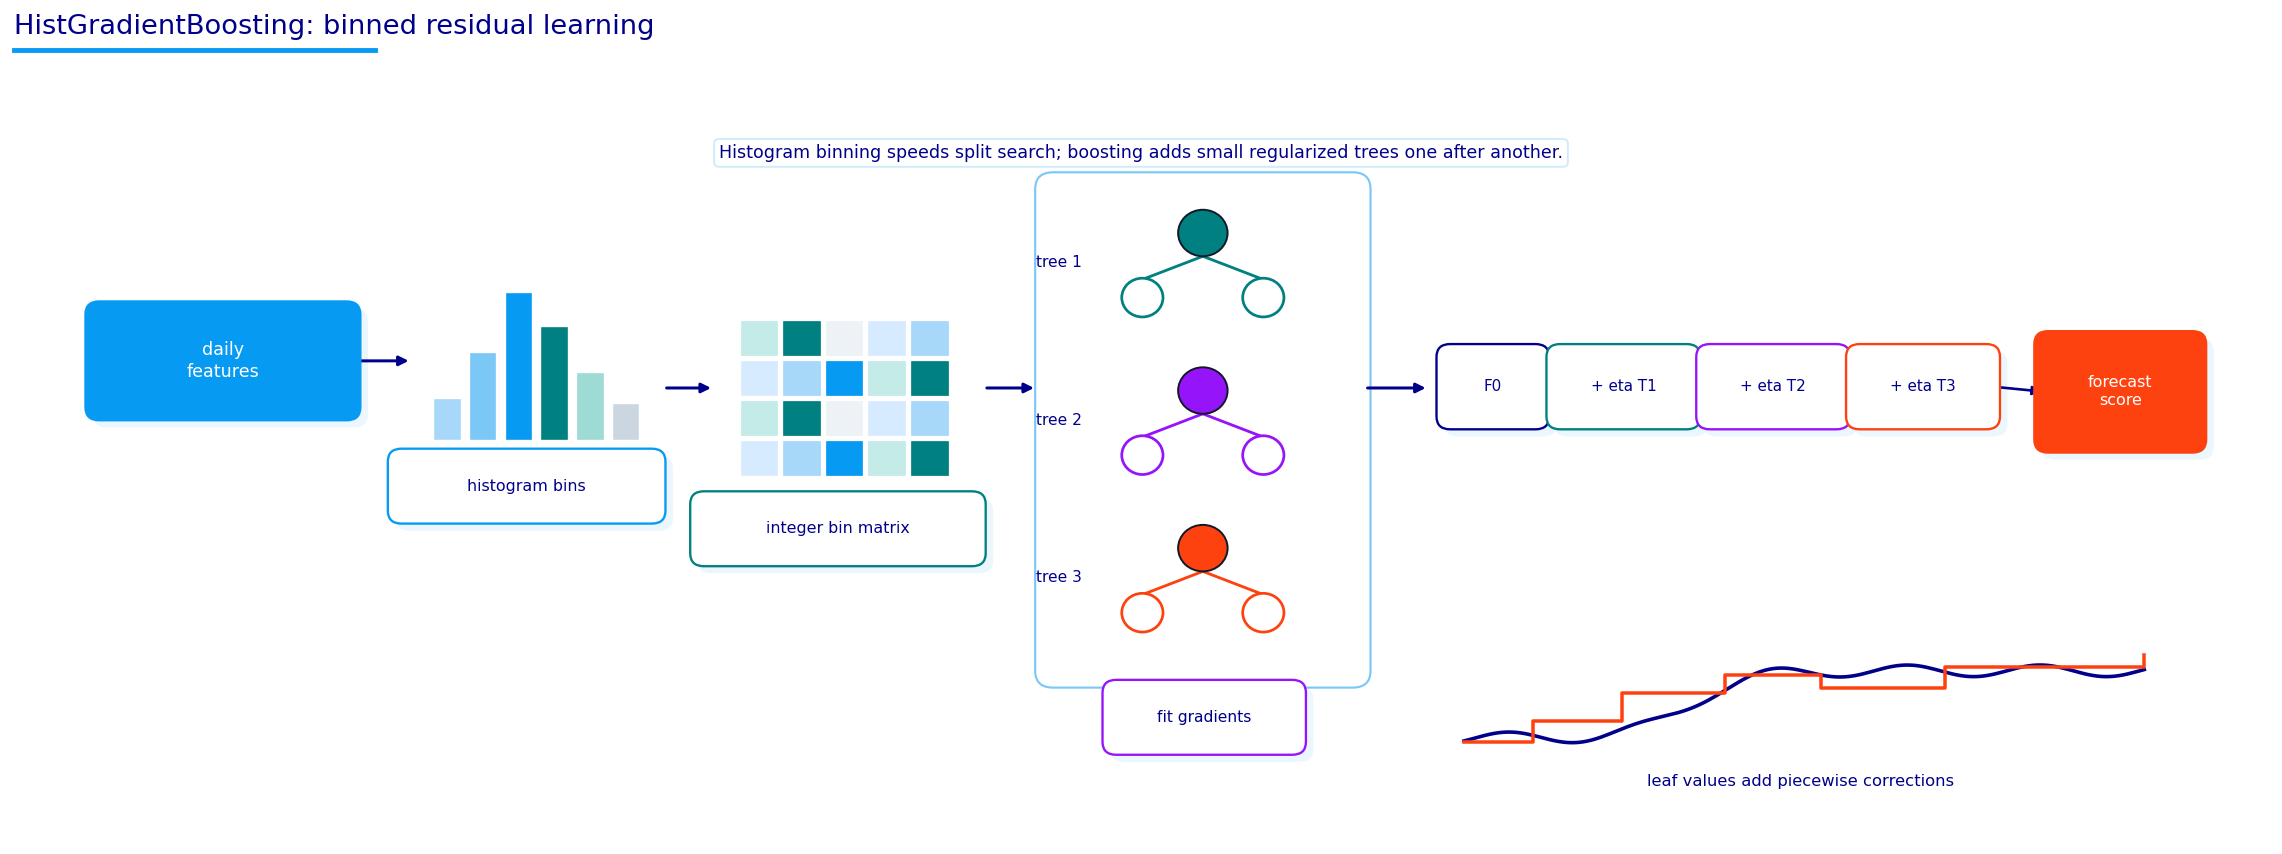

In [4]:
fig, ax = hist_gradient_boosting_diagram()
plt.show()

In [28]:
def fit_gb_for_refit(i, dt):
    train_mask, _ = train_mask_for_refit(dt)
    pred_dates = prediction_dates_for_refit(i)
    if train_mask.sum() < 500 or len(pred_dates) == 0:
        return None
    model = GradientBoostingRegressor(
        n_estimators=700,
        learning_rate=0.012,
        max_depth=2,
        min_samples_leaf=30,
        subsample=0.75,
        random_state=42,
    )
    with threadpool_limits(limits=forest_inner_jobs):
        model.fit(x.loc[train_mask], y.loc[train_mask])
    out = prediction_frame_from_model(model, pred_dates)
    return out.rename(columns={"prediction": "z_gb"})

gb_rows = Parallel(n_jobs=outer_n_jobs, prefer="threads", batch_size=1)(
    delayed(fit_gb_for_refit)(i, dt) for i, dt in enumerate(refit_dates)
)
pred_gb = _concat_nonempty(gb_rows)
display(pred_gb.tail())

,date,asset,z_gb
28591,2026-04-23,LQD,-0.081109
28592,2026-04-23,QQQ,-0.009408
28593,2026-04-23,SPY,0.034975
28594,2026-04-23,TLT,-0.154030
28595,2026-04-23,VNQ,0.053354


In [29]:
def fit_hgb_for_refit(i, dt):
    train_mask, _ = train_mask_for_refit(dt)
    pred_dates = prediction_dates_for_refit(i)
    if train_mask.sum() < 500 or len(pred_dates) == 0:
        return None
    model = HistGradientBoostingRegressor(
        loss="squared_error",
        max_iter=650,
        learning_rate=0.018,
        max_leaf_nodes=21,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42,
    )
    with threadpool_limits(limits=forest_inner_jobs):
        model.fit(x.loc[train_mask], y.loc[train_mask])
    out = prediction_frame_from_model(model, pred_dates)
    return out.rename(columns={"prediction": "z_hgb"})

hgb_rows = Parallel(n_jobs=outer_n_jobs, prefer="threads", batch_size=1)(
    delayed(fit_hgb_for_refit)(i, dt) for i, dt in enumerate(refit_dates)
)
pred_hgb = _concat_nonempty(hgb_rows)
display(pred_hgb.tail())

,date,asset,z_hgb
28591,2026-04-23,LQD,-0.016182
28592,2026-04-23,QQQ,0.049299
28593,2026-04-23,SPY,0.082925
28594,2026-04-23,TLT,0.101372
28595,2026-04-23,VNQ,0.127085


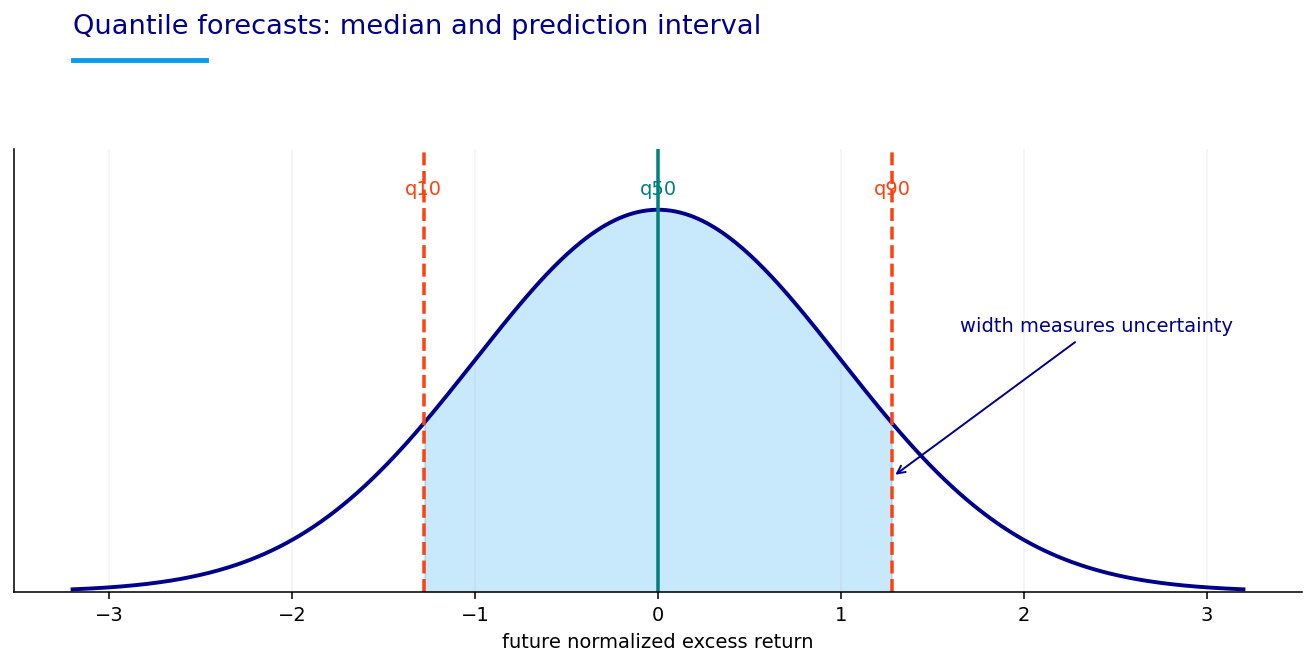

In [30]:
fig, ax = quantile_forecast()
plt.show()

In [31]:
def fit_qgb_for_refit(i, dt):
    train_mask, _ = train_mask_for_refit(dt)
    pred_dates = prediction_dates_for_refit(i)
    if train_mask.sum() < 500 or len(pred_dates) == 0:
        return None
    preds = {}
    for tau in [0.10, 0.50, 0.90]:
        q_model = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=tau,
            max_iter=550,
            learning_rate=0.018,
            max_leaf_nodes=21,
            min_samples_leaf=30,
            l2_regularization=0.05,
            random_state=42,
        )
        with threadpool_limits(limits=forest_inner_jobs):
            q_model.fit(x.loc[train_mask], y.loc[train_mask])
        preds[tau] = q_model
    frames = []
    for pred_dt in pred_dates:
        test_mask = dates.eq(pd.Timestamp(pred_dt))
        if test_mask.sum() == 0:
            continue
        frames.append(pd.DataFrame({
            "date": dates.loc[test_mask].values,
            "asset": asset_name.loc[test_mask].values,
            "q10_gb": preds[0.10].predict(x.loc[test_mask]),
            "q50_gb": preds[0.50].predict(x.loc[test_mask]),
            "q90_gb": preds[0.90].predict(x.loc[test_mask]),
        }))
    return _concat_nonempty(frames)

qgb_rows = Parallel(n_jobs=outer_n_jobs, prefer="threads", batch_size=1)(
    delayed(fit_qgb_for_refit)(i, dt) for i, dt in enumerate(refit_dates)
)
pred_qgb = _concat_nonempty(qgb_rows)
display(pred_qgb.tail())

,date,asset,q10_gb,q50_gb,q90_gb
28591,2026-04-23,LQD,-0.514548,0.035183,0.470533
28592,2026-04-23,QQQ,-0.444659,0.018488,0.789668
28593,2026-04-23,SPY,-0.295192,0.008503,0.755594
28594,2026-04-23,TLT,-0.580192,-0.038420,0.696901
28595,2026-04-23,VNQ,-0.698979,0.131148,1.070999


In [32]:
tab_predictions = (
    pred_enet.merge(pred_rf, on=["date", "asset"], how="outer")
    .merge(pred_et, on=["date", "asset"], how="outer")
    .merge(pred_gb, on=["date", "asset"], how="outer")
    .merge(pred_hgb, on=["date", "asset"], how="outer")
    .merge(pred_qgb, on=["date", "asset"], how="outer")
)
tab_eval = data[["date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21"]].merge(tab_predictions, on=["date", "asset"], how="inner")
display(pd.Series({"tabular_prediction_rows": len(tab_eval), "unique_prediction_dates": tab_eval["date"].nunique()}).to_frame("daily_forecast_coverage"))
display(tab_eval.tail())

,daily_forecast_coverage
tabular_prediction_rows,28596
unique_prediction_dates,2383


,date,asset,y_alpha,z_21,r_ex_21,sigma_21,z_enet,enet_alpha,enet_l1_ratio,enet_valid_rank_ic,z_rf,z_et,z_gb,z_hgb,q10_gb,q50_gb,q90_gb
28591,2026-04-23,LQD,-0.965276,-0.781233,-0.013795,0.017658,-0.151458,0.001,0.5,0.134975,-0.033306,-0.050052,-0.081109,-0.016182,-0.514548,0.035183,0.470533
28592,2026-04-23,QQQ,1.379158,1.563201,0.087269,0.055827,0.010342,0.001,0.5,0.134975,0.020182,0.044793,-0.009408,0.049299,-0.444659,0.018488,0.789668
28593,2026-04-23,SPY,0.790035,0.974078,0.042004,0.043121,0.030339,0.001,0.5,0.134975,0.028070,0.036501,0.034975,0.082925,-0.295192,0.008503,0.755594
28594,2026-04-23,TLT,-1.244851,-1.060808,-0.030560,0.028808,-0.202368,0.001,0.5,0.134975,-0.086812,-0.057886,-0.154030,0.101372,-0.580192,-0.038420,0.696901
28595,2026-04-23,VNQ,-0.014975,0.169068,0.007149,0.042287,0.158984,0.001,0.5,0.134975,0.035006,-0.009271,0.053354,0.127085,-0.698979,0.131148,1.070999


In [33]:
tab_eval_test = tab_eval[tab_eval["date"] >= test_start].copy()
tabular_prediction_cols = ["z_enet", "z_rf", "z_et", "z_gb", "z_hgb", "q50_gb"]
tabular_metrics = forecast_metrics(
    tab_eval_test,
    y_col="y_alpha",
    prediction_cols=tabular_prediction_cols,
)
tabular_rank_metrics = rank_metrics(
    tab_eval_test,
    date_col="date",
    asset_col="asset",
    y_col="y_alpha",
    prediction_cols=tabular_prediction_cols,
)
display(tabular_metrics.round(4))
display(tabular_rank_metrics.round(4))

,n,MAE,RMSE,Spearman IC,Directional Accuracy,Bias
model,,,,,,
z_enet,22464,0.5830,0.8370,-0.0070,0.5057,-0.0568
z_rf,22464,0.5435,0.8017,0.0855,0.5311,-0.0206
z_et,22464,0.5381,0.7964,0.1186,0.5476,-0.0283
z_gb,22464,0.5610,0.8186,0.0399,0.5170,-0.0145
z_hgb,22464,0.5860,0.8442,0.0485,0.5182,-0.0258
q50_gb,22464,0.5542,0.8159,0.0697,0.5191,-0.0362


,mean_rank_ic,rank_ic_t,bucket_spread,top_k_hit_rate,bucket_monotonicity,positive_ic_share
model,,,,,,
z_enet,0.0267,2.8324,-0.0398,0.2621,0.0329,0.5326
z_rf,0.0851,9.1637,0.1220,0.2867,0.0942,0.5833
z_et,0.1382,14.9390,0.1847,0.2959,0.1644,0.6410
z_gb,0.0492,5.5261,0.0533,0.2867,0.0419,0.5459
z_hgb,0.0541,5.5404,0.0841,0.2890,0.0622,0.5550
q50_gb,0.0558,5.8450,0.0468,0.2764,0.0577,0.5470


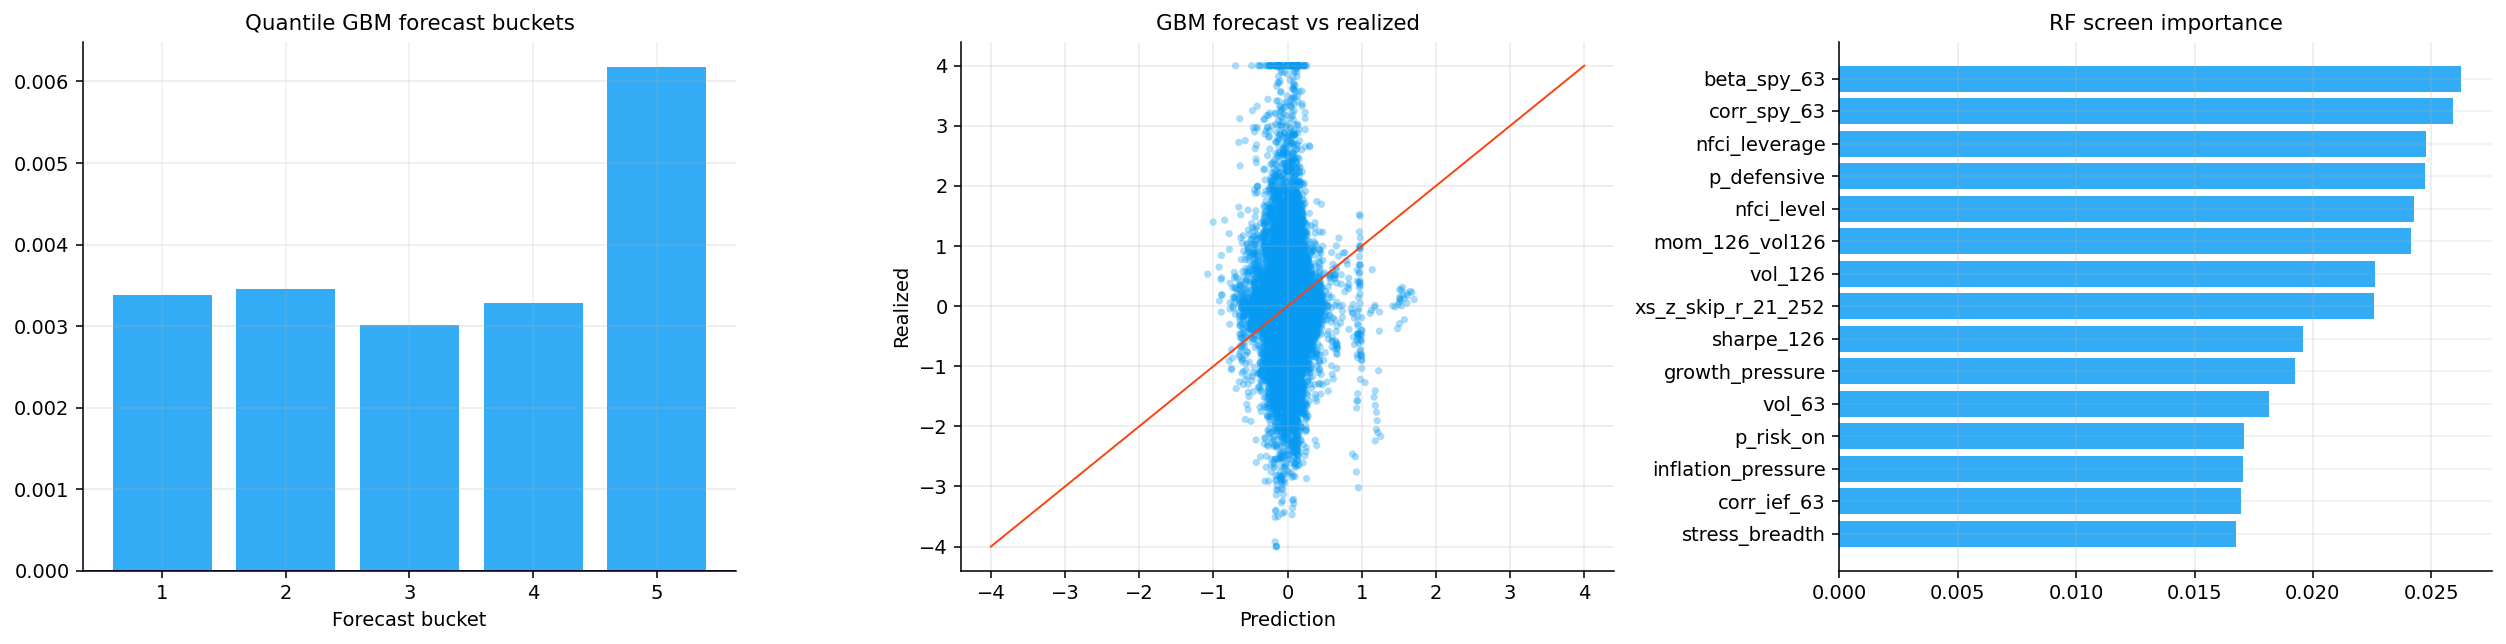

In [34]:
tab_bucket = forecast_buckets(tab_eval_test, date_col="date", y_col="r_ex_21", score_col="q50_gb", n_buckets=5)

fig, axes = plt.subplots(1, 3, figsize=(18.0, 4.7))
forecast_buckets_chart(axes[0], tab_bucket, title="Quantile GBM forecast buckets")
forecast_scatter(axes[1], tab_eval_test, y_col="y_alpha", pred_col="z_gb", title="GBM forecast vs realized")
feature_importance_bars(axes[2], rf_importance.head(15), title="RF screen importance")
fig.tight_layout()
plt.show()

## Torch Neural Forecasting

In [35]:
train_mask_static = dates <= train_label_cutoff
nn_scaler = StandardScaler()
x_train_nn_z = nn_scaler.fit_transform(x_nn.loc[train_mask_static])
x_all_nn_z = pd.DataFrame(nn_scaler.transform(x_nn), index=x_nn.index, columns=selected_features_nn)

x_mlp = torch.tensor(x_all_nn_z.to_numpy(np.float32), dtype=torch.float32)
a_mlp = torch.tensor(asset_id.to_numpy(np.int64), dtype=torch.long)
y_mlp = torch.tensor(y.to_numpy(np.float32), dtype=torch.float32)
dates_mlp = pd.to_datetime(dates).to_numpy()

x_mlp.shape, a_mlp.shape, y_mlp.shape, device

(torch.Size([57756, 28]),
 torch.Size([57756]),
 torch.Size([57756]),
 device(type='cuda'))

In [36]:
asset_mapping = pd.Series(asset_map, name="asset_id").to_frame()
display(asset_mapping)

,asset_id
SPY,0
QQQ,1
IWM,2
EFA,3
EEM,4
VNQ,5
DBC,6
GLD,7
IEF,8
TLT,9


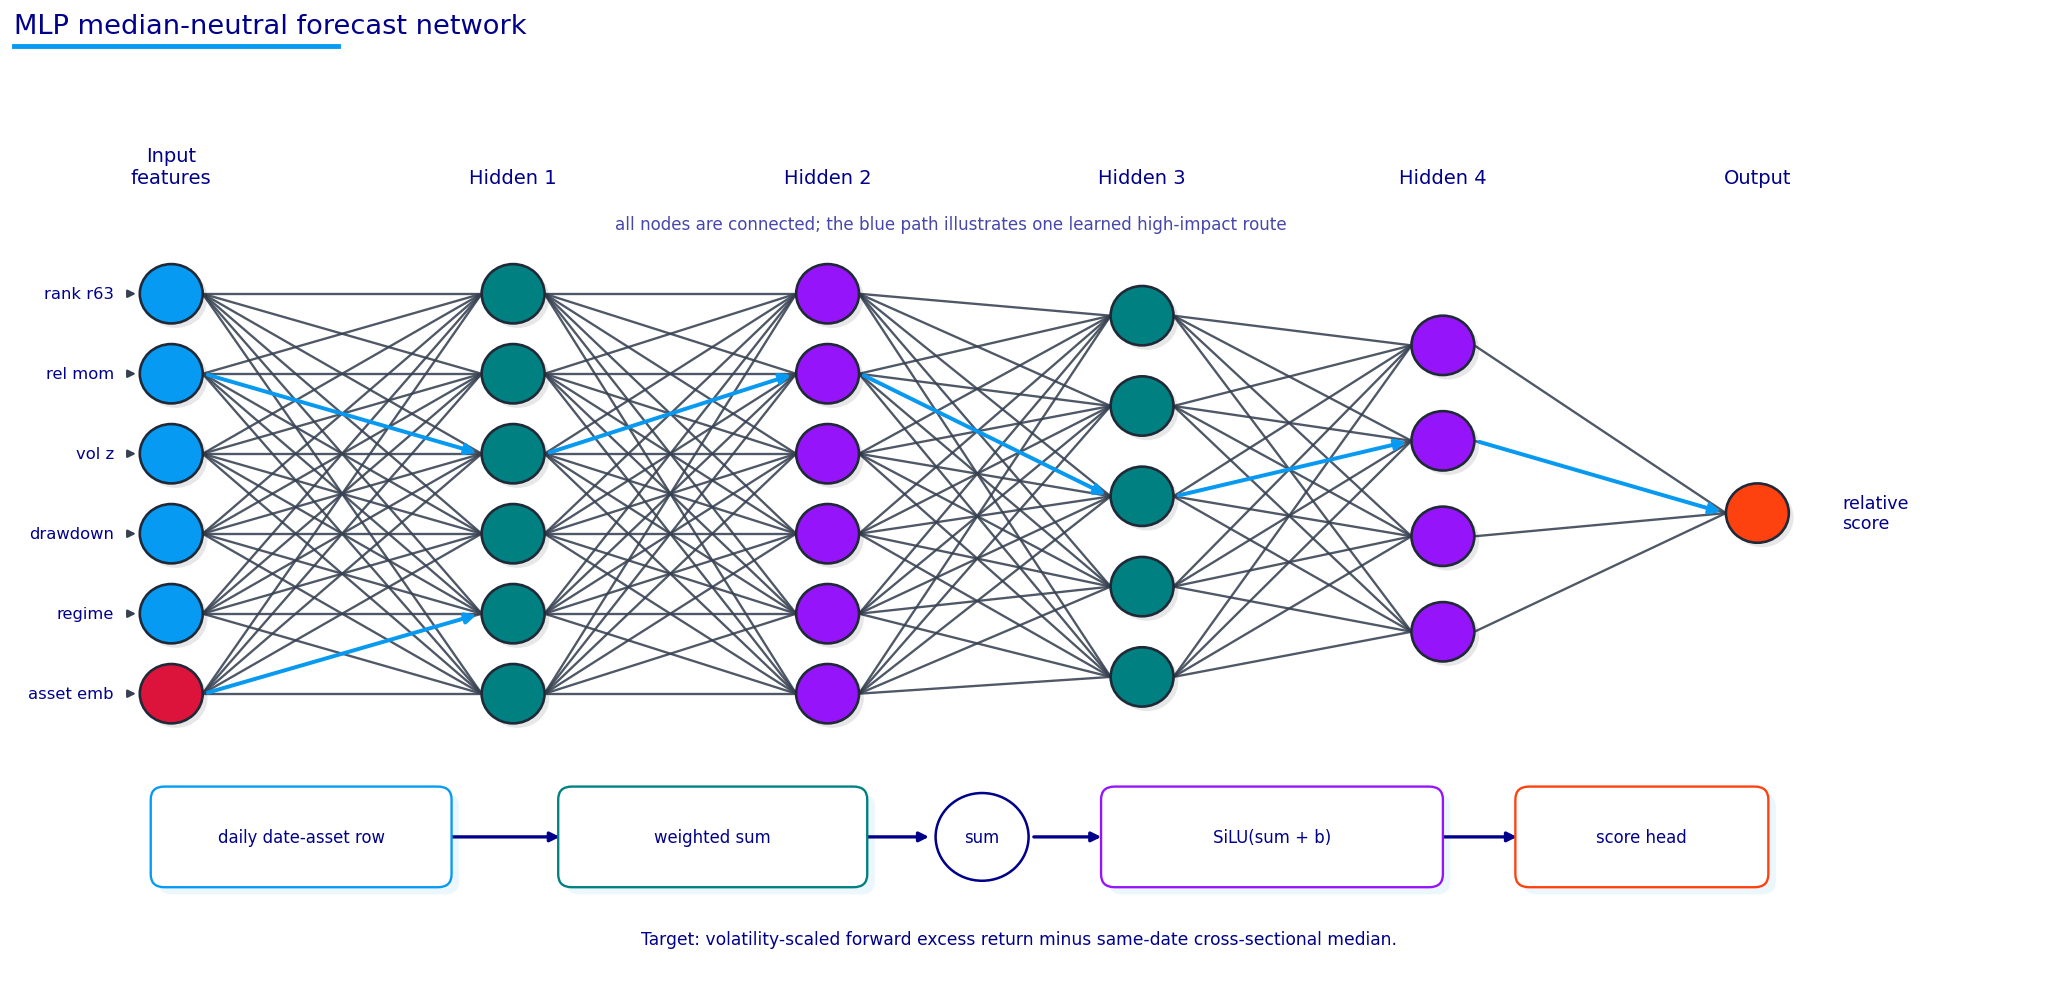

In [5]:
fig, ax = mlp_architecture()
plt.show()

In [38]:
class MLPForecast(nn.Module):
    def __init__(self, n_features, n_assets, embedding_dim=4, hidden_sizes=(64, 32), output_size=1, dropout=0.10):
        super().__init__()
        self.embedding = nn.Embedding(n_assets, embedding_dim)
        layers = []
        in_dim = n_features + embedding_dim
        for hidden in hidden_sizes:
            layers += [nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            in_dim = hidden
        layers.append(nn.Linear(in_dim, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x, asset_id):
        emb = self.embedding(asset_id.long())
        return self.net(torch.cat([x.float(), emb], dim=1))

In [39]:
def _point_prediction_array(pred):
    arr = np.asarray(pred)
    if arr.ndim == 1:
        return arr.astype(float)
    if arr.shape[1] >= 3:
        return arr[:, 1].astype(float)
    return arr[:, 0].astype(float)


def _concat_prediction_batches(batches):
    arrays = []
    for batch in batches:
        arr = np.asarray(batch)
        if arr.ndim == 1:
            arr = arr.reshape(-1, 1)
        arrays.append(arr)
    return np.concatenate(arrays, axis=0) if arrays else np.empty((0, 1))


def _torch_forecast_loss(pred, yb, loss_name="huber", quantiles=None):
    if loss_name == "pinball":
        q = torch.tensor(quantiles or [0.10, 0.50, 0.90], device=device)
        err = yb.view(-1, 1) - pred
        return torch.maximum(q * err, (q - 1.0) * err).mean()
    if loss_name == "nll":
        mean = pred[:, 0]
        log_var = pred[:, 1].clamp(-8.0, 6.0)
        return 0.5 * (log_var + torch.square(yb - mean) / torch.exp(log_var)).mean()
    return torch.nn.functional.smooth_l1_loss(pred.view(-1), yb)


def _validation_forecast_score(pred, target, dates_eval, assets_eval, top_frac=0.25, turnover_penalty=0.02):
    frame = pd.DataFrame({
        "date": pd.to_datetime(dates_eval),
        "asset": np.asarray(assets_eval).astype(str),
        "prediction": _point_prediction_array(pred),
        "target": np.asarray(target, dtype=float),
    }).replace([np.inf, -np.inf], np.nan).dropna()
    if frame.empty:
        return {"validation_score": np.nan, "rank_ic": np.nan, "bucket_spread": np.nan, "top_k_hit_rate": np.nan, "turnover": np.nan}

    rank_ic, bucket_spread, top_hit, turnover = [], [], [], []
    prev_top = None
    for _, group in frame.groupby("date", sort=True):
        if len(group) < 4:
            continue
        rank_ic.append(spearmanr(group["prediction"], group["target"]).correlation)
        k = max(1, int(np.ceil(len(group) * top_frac)))
        ordered = group.sort_values("prediction")
        bucket_spread.append(float(ordered.tail(k)["target"].mean() - ordered.head(k)["target"].mean()))
        pred_top = set(ordered.tail(k)["asset"])
        actual_top = set(group.sort_values("target").tail(k)["asset"])
        top_hit.append(float(len(pred_top & actual_top) / max(1, k)))
        if prev_top is not None:
            union = len(pred_top | prev_top)
            turnover.append(float(1.0 - len(pred_top & prev_top) / union) if union else 0.0)
        prev_top = pred_top

    rank_ic_mean = float(pd.Series(rank_ic).mean()) if rank_ic else np.nan
    spread_mean = float(pd.Series(bucket_spread).mean()) if bucket_spread else np.nan
    hit_mean = float(pd.Series(top_hit).mean()) if top_hit else np.nan
    turnover_mean = float(pd.Series(turnover).mean()) if turnover else 0.0
    score = (
        0.50 * (rank_ic_mean if np.isfinite(rank_ic_mean) else 0.0)
        + 0.35 * (spread_mean if np.isfinite(spread_mean) else 0.0)
        + 0.15 * ((hit_mean - top_frac) if np.isfinite(hit_mean) else 0.0)
        - turnover_penalty * (turnover_mean if np.isfinite(turnover_mean) else 0.0)
    )
    return {
        "validation_score": float(score),
        "rank_ic": rank_ic_mean,
        "bucket_spread": spread_mean,
        "top_k_hit_rate": hit_mean,
        "turnover": turnover_mean,
    }


def train_model(
    model,
    X,
    A,
    Y,
    mask,
    *,
    dates_for_split=None,
    valid_start="2017-01-01",
    valid_end="2018-12-31",
    epochs=80,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-4,
    loss_name="huber",
    quantiles=None,
    patience=12,
    early_stop_metric="composite",
    top_frac=0.25,
    turnover_penalty=0.02,
):
    idx = np.where(np.asarray(mask))[0]
    if dates_for_split is not None:
        d = pd.to_datetime(np.asarray(dates_for_split))
        train_idx = np.where(d < pd.Timestamp(valid_start))[0]
        valid_idx = np.where((d >= pd.Timestamp(valid_start)) & (d <= pd.Timestamp(valid_end)))[0]
        train_idx = np.intersect1d(train_idx, idx)
        valid_idx = np.intersect1d(valid_idx, idx)
    else:
        split = max(1, int(len(idx) * 0.80))
        train_idx = idx[:split]
        valid_idx = idx[split:]
    if len(train_idx) < 10 or len(valid_idx) < 1:
        split = max(1, int(len(idx) * 0.80))
        train_idx = idx[:split]
        valid_idx = idx[split:]

    train_ds = TensorDataset(X[train_idx], A[train_idx], Y[train_idx])
    valid_ds = TensorDataset(X[valid_idx], A[valid_idx], Y[valid_idx])
    pin_memory = bool(torch.cuda.is_available() and str(device).startswith("cuda"))
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="max",
        factor=0.5,
        patience=max(5, int(patience) // 4),
        min_lr=1e-5,
    )
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_value = -np.inf
    bad = 0
    rows = []

    valid_dates_for_score = pd.to_datetime(np.asarray(dates_for_split)[valid_idx]) if dates_for_split is not None else None
    valid_assets_for_score = A[valid_idx].detach().cpu().numpy()
    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, ab, yb in loader:
            xb, ab, yb = xb.to(device), ab.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = _torch_forecast_loss(model(xb, ab), yb, loss_name=loss_name, quantiles=quantiles)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        valid_losses, valid_preds, valid_targets = [], [], []
        with torch.no_grad():
            for xb, ab, yb in valid_loader:
                xb, ab, yb = xb.to(device), ab.to(device), yb.to(device)
                pred = model(xb, ab)
                valid_losses.append(float(_torch_forecast_loss(pred, yb, loss_name=loss_name, quantiles=quantiles).detach().cpu()))
                valid_preds.append(pred.detach().cpu().numpy())
                valid_targets.append(yb.detach().cpu().numpy())

        train_loss = float(np.mean(train_losses))
        valid_loss = float(np.mean(valid_losses)) if valid_losses else train_loss
        score_stats = {"validation_score": np.nan, "rank_ic": np.nan, "bucket_spread": np.nan, "top_k_hit_rate": np.nan, "turnover": np.nan}
        if str(early_stop_metric).lower() in {"composite", "rank", "selection"} and valid_dates_for_score is not None:
            score_stats = _validation_forecast_score(
                _concat_prediction_batches(valid_preds),
                np.concatenate(valid_targets) if valid_targets else np.asarray([]),
                valid_dates_for_score,
                valid_assets_for_score,
                top_frac=top_frac,
                turnover_penalty=turnover_penalty,
            )
        early_value = score_stats["validation_score"] if np.isfinite(score_stats["validation_score"]) else -valid_loss
        rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "validation_score": score_stats["validation_score"],
            "valid_rank_ic": score_stats["rank_ic"],
            "valid_bucket_spread": score_stats["bucket_spread"],
            "valid_top_k_hit_rate": score_stats["top_k_hit_rate"],
            "valid_turnover": score_stats["turnover"],
            "early_stop_value": early_value,
        })
        scheduler.step(float(early_value))
        if early_value > best_value + 1e-5:
            best_value = float(early_value)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if bad >= patience:
            break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(rows)


def predict_model(model, X, A, batch_size=512):
    ds = TensorDataset(X, A)
    pin_memory = bool(torch.cuda.is_available() and str(device).startswith("cuda"))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, ab in loader:
            out = model(xb.to(device), ab.to(device)).detach().cpu().numpy()
            if out.ndim == 1:
                out = out.reshape(-1, 1)
            preds.append(out)
    return np.concatenate(preds, axis=0)

In [40]:
mlp_point = MLPForecast(len(selected_features_nn), len(assets), embedding_dim=4, hidden_sizes=(128, 64, 32), dropout=0.12).to(device)
mlp_point, mlp_history = train_model(
    mlp_point,
    x_mlp,
    a_mlp,
    y_mlp,
    train_mask_static.to_numpy(),
    dates_for_split=dates_mlp,
    valid_end=validation_end.strftime("%Y-%m-%d"),
    epochs=180,
    batch_size=256,
    lr=1e-3,
    weight_decay=7.5e-5,
    patience=35,
)

mlp_pred = pd.Series(predict_model(mlp_point, x_mlp, a_mlp)[:, 0], index=data.index, name="z_mlp")
display(mlp_pred.describe().round(4))
display(mlp_history.tail().round(4))

count    57756.0000
mean        -0.0417
std          0.4118
min         -1.9000
25%         -0.1793
50%         -0.0100
75%          0.1281
max          2.2747
Name: z_mlp, dtype: float64

,epoch,train_loss,valid_loss,validation_score,valid_rank_ic,valid_bucket_spread,valid_top_k_hit_rate,valid_turnover,early_stop_value
35,36,0.1403,0.4596,0.1484,0.1228,0.2390,0.3055,0.2508,0.1484
36,37,0.1412,0.4647,0.1668,0.1359,0.2708,0.3136,0.2710,0.1668
37,38,0.1388,0.4549,0.1548,0.1311,0.2445,0.3082,0.2510,0.1548
38,39,0.1391,0.4556,0.1505,0.1259,0.2424,0.3021,0.2573,0.1505
39,40,0.1413,0.4508,0.1433,0.1267,0.2238,0.2953,0.2622,0.1433


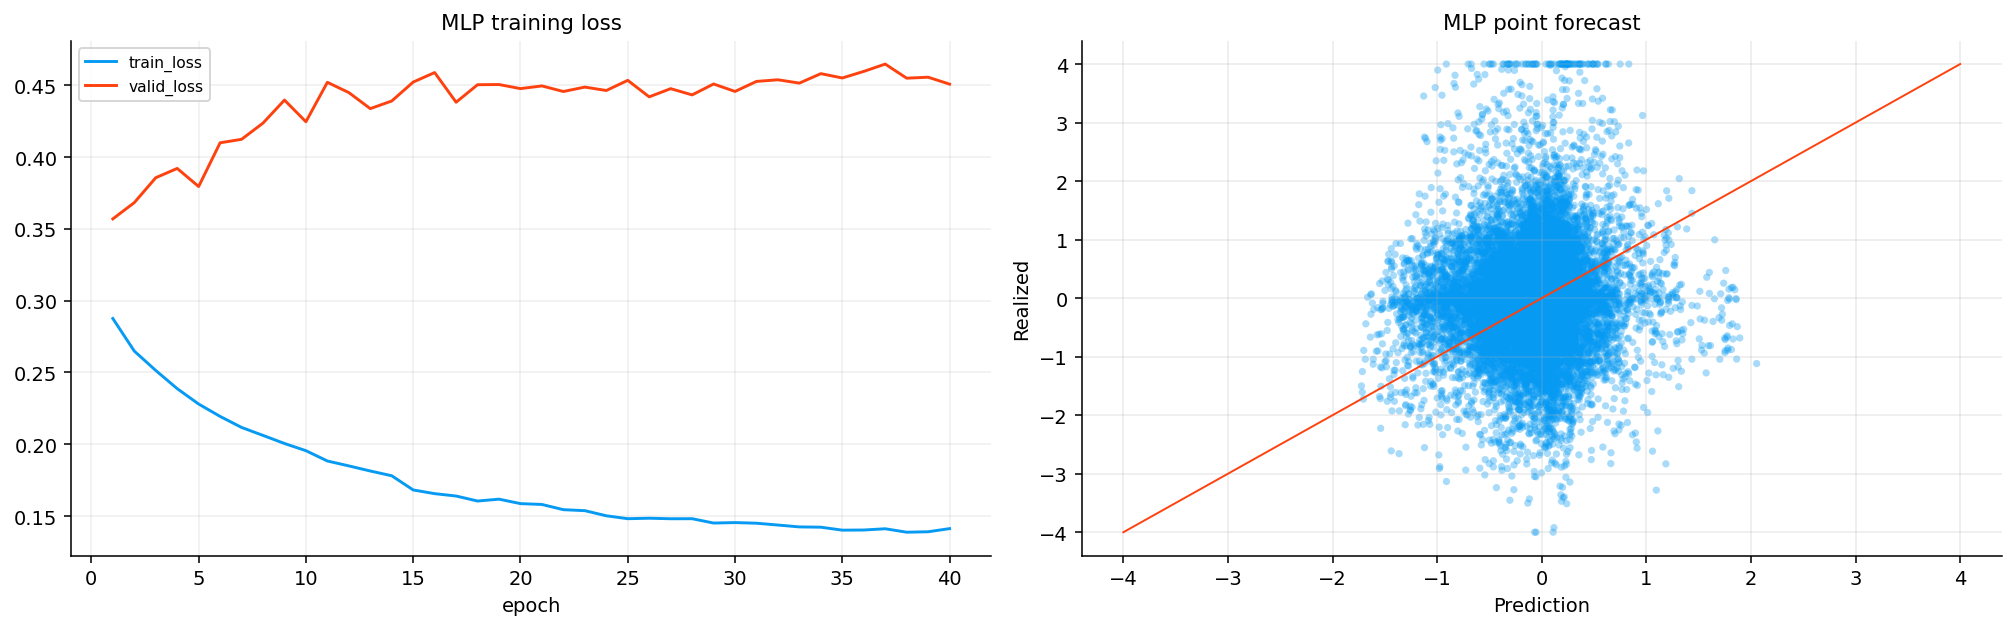

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
if not mlp_history.empty:
    mlp_history.plot(x="epoch", y=["train_loss", "valid_loss"], ax=axes[0])
else:
    axes[0].text(0.5, 0.5, "Loaded checkpoint", ha="center", va="center", transform=axes[0].transAxes)
axes[0].set_title("MLP training loss")
mlp_eval = data[["date", "asset", "y_alpha", "z_21"]].join(mlp_pred)
forecast_scatter(axes[1], mlp_eval[mlp_eval["date"] >= test_start], y_col="y_alpha", pred_col="z_mlp", title="MLP point forecast")
fig.tight_layout()
plt.show()

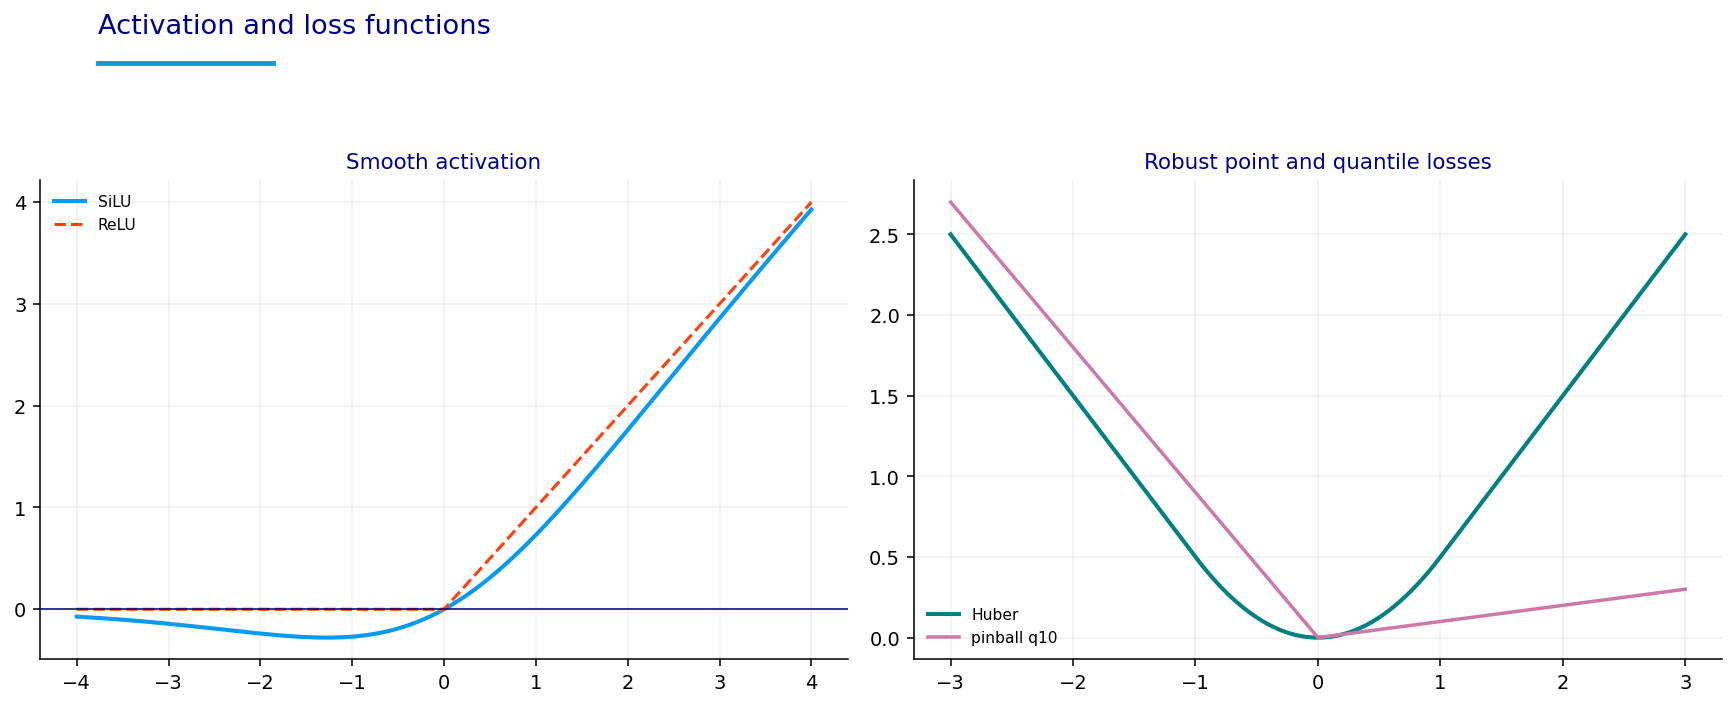

In [42]:
fig, axes = activation_loss()
plt.show()

In [43]:
reg_rows = []
for dropout, wd in [(0.00, 0.0), (0.20, 1e-4)]:
    trial = MLPForecast(len(selected_features_nn), len(assets), hidden_sizes=(48, 24), dropout=dropout).to(device)
    trial, hist = train_model(
        trial,
        x_mlp,
        a_mlp,
        y_mlp,
        train_mask_static.to_numpy(),
        dates_for_split=dates_mlp,
        valid_end=validation_end.strftime("%Y-%m-%d"),
        epochs=10,
        batch_size=256,
        lr=1e-3,
        weight_decay=wd,
        patience=3,
    )
    reg_rows.append({"dropout": dropout, "weight_decay": wd, "best_valid_loss": hist["valid_loss"].min()})
regularization_table = pd.DataFrame(reg_rows)
display(regularization_table.round(4))

,dropout,weight_decay,best_valid_loss
0,0.0,0.0000,0.3535
1,0.2,0.0001,0.3494


In [44]:
lookback = 63
seq_data = data[["date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21"]].join(x_all_nn_z[selected_features_nn]).copy()
seq_data["asset_id"] = seq_data["asset"].map(asset_map).astype(int)
seq_data = seq_data.sort_values(["asset", "date"])

def build_sequences(frame, feature_cols, target_col="y_alpha", lookback=12):
    X, A, Y, idx = [], [], [], []
    for _, group in frame.groupby("asset_id", sort=False):
        g = group.sort_values("date")
        arr = g[feature_cols].to_numpy(np.float32)
        yv = g[target_col].to_numpy(np.float32)
        aid = int(g["asset_id"].iloc[0])
        for i in range(lookback - 1, len(g)):
            X.append(arr[i - lookback + 1: i + 1])
            A.append(aid)
            Y.append(yv[i])
            idx.append(g.index[i])
    return (
        torch.tensor(np.asarray(X), dtype=torch.float32),
        torch.tensor(np.asarray(A), dtype=torch.long),
        torch.tensor(np.asarray(Y), dtype=torch.float32),
        pd.Index(idx),
    )

X_seq, A_seq, Y_seq, seq_index = build_sequences(seq_data, selected_features_nn, lookback=lookback)
seq_dates = pd.to_datetime(seq_data.loc[seq_index, "date"]).to_numpy()
seq_train_mask = pd.Series(seq_dates).le(train_label_cutoff).to_numpy()
X_seq.shape, len(seq_index)

(torch.Size([57012, 63, 28]), 57012)

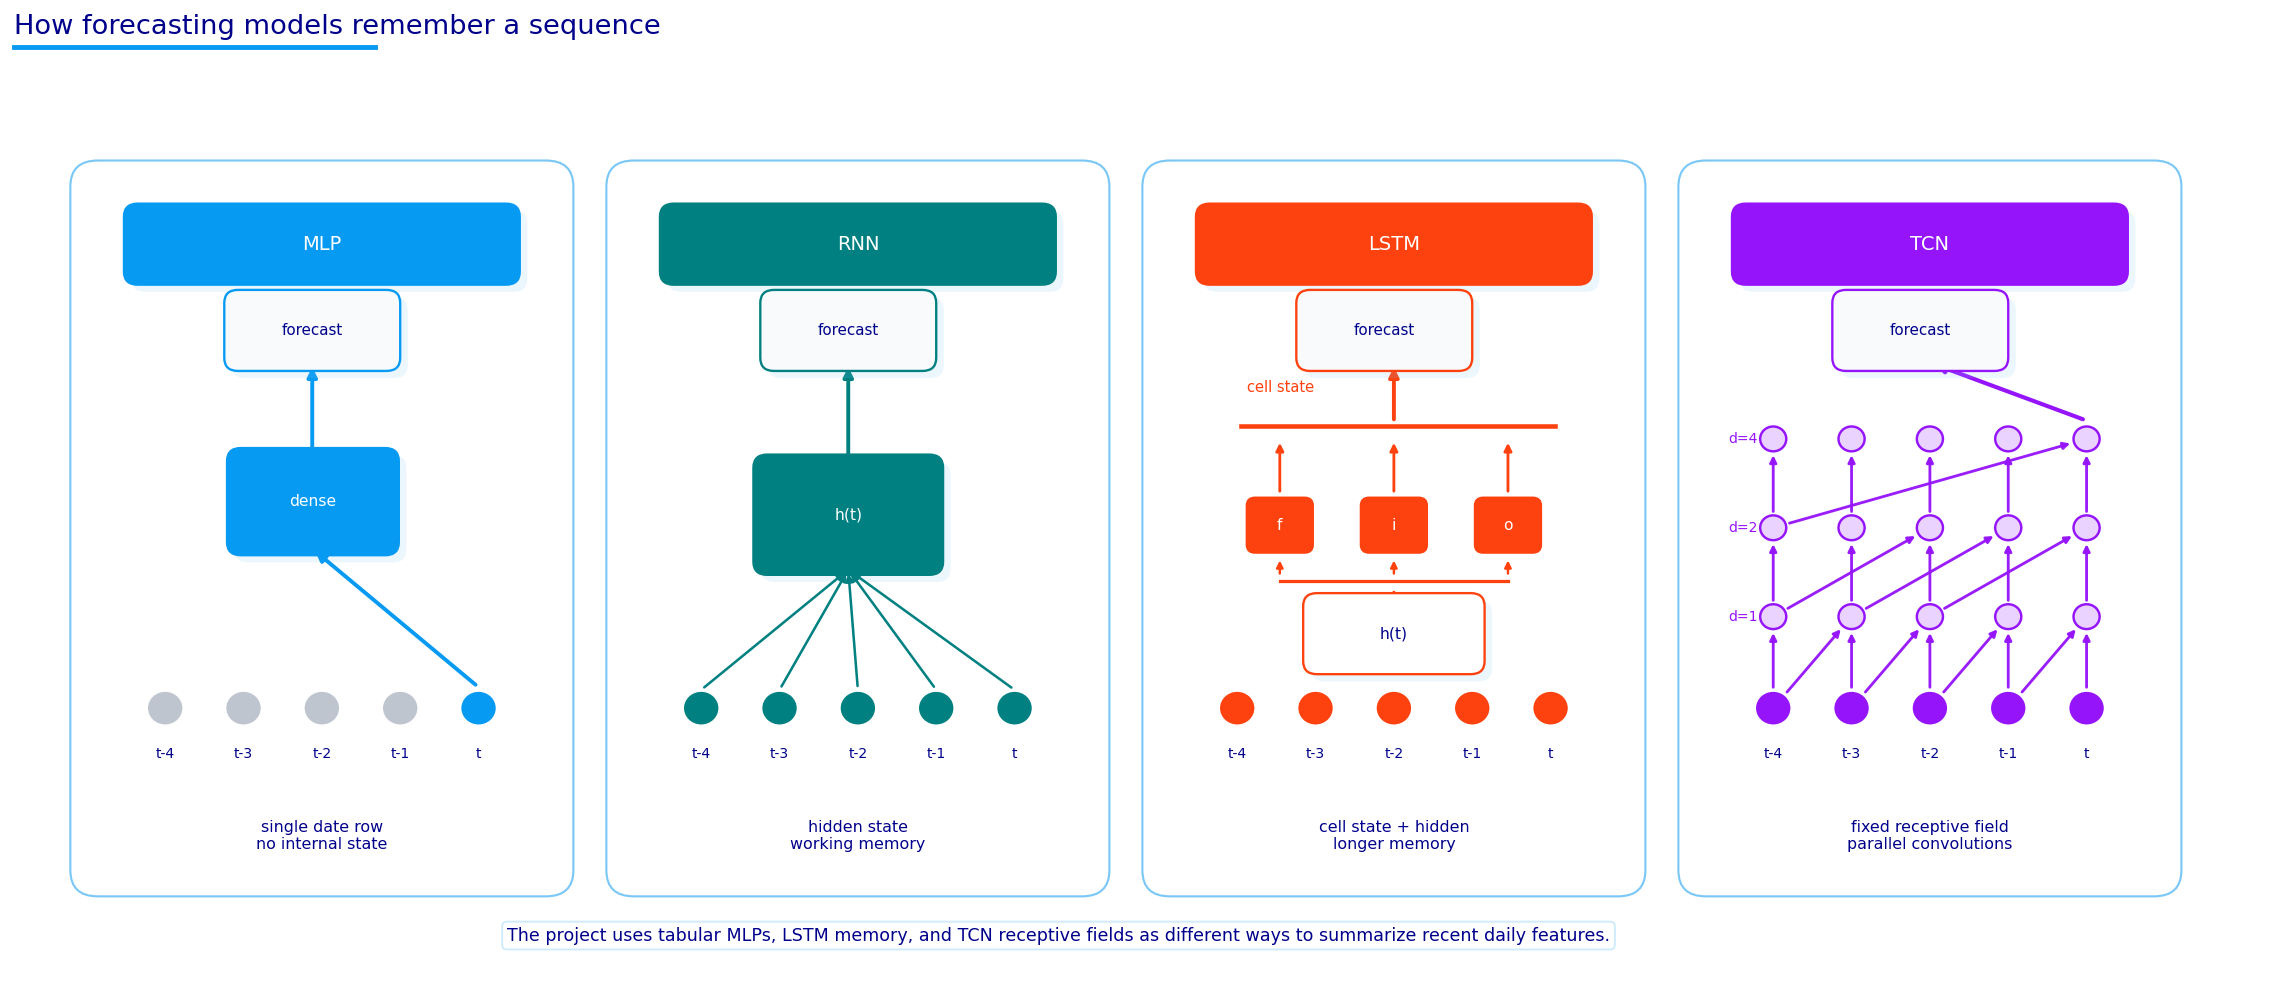

In [10]:
fig, ax = sequence_memory_comparison()
plt.show()

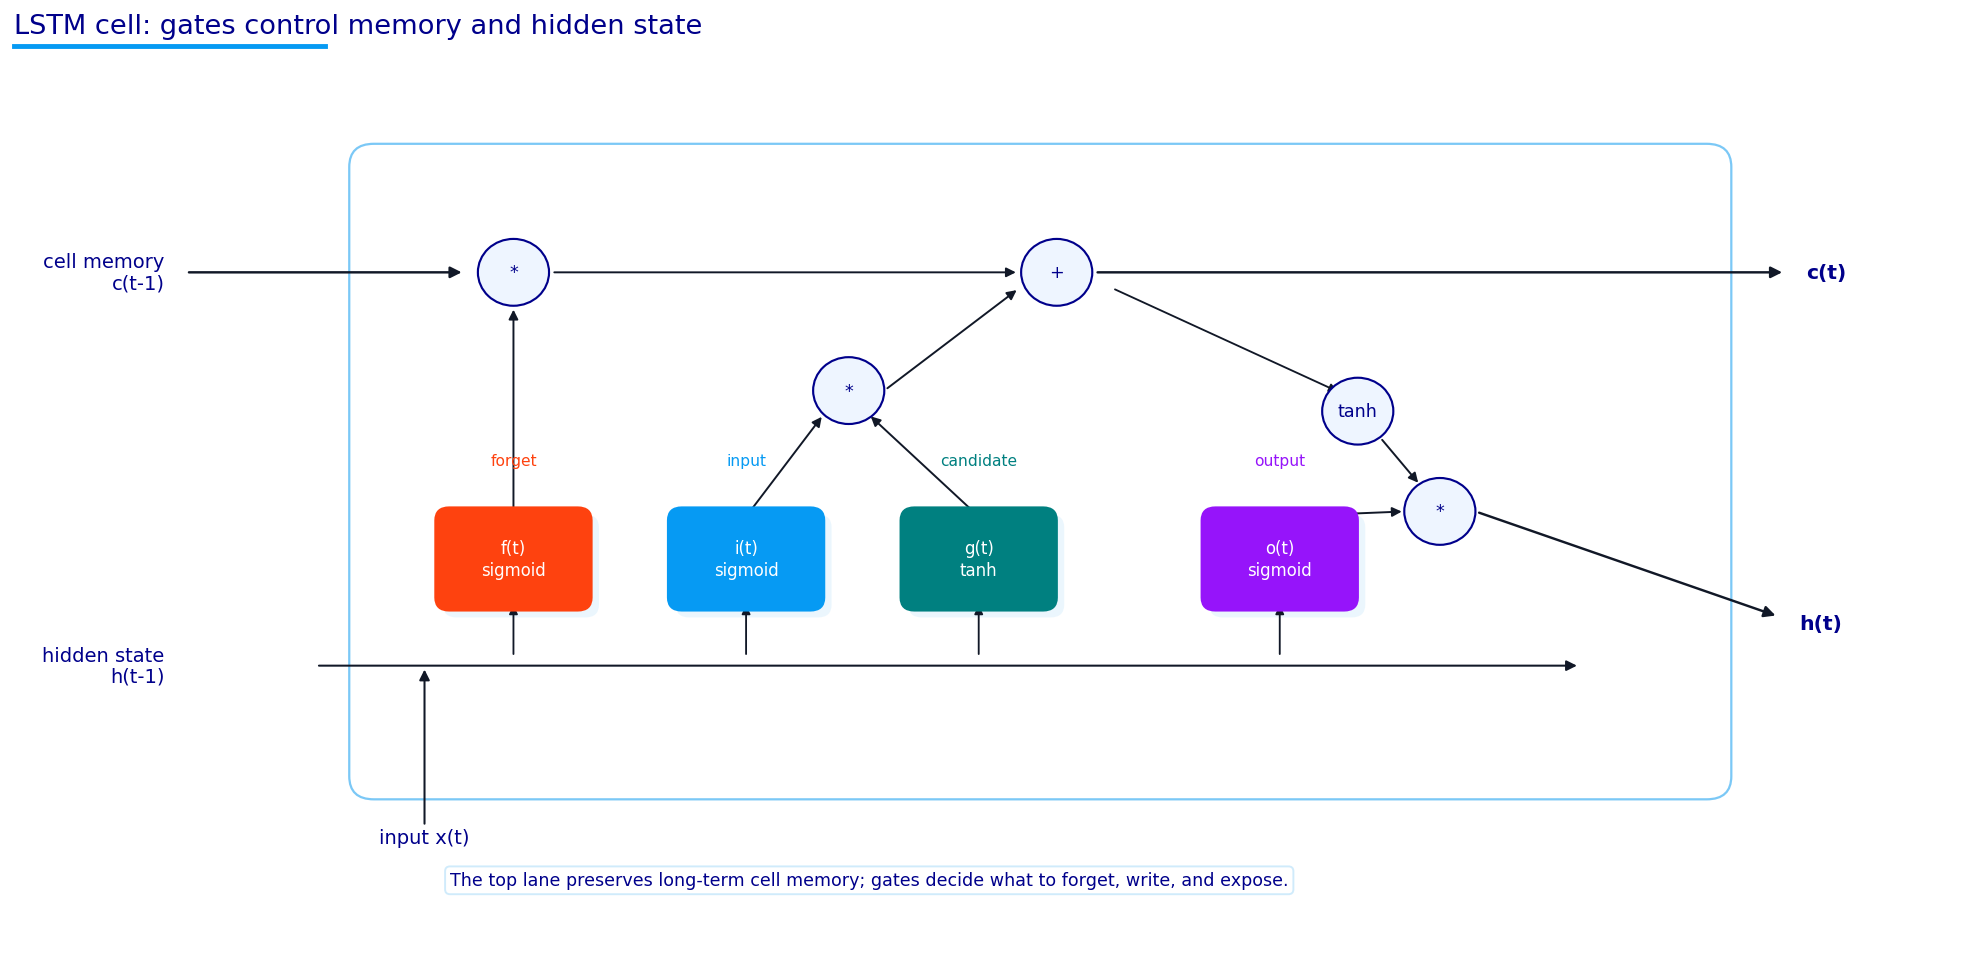

In [6]:
fig, ax = lstm_architecture()
plt.show()

In [46]:
def ordered_quantile_head(pred):
    q50 = pred[:, 1]
    q10 = q50 - torch.nn.functional.softplus(pred[:, 0])
    q90 = q50 + torch.nn.functional.softplus(pred[:, 2])
    return torch.stack([q10, q50, q90], dim=1)


class LSTMForecast(nn.Module):
    def __init__(self, n_features, n_assets, embedding_dim=4, hidden_size=64, num_layers=2, output_size=1, dropout=0.10, ordered_quantiles=False):
        super().__init__()
        self.embedding = nn.Embedding(n_assets, embedding_dim)
        self.lstm = nn.LSTM(
            n_features + embedding_dim,
            hidden_size,
            num_layers=int(num_layers),
            batch_first=True,
            dropout=float(dropout) if int(num_layers) > 1 else 0.0,
        )
        self.head = nn.Sequential(nn.LayerNorm(hidden_size), nn.Dropout(dropout), nn.Linear(hidden_size, output_size))
        self.ordered_quantiles = bool(ordered_quantiles and output_size == 3)

    def forward(self, x, asset_id):
        emb = self.embedding(asset_id.long()).unsqueeze(1).expand(-1, x.shape[1], -1)
        out, _ = self.lstm(torch.cat([x.float(), emb], dim=2))
        pred = self.head(out[:, -1, :])
        return ordered_quantile_head(pred) if self.ordered_quantiles else pred

In [47]:
lstm_point = LSTMForecast(len(selected_features_nn), len(assets), hidden_size=96, num_layers=2, dropout=0.12).to(device)
lstm_point, lstm_history = train_model(
    lstm_point,
    X_seq,
    A_seq,
    Y_seq,
    seq_train_mask,
    dates_for_split=seq_dates,
    valid_end=validation_end.strftime("%Y-%m-%d"),
    epochs=220,
    batch_size=256,
    lr=1e-3,
    weight_decay=5e-5,
    patience=40,
)

lstm_pred = pd.Series(predict_model(lstm_point, X_seq, A_seq)[:, 0], index=seq_index, name="z_lstm")
display(lstm_pred.describe().round(4))
display(lstm_history.tail().round(4))

count    57012.0000
mean         0.0140
std          0.3162
min         -1.9095
25%         -0.0885
50%          0.0658
75%          0.1691
max          2.0649
Name: z_lstm, dtype: float64

,epoch,train_loss,valid_loss,validation_score,valid_rank_ic,valid_bucket_spread,valid_top_k_hit_rate,valid_turnover,early_stop_value
36,37,0.0324,0.5471,0.1095,0.0792,0.1801,0.3136,0.1339,0.1095
37,38,0.0321,0.5448,0.1002,0.0752,0.1619,0.3069,0.1298,0.1002
38,39,0.0320,0.5421,0.0979,0.0728,0.1577,0.3089,0.1237,0.0979
39,40,0.0318,0.5390,0.0990,0.0731,0.1625,0.3048,0.1304,0.0990
40,41,0.0318,0.5443,0.1016,0.0723,0.1675,0.3130,0.1310,0.1016


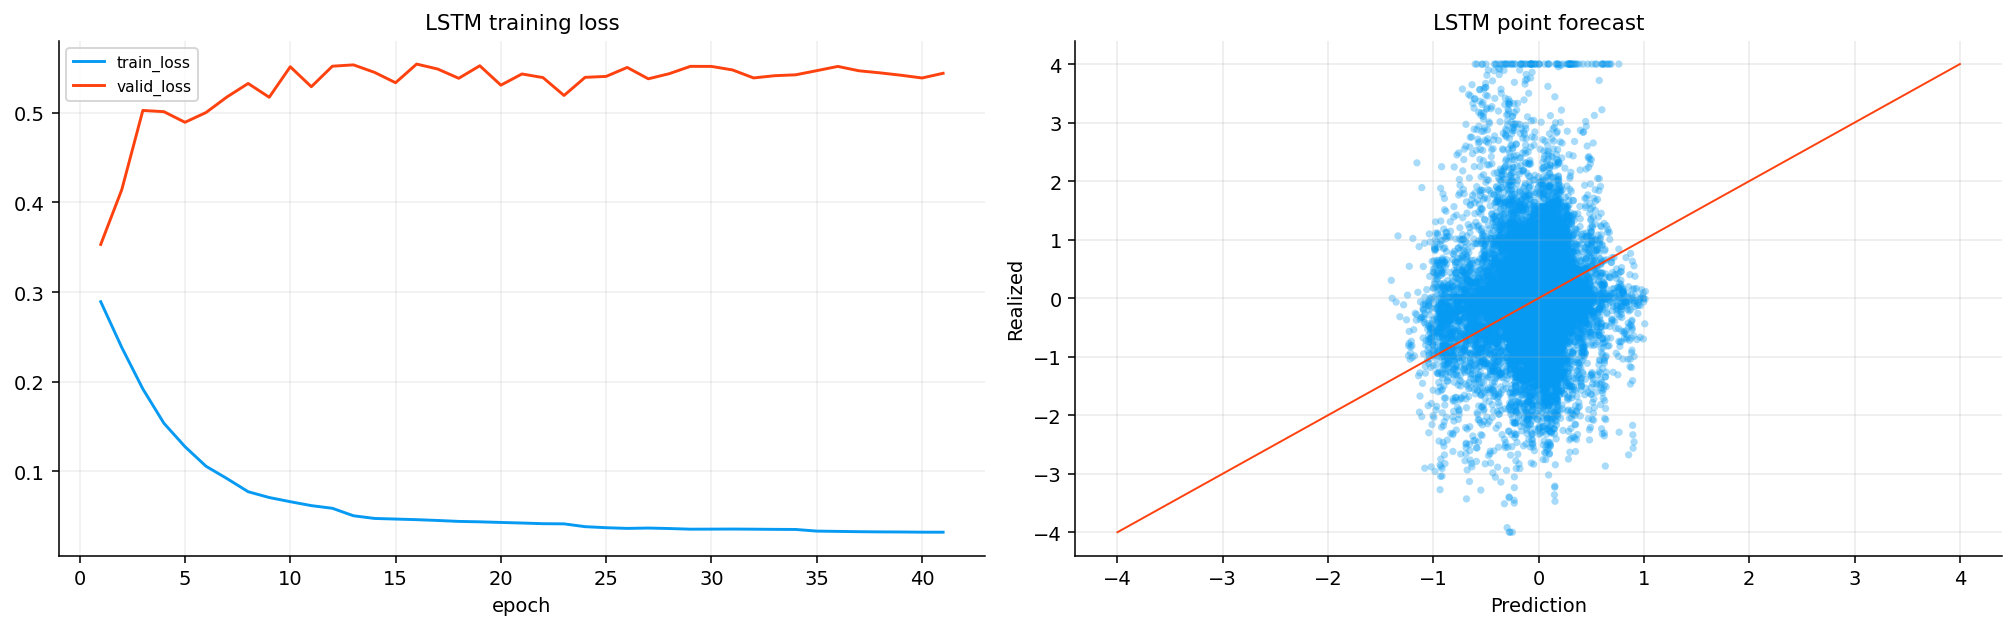

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
if not lstm_history.empty:
    lstm_history.plot(x="epoch", y=["train_loss", "valid_loss"], ax=axes[0])
else:
    axes[0].text(0.5, 0.5, "Loaded checkpoint", ha="center", va="center", transform=axes[0].transAxes)
axes[0].set_title("LSTM training loss")
lstm_eval = data[["date", "asset", "y_alpha", "z_21"]].join(lstm_pred)
forecast_scatter(axes[1], lstm_eval[lstm_eval["date"] >= test_start], y_col="y_alpha", pred_col="z_lstm", title="LSTM point forecast")
fig.tight_layout()
plt.show()

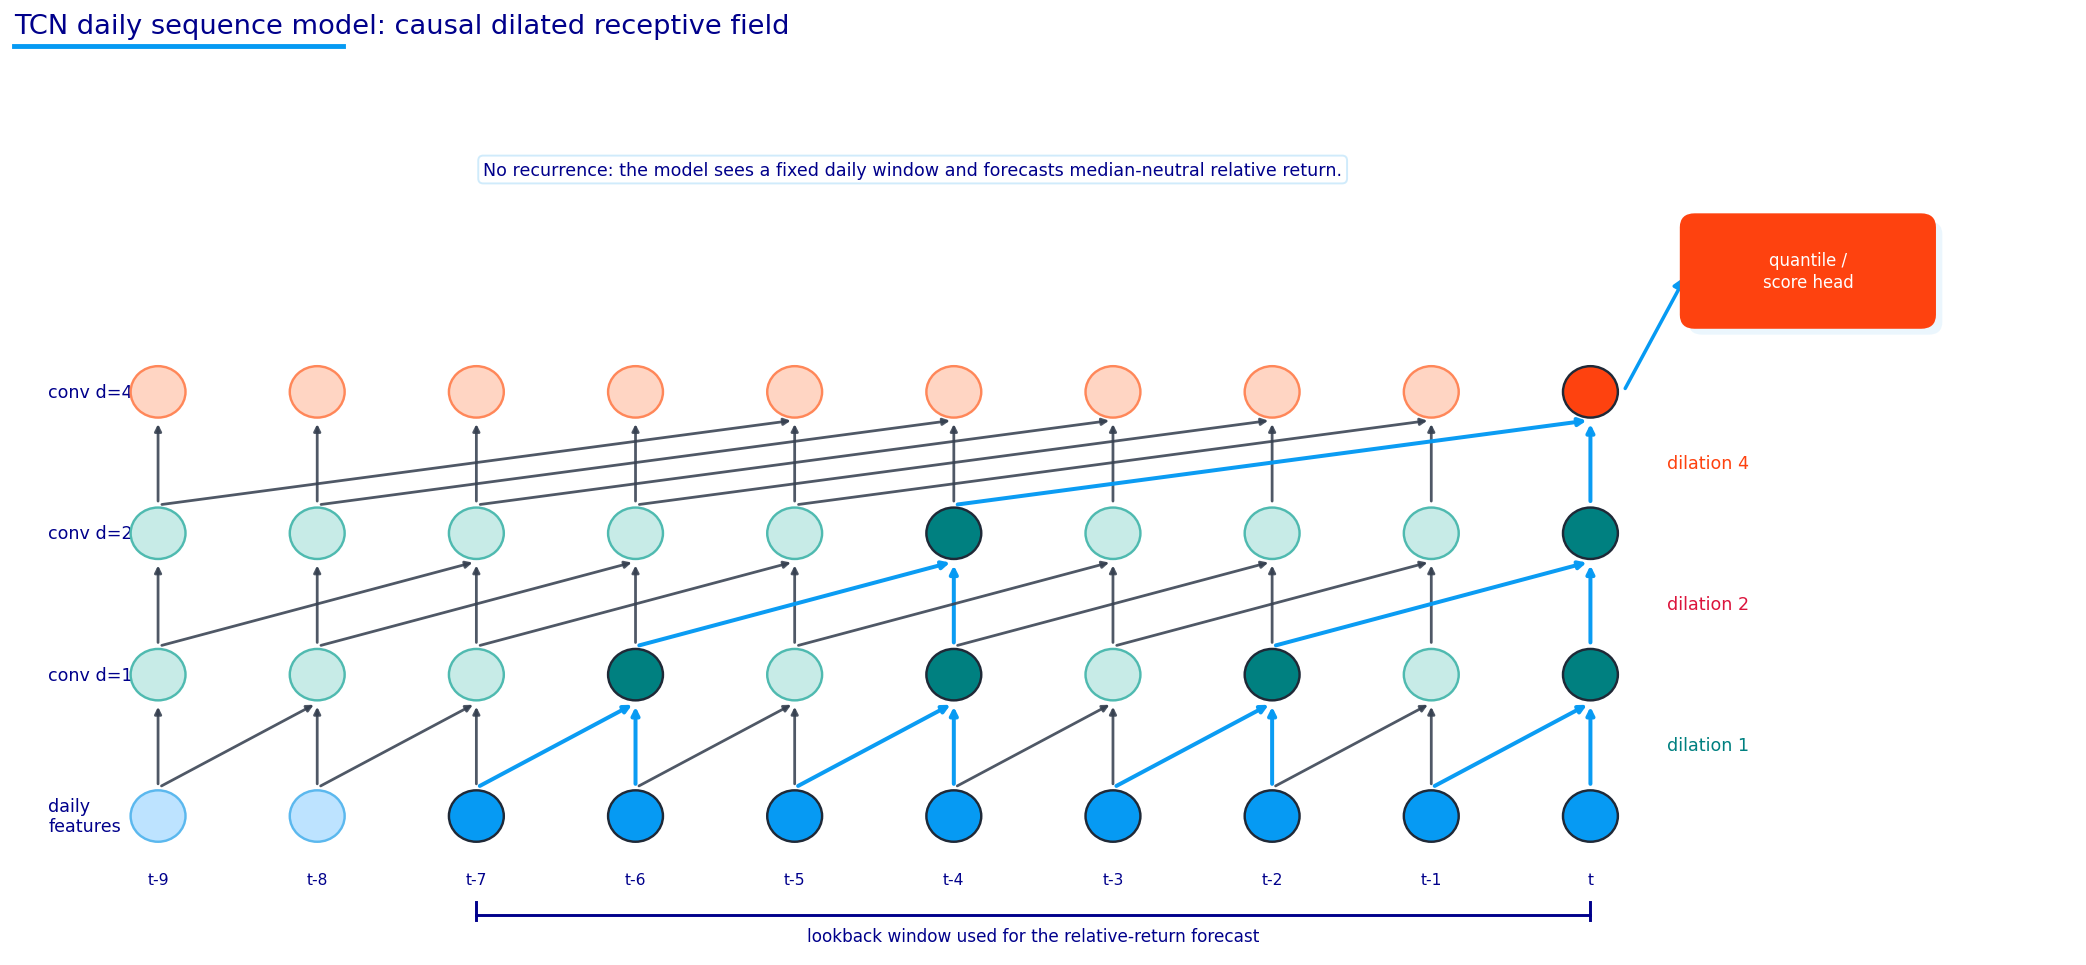

In [7]:
fig, ax = tcn_receptive_field()
plt.show()

In [50]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = int(chomp_size)
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous() if self.chomp_size > 0 else x

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.10):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.SiLU(),
            nn.Dropout(dropout),
        )
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
    def forward(self, x):
        return self.net(x) + (x if self.down is None else self.down(x))

class TCNForecast(nn.Module):
    def __init__(self, n_features, n_assets, embedding_dim=4, channels=(48, 48, 48), output_size=1, dropout=0.16, ordered_quantiles=False):
        super().__init__()
        self.embedding = nn.Embedding(n_assets, embedding_dim)
        layers = []
        in_ch = n_features + embedding_dim
        for i, ch in enumerate(channels):
            layers.append(TemporalBlock(in_ch, ch, kernel_size=3, dilation=2**i, dropout=dropout))
            in_ch = ch
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.LayerNorm(in_ch), nn.Dropout(dropout), nn.Linear(in_ch, output_size))
        self.ordered_quantiles = ordered_quantiles and output_size == 3
    def forward(self, x, asset_id):
        emb = self.embedding(asset_id.long()).unsqueeze(1).expand(-1, x.shape[1], -1)
        out = self.tcn(torch.cat([x.float(), emb], dim=2).transpose(1, 2))[:, :, -1]
        pred = self.head(out)
        return ordered_quantile_head(pred) if self.ordered_quantiles else pred

In [51]:
tcn_point = TCNForecast(len(selected_features_nn), len(assets), channels=(48, 48, 48), dropout=0.16).to(device)
tcn_point, tcn_history = train_model(
    tcn_point,
    X_seq,
    A_seq,
    Y_seq,
    seq_train_mask,
    dates_for_split=seq_dates,
    valid_end=validation_end.strftime("%Y-%m-%d"),
    epochs=180,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-4,
    patience=35,
)

tcn_pred = pd.Series(predict_model(tcn_point, X_seq, A_seq)[:, 0], index=seq_index, name="z_tcn")
display(tcn_pred.describe().round(4))
display(tcn_history.tail().round(4))

count    57012.0000
mean        -0.0200
std          0.1634
min         -0.7247
25%         -0.1425
50%         -0.0142
75%          0.1004
max          0.6201
Name: z_tcn, dtype: float64

,epoch,train_loss,valid_loss,validation_score,valid_rank_ic,valid_bucket_spread,valid_top_k_hit_rate,valid_turnover,early_stop_value
31,32,0.1001,0.5110,-0.0394,-0.0095,-0.1030,0.2824,0.1718,-0.0394
32,33,0.0985,0.5161,-0.0268,-0.0018,-0.0800,0.2851,0.1606,-0.0268
33,34,0.0993,0.5127,-0.0464,-0.0134,-0.1178,0.2845,0.1810,-0.0464
34,35,0.0977,0.5160,-0.0407,-0.0118,-0.1027,0.2797,0.1667,-0.0407
35,36,0.0985,0.5193,-0.0327,-0.0065,-0.0918,0.2899,0.1629,-0.0327


In [52]:
lstm_update_pred = pd.Series(dtype=float, name="z_lstm_update")
display(pd.Series({
    "adaptive_lstm_status": "excluded",
    "reason": "rolling fine-tune diagnostics were worse than the base LSTM, so it is not treated as an improvement",
}).to_frame("value"))

,value
adaptive_lstm_status,excluded
reason,rolling fine-tune diagnostics were worse than ...


In [53]:
neural_eval = data[["date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21"]].copy()
neural_eval = neural_eval.join(mlp_pred).join(lstm_pred).join(tcn_pred)
neural_test = neural_eval[neural_eval["date"] >= test_start]

neural_prediction_cols = ["z_mlp", "z_lstm", "z_tcn"]
neural_metrics = forecast_metrics(neural_test, y_col="y_alpha", prediction_cols=neural_prediction_cols)
neural_rank = rank_metrics(neural_test, date_col="date", asset_col="asset", y_col="y_alpha", prediction_cols=neural_prediction_cols)
display(neural_metrics.round(4))
display(neural_rank.round(4))

,n,MAE,RMSE,Spearman IC,Directional Accuracy,Bias
model,,,,,,
z_mlp,22464,0.6030,0.8673,0.0615,0.5226,-0.0786
z_lstm,22464,0.5755,0.8345,0.0681,0.5271,-0.0275
z_tcn,22464,0.5564,0.8059,0.0655,0.5228,-0.0405


,mean_rank_ic,rank_ic_t,bucket_spread,top_k_hit_rate,bucket_monotonicity,positive_ic_share
model,,,,,,
z_mlp,0.0729,8.6645,0.1222,0.2788,0.1022,0.5775
z_lstm,0.0756,8.8653,0.1003,0.2699,0.0851,0.5913
z_tcn,0.0767,9.0754,0.1395,0.2532,0.1013,0.5929


In [54]:
point_compare = pd.concat({"tabular": tabular_metrics, "neural": neural_metrics}, axis=0)
best_tabular = tabular_rank_metrics["bucket_spread"].idxmax()
selectable_neural_cols = ["z_mlp", "z_lstm", "z_tcn"]
best_neural = neural_rank.loc[selectable_neural_cols, "bucket_spread"].idxmax()
best_sequence = neural_rank.loc[["z_lstm", "z_tcn"], "bucket_spread"].idxmax()

model_selection = pd.Series({
    "best_tabular_point_model": best_tabular,
    "best_neural_point_model": best_neural,
    "best_sequence_model": best_sequence,
    "uncertainty_baseline": "Quantile GradientBoosting",
})
display(point_compare.round(4))
display(model_selection.to_frame("selection"))

n     MAE    RMSE  Spearman IC  Directional Accuracy  \
        model                                                              
tabular z_enet  22464  0.5830  0.8370      -0.0070                0.5057   
        z_rf    22464  0.5435  0.8017       0.0855                0.5311   
        z_et    22464  0.5381  0.7964       0.1186                0.5476   
        z_gb    22464  0.5610  0.8186       0.0399                0.5170   
        z_hgb   22464  0.5860  0.8442       0.0485                0.5182   
        q50_gb  22464  0.5542  0.8159       0.0697                0.5191   
neural  z_mlp   22464  0.6030  0.8673       0.0615                0.5226   
        z_lstm  22464  0.5755  0.8345       0.0681                0.5271   
        z_tcn   22464  0.5564  0.8059       0.0655                0.5228   

                  Bias  
        model           
tabular z_enet -0.0568  
        z_rf   -0.0206  
        z_et   -0.0283  
        z_gb   -0.0145  
        z_hgb  -0.0258  
        q50_gb -0.0362  
neural  z_mlp  -0.0786  
        z_lstm -0.0275  
        z_tcn  -0.0405

,selection
best_tabular_point_model,z_et
best_neural_point_model,z_tcn
best_sequence_model,z_tcn
uncertainty_baseline,Quantile GradientBoosting


## Probabilistic Forecasts And Uncertainty

In [55]:
def selected_sequence_model(output_size=1, ordered_quantiles=False):
    if best_sequence == "z_lstm":
        return LSTMForecast(
            len(selected_features_nn),
            len(assets),
            hidden_size=96,
            num_layers=2,
            output_size=output_size,
            dropout=0.12,
            ordered_quantiles=ordered_quantiles,
        )
    return TCNForecast(
        len(selected_features_nn),
        len(assets),
        channels=(48, 48, 48),
        output_size=output_size,
        dropout=0.16,
        ordered_quantiles=ordered_quantiles,
    )

In [56]:
quantile_model = selected_sequence_model(output_size=3, ordered_quantiles=True).to(device)
quantile_model, quantile_history = train_model(
    quantile_model,
    X_seq,
    A_seq,
    Y_seq,
    seq_train_mask,
    dates_for_split=seq_dates,
    valid_end=validation_end.strftime("%Y-%m-%d"),
    epochs=200,
    batch_size=256,
    lr=1e-3,
    weight_decay=7.5e-5,
    loss_name="pinball",
    quantiles=[0.10, 0.50, 0.90],
    patience=35,
)

q_pred = pd.DataFrame(
    predict_model(quantile_model, X_seq, A_seq),
    index=seq_index,
    columns=["q10_nn", "q50_nn", "q90_nn"],
)
display(q_pred.describe().round(4))
display(quantile_history.tail().round(4))

,q10_nn,q50_nn,q90_nn
count,57012.0000,57012.0000,57012.0000
mean,-1.1155,-0.0351,0.9896
std,0.4407,0.1560,0.3962
min,-2.2675,-0.6188,-0.0660
25%,-1.4884,-0.1575,0.6896
50%,-1.0849,-0.0284,0.9401
75%,-0.7728,0.0830,1.2371
max,-0.1352,0.5592,2.5123


,epoch,train_loss,valid_loss,validation_score,valid_rank_ic,valid_bucket_spread,valid_top_k_hit_rate,valid_turnover,early_stop_value
31,32,0.1041,0.3289,0.0549,0.0473,0.0752,0.2980,0.1104,0.0549
32,33,0.1035,0.3333,0.0382,0.0389,0.0455,0.2851,0.1212,0.0382
33,34,0.1030,0.3303,0.0294,0.0274,0.0360,0.2865,0.1202,0.0294
34,35,0.1036,0.3324,0.0493,0.0443,0.0656,0.2974,0.1445,0.0493
35,36,0.1031,0.3293,0.0399,0.0420,0.0439,0.2899,0.1243,0.0399


In [57]:
class GaussianHead(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
    def forward(self, x, asset_id):
        return self.base(x, asset_id)

nll_model = selected_sequence_model(output_size=2, ordered_quantiles=False).to(device)

In [58]:
nll_model, nll_history = train_model(
    nll_model,
    X_seq,
    A_seq,
    Y_seq,
    seq_train_mask,
    dates_for_split=seq_dates,
    valid_end=validation_end.strftime("%Y-%m-%d"),
    epochs=200,
    batch_size=256,
    lr=1e-3,
    weight_decay=7.5e-5,
    loss_name="nll",
    patience=35,
)

nll_pred = pd.DataFrame(
    predict_model(nll_model, X_seq, A_seq),
    index=seq_index,
    columns=["nll_mean", "nll_log_var"],
)
nll_pred["nll_sigma"] = np.exp(0.5 * nll_pred["nll_log_var"].clip(-8.0, 6.0))
display(nll_pred[["nll_mean", "nll_sigma"]].describe().round(4))
display(nll_history.tail().round(4))

,nll_mean,nll_sigma
count,57012.0000,57012.0000
mean,-0.0209,0.4035
std,0.6862,0.2311
min,-2.0107,0.1397
25%,-0.4008,0.2526
50%,0.0033,0.3465
75%,0.3554,0.4776
max,2.0800,3.0676


,epoch,train_loss,valid_loss,validation_score,valid_rank_ic,valid_bucket_spread,valid_top_k_hit_rate,valid_turnover,early_stop_value
75,76,-0.5840,2.3380,0.1354,0.0841,0.2501,0.3055,0.1247,0.1354
76,77,-0.5784,2.3260,0.1347,0.0815,0.2509,0.3069,0.1204,0.1347
77,78,-0.5838,2.3147,0.1385,0.0842,0.2572,0.3075,0.1120,0.1385
78,79,-0.5904,2.3449,0.1408,0.0860,0.2594,0.3116,0.1141,0.1408
79,80,-0.5863,2.3402,0.1370,0.0841,0.2544,0.3048,0.1137,0.1370


In [59]:
ensemble_preds = []
for ens_seed in [11, 22, 33]:
    torch.manual_seed(ens_seed)
    model = selected_sequence_model(output_size=3, ordered_quantiles=True).to(device)
    model, _ = train_model(
        model,
        X_seq,
        A_seq,
        Y_seq,
        seq_train_mask,
        dates_for_split=seq_dates,
        valid_end=validation_end.strftime("%Y-%m-%d"),
        epochs=200,
        batch_size=256,
        lr=1e-3,
        weight_decay=7.5e-5,
        loss_name="pinball",
        quantiles=[0.10, 0.50, 0.90],
        patience=35,
    )
    pred = pd.DataFrame(
        predict_model(model, X_seq, A_seq),
        index=seq_index,
        columns=[f"q10_seed{ens_seed}", f"q50_seed{ens_seed}", f"q90_seed{ens_seed}"],
    )
    ensemble_preds.append(pred)
ensemble_pred = pd.concat(ensemble_preds, axis=1)
display(ensemble_pred.tail().round(4))

,q10_seed11,q50_seed11,q90_seed11,q10_seed22,q50_seed22,q90_seed22,q10_seed33,q50_seed33,q90_seed33
57707,-1.0259,0.2258,1.4438,-1.1874,0.0309,1.5533,-0.7771,0.1799,1.0095
57719,-1.0317,0.2082,1.4338,-1.1244,0.0763,1.6265,-0.7523,0.1855,1.0338
57731,-1.0438,0.2658,1.4682,-1.1142,0.0624,1.5892,-0.6837,0.2127,1.0159
57743,-1.1361,0.2346,1.4588,-1.0693,0.1250,1.6240,-0.6734,0.1942,1.0124
57755,-1.1128,0.1678,1.3462,-1.1003,0.0668,1.5218,-0.6934,0.1524,0.9932


In [60]:
q10_cols = [c for c in ensemble_pred.columns if c.startswith("q10")]
q50_cols = [c for c in ensemble_pred.columns if c.startswith("q50")]
q90_cols = [c for c in ensemble_pred.columns if c.startswith("q90")]

q_ensemble = pd.DataFrame({
    "q10_ens": ensemble_pred[q10_cols].mean(axis=1),
    "q50_ens": ensemble_pred[q50_cols].mean(axis=1),
    "q90_ens": ensemble_pred[q90_cols].mean(axis=1),
    "d_model": model_disagreement(ensemble_pred[q50_cols]),
})

conformal_base = data.loc[q_ensemble.index, ["date", "asset", "y_alpha"]].join(q_ensemble)
rolling_input = conformal_base[conformal_base["date"] >= validation_start].reset_index(names="row_id")
rolling_adj = apply_rolling_conformal(
    rolling_input,
    date_col="date",
    y_col="y_alpha",
    low_col="q10_ens",
    high_col="q90_ens",
    alpha=0.20,
    lookback_days=504,
    gap_days=horizon,
    min_obs=126,
    output_low="q10_c",
    output_high="q90_c",
)
q_ensemble["q10_c"] = q_ensemble["q10_ens"].astype("float64")
q_ensemble["q90_c"] = q_ensemble["q90_ens"].astype("float64")
q_ensemble.loc[rolling_adj["row_id"].to_numpy(dtype=int), "q10_c"] = rolling_adj["q10_c"].to_numpy(dtype="float64")
q_ensemble.loc[rolling_adj["row_id"].to_numpy(dtype=int), "q90_c"] = rolling_adj["q90_c"].to_numpy(dtype="float64")
conformal_diagnostics = rolling_adj[["date", "offset_low", "offset_high", "calibration_n"]].drop_duplicates("date")
display(conformal_diagnostics.tail().round(4))

,date,offset_low,offset_high,calibration_n
2378,2026-04-17,0.0,0.0282,5700
2379,2026-04-20,0.0,0.0269,5700
2380,2026-04-21,0.0,0.0282,5700
2381,2026-04-22,0.0,0.0299,5700
2382,2026-04-23,0.0,0.0282,5700


In [61]:
probabilistic_eval = data[["date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21"]].join(q_pred).join(q_ensemble).join(nll_pred).merge(
    tab_predictions[["date", "asset", "q10_gb", "q50_gb", "q90_gb"]],
    on=["date", "asset"],
    how="left",
)
probabilistic_eval["nll_low"] = probabilistic_eval["nll_mean"] - 1.28 * probabilistic_eval["nll_sigma"]
probabilistic_eval["nll_high"] = probabilistic_eval["nll_mean"] + 1.28 * probabilistic_eval["nll_sigma"]

prob_metrics = quantile_metrics(
    probabilistic_eval[probabilistic_eval["date"] >= test_start],
    y_col="y_alpha",
    quantile_sets={
        "Quantile GBM": ("q10_gb", "q50_gb", "q90_gb"),
        "Selected NN Quantile": ("q10_nn", "q50_nn", "q90_nn"),
        "Deep Ensemble Conformal": ("q10_c", "q50_ens", "q90_c"),
        "Gaussian NLL": ("nll_low", "nll_mean", "nll_high"),
    },
)
display(prob_metrics.round(4))

,n,coverage_80,avg_width,pinball_q10,pinball_q50,pinball_q90
model,,,,,,
Quantile GBM,22464,0.7005,1.3820,0.1401,0.2771,0.1608
Selected NN Quantile,22464,0.8409,2.0801,0.1407,0.2746,0.1507
Deep Ensemble Conformal,22464,0.8235,1.9154,0.1342,0.2718,0.1473
Gaussian NLL,22464,0.4206,0.9644,0.2084,0.3618,0.2365


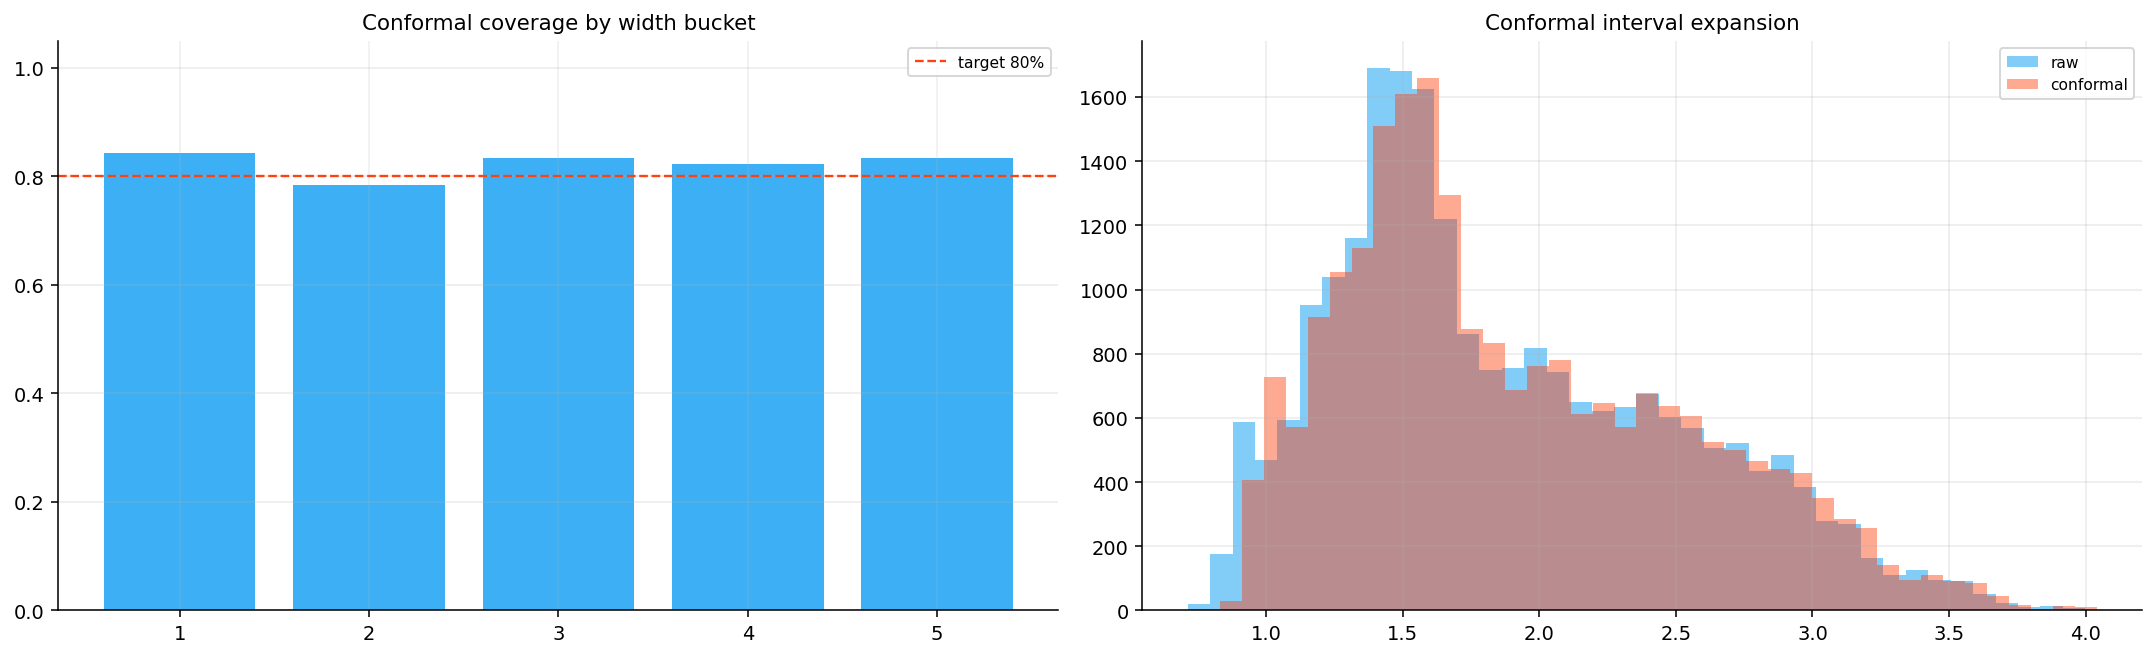

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.8))
coverage_reliability(
    axes[0],
    probabilistic_eval[probabilistic_eval["date"] >= test_start],
    y_col="y_alpha",
    low_col="q10_c",
    high_col="q90_c",
    title="Conformal coverage by width bucket",
)
conformal_shift_chart(
    axes[1],
    probabilistic_eval[probabilistic_eval["date"] >= test_start],
    raw_low="q10_ens",
    raw_high="q90_ens",
    conf_low="q10_c",
    conf_high="q90_c",
    title="Conformal interval expansion",
)
fig.tight_layout()
plt.show()

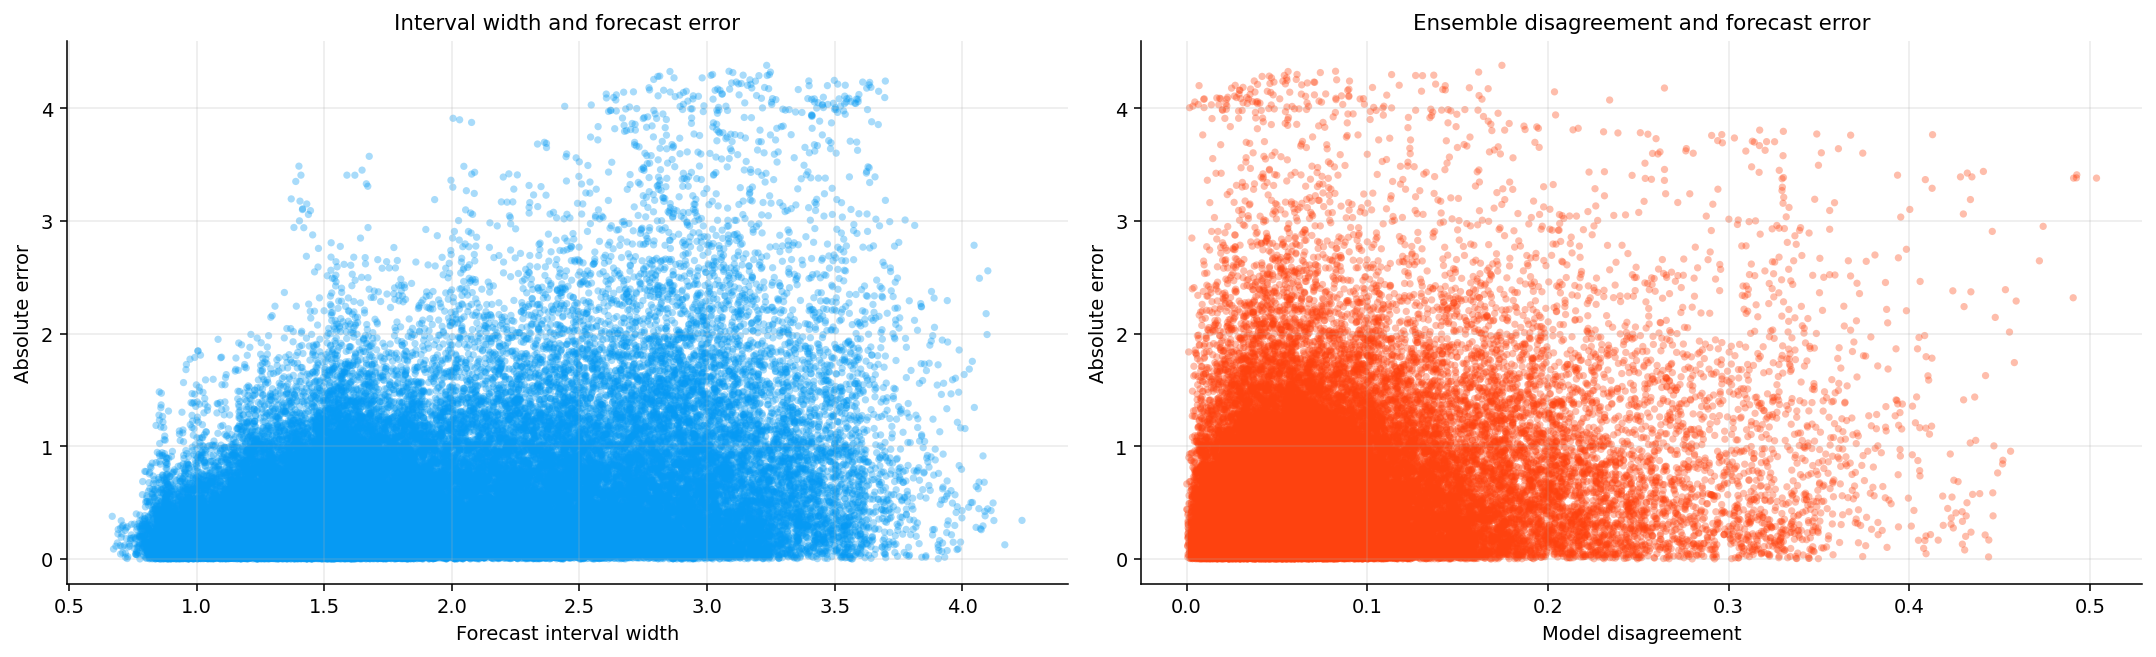

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.8))
uncertainty_error_map(
    axes[0],
    probabilistic_eval.assign(width=probabilistic_eval["q90_c"] - probabilistic_eval["q10_c"]),
    width_col="width",
    y_col="y_alpha",
    pred_col="q50_ens",
    title="Interval width and forecast error",
)
disagreement_error_map(
    axes[1],
    probabilistic_eval,
    disagreement_col="d_model",
    y_col="y_alpha",
    pred_col="q50_ens",
    title="Ensemble disagreement and forecast error",
)
fig.tight_layout()
plt.show()

## Kelly Allocation

In [64]:
forecast = data[["date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21", "vol_63", "vol_126", "drawdown_126", "sharpe_126"]].copy()
forecast = forecast.merge(tab_predictions, on=["date", "asset"], how="left")
forecast = forecast.join(mlp_pred).join(lstm_pred).join(tcn_pred)
forecast = forecast.join(q_ensemble).join(nll_pred)

base_signal_cols = [
    "z_enet", "z_rf", "z_et", "z_gb", "z_hgb", "q50_gb",
    "z_mlp", "z_lstm", "z_tcn", "q50_ens", "nll_mean",
]
for col in base_signal_cols:
    if col in forecast.columns:
        forecast[f"{col}_rank"] = forecast.groupby("date")[col].rank(pct=True) - 0.5

selection_cols = [c for c in base_signal_cols if c in forecast.columns]
selection_cols += [f"{c}_rank" for c in base_signal_cols if f"{c}_rank" in forecast.columns]
selection_eval = forecast[forecast["date"].between(validation_start, validation_end)].dropna(subset=["y_alpha"])
selection_rank = rank_metrics(
    selection_eval,
    date_col="date",
    asset_col="asset",
    y_col="y_alpha",
    prediction_cols=selection_cols,
)
selection_rank["selection_score"] = (
    0.50 * selection_rank["mean_rank_ic"].fillna(0.0)
    + 0.35 * selection_rank["bucket_spread"].fillna(0.0)
    + 0.15 * (selection_rank["top_k_hit_rate"].fillna(0.25) - 0.25)
)
rank_choice = selection_rank["selection_score"].dropna().sort_values(ascending=False)
selected_signal_cols = rank_choice.head(3).index.tolist() if len(rank_choice) else ["q50_gb"]
for col in selected_signal_cols:
    forecast[f"_rank_for_blend_{col}"] = forecast.groupby("date")[col].rank(pct=True) - 0.5
forecast["forecast_blend"] = forecast[[f"_rank_for_blend_{col}" for col in selected_signal_cols]].mean(axis=1)
forecast["forecast_blend"] = forecast["forecast_blend"].fillna(0.0)
final_signal_col = selected_signal_cols[0]

forecast["z_final"] = forecast[final_signal_col]
forecast["mu_hat"] = forecast["forecast_blend"] * forecast["sigma_21"]
forecast["width"] = (forecast["q90_c"] - forecast["q10_c"]) * forecast["sigma_21"]
forecast["width_nll"] = 2.56 * forecast["nll_sigma"] * forecast["sigma_21"]
forecast["nll_mean_return"] = forecast["nll_mean"] * forecast["sigma_21"]
forecast["c_nll"] = (
    forecast["nll_mean_return"].abs()
    / (forecast["nll_mean_return"].abs() + forecast["width_nll"].abs())
).replace([np.inf, -np.inf], np.nan).fillna(0.0)
forecast["c_width"] = forecast_confidence(forecast["mu_hat"], forecast["width"]).values
forecast["c_model"] = disagreement_confidence(forecast["d_model"]).values
forecast["c_total"] = soft_confidence_blend(forecast["c_width"], forecast["c_model"], forecast["c_nll"], index=forecast.index).values
forecast["mu_adj"] = forecast["mu_hat"] * forecast["c_total"]
forecast = forecast.dropna(subset=["sigma_21"])
display(pd.Series({"validation_winner": final_signal_col, "blend_members": ", ".join(selected_signal_cols)}).to_frame("selection"))
display(selection_rank.sort_values("selection_score", ascending=False).round(4))
display(forecast.tail().round(4))

,selection
validation_winner,z_mlp_rank
blend_members,"z_mlp_rank, z_mlp, z_et"


,mean_rank_ic,rank_ic_t,bucket_spread,top_k_hit_rate,bucket_monotonicity,positive_ic_share,selection_score
model,,,,,,,
z_mlp_rank,0.1559,9.3514,0.3443,0.3354,0.1927,0.6660,0.2113
z_mlp,0.1559,9.3514,0.3443,0.3354,0.1927,0.6660,0.2113
z_et,0.1459,6.6100,0.3254,0.3517,0.1690,0.6415,0.2021
z_et_rank,0.1459,6.6100,0.3254,0.3517,0.1690,0.6415,0.2021
z_enet_rank,0.1611,9.1745,0.2862,0.3130,0.2014,0.6904,0.1902
z_enet,0.1611,9.1745,0.2862,0.3130,0.2014,0.6904,0.1902
z_rf_rank,0.1215,5.7549,0.2671,0.3184,0.1493,0.6293,0.1645
z_rf,0.1215,5.7549,0.2671,0.3184,0.1493,0.6293,0.1645
nll_mean_rank,0.1005,5.9642,0.2869,0.3048,0.1244,0.6029,0.1589


,date,asset,y_alpha,z_21,r_ex_21,sigma_21,vol_63,vol_126,drawdown_126,sharpe_126,...,z_final,mu_hat,width,width_nll,nll_mean_return,c_nll,c_width,c_model,c_total,mu_adj
57751,2026-04-23,LQD,-0.9653,-0.7812,-0.0138,0.0177,0.0611,0.0541,-0.0123,-0.8691,...,0.0833,-0.0005,0.0378,0.0214,0.0076,0.2608,0.0128,0.4614,0.5985,-0.0003
57752,2026-04-23,QQQ,1.3792,1.5632,0.0873,0.0558,0.1937,0.1793,-0.0056,0.6209,...,0.3333,0.0155,0.0575,0.0328,0.0076,0.1886,0.2124,0.7380,0.6827,0.0106
57753,2026-04-23,SPY,0.7900,0.9741,0.0420,0.0431,0.1497,0.1340,-0.0039,0.6524,...,0.2500,0.0084,0.0556,0.0226,-0.0022,0.0884,0.1310,0.7618,0.6559,0.0055
57754,2026-04-23,TLT,-1.2449,-1.0608,-0.0306,0.0288,0.0998,0.0905,-0.0400,-1.1104,...,0.5000,0.0064,0.0697,0.0730,0.0216,0.2283,0.0842,0.4053,0.6047,0.0039
57755,2026-04-23,VNQ,-0.0150,0.1691,0.0071,0.0423,0.1462,0.1354,-0.0159,0.5935,...,0.4167,0.0106,0.0966,0.0452,0.0095,0.1742,0.0987,0.5875,0.6302,0.0067


In [65]:
point_cols = [c for c in selection_cols + ["forecast_blend", "mu_adj"] if c in forecast.columns]
forecast_metric_table = forecast_metrics(
    forecast[forecast["date"] >= test_start],
    y_col="y_alpha",
    prediction_cols=point_cols,
)
display(forecast_metric_table.round(4))

,n,MAE,RMSE,Spearman IC,Directional Accuracy,Bias
model,,,,,,
z_enet,22464,0.5830,0.8370,-0.0070,0.5057,-0.0568
z_rf,22464,0.5435,0.8017,0.0855,0.5311,-0.0206
z_et,22464,0.5381,0.7964,0.1186,0.5476,-0.0283
z_gb,22464,0.5610,0.8186,0.0399,0.5170,-0.0145
z_hgb,22464,0.5860,0.8442,0.0485,0.5182,-0.0258
q50_gb,22464,0.5542,0.8159,0.0697,0.5191,-0.0362
z_mlp,22464,0.6030,0.8673,0.0615,0.5226,-0.0786
z_lstm,22464,0.5755,0.8345,0.0681,0.5271,-0.0275
z_tcn,22464,0.5564,0.8059,0.0655,0.5228,-0.0405


In [66]:
forecast_rank_table = rank_metrics(
    forecast[forecast["date"] >= test_start],
    date_col="date",
    asset_col="asset",
    y_col="y_alpha",
    prediction_cols=point_cols,
)
final_bucket_table = forecast_buckets(
    forecast[forecast["date"] >= test_start],
    date_col="date",
    y_col="r_ex_21",
    score_col="forecast_blend",
    n_buckets=5,
)
display(forecast_rank_table.round(4))
display(final_bucket_table.round(4))

,mean_rank_ic,rank_ic_t,bucket_spread,top_k_hit_rate,bucket_monotonicity,positive_ic_share
model,,,,,,
z_enet,0.0267,2.8324,-0.0398,0.2621,0.0329,0.5326
z_rf,0.0851,9.1637,0.1220,0.2867,0.0942,0.5833
z_et,0.1382,14.9390,0.1847,0.2959,0.1644,0.6410
z_gb,0.0492,5.5261,0.0533,0.2867,0.0419,0.5459
z_hgb,0.0541,5.5404,0.0841,0.2890,0.0622,0.5550
q50_gb,0.0558,5.8450,0.0468,0.2764,0.0577,0.5470
z_mlp,0.0729,8.6645,0.1222,0.2788,0.1022,0.5775
z_lstm,0.0756,8.8653,0.1003,0.2699,0.0851,0.5913
z_tcn,0.0767,9.0754,0.1395,0.2532,0.1013,0.5929


,mean,median,count
bucket,,,
1,-0.0001,0.0017,5616
2,0.0026,0.0042,3744
3,0.0037,0.0054,3744
4,0.0038,0.0053,3744
5,0.0094,0.0109,5616


In [67]:
returns_main = r_d[assets + [cash_ticker]].copy()

KELLY_FRACTION = 0.60
KELLY_SMOOTH = 0.00
LAMBDA_ALPHA_GRID = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50]


def _forecast_rows_by_date(frame, rebalance_dates_for_fit):
    needed = set(pd.DatetimeIndex(rebalance_dates_for_fit))
    return {
        pd.Timestamp(dt): group.drop_duplicates("asset").set_index("asset").reindex(assets)
        for dt, group in frame[frame["date"].isin(needed)].groupby("date", sort=False)
    }


def _active_alpha_horizon(row, col, *, is_z):
    alpha = pd.to_numeric(row[col], errors="coerce").reindex(assets).astype(float)
    if is_z:
        alpha = alpha * pd.to_numeric(row["sigma_21"], errors="coerce").reindex(assets).astype(float)
    alpha = alpha.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return alpha - float(alpha.median())


def _continuous_kelly_vector(mu_horizon, cov_horizon, *, kelly_fraction=0.60, max_weight=0.35):
    mu = pd.Series(mu_horizon, dtype=float).reindex(assets).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if mu.clip(lower=0.0).sum() <= 1e-12:
        return pd.Series(0.0, index=assets, dtype=float)
    cov = pd.DataFrame(cov_horizon, index=assets, columns=assets).fillna(0.0)
    S = covariance.make_psd(cov.to_numpy(dtype=float), eps=1e-6)
    try:
        raw = np.linalg.solve(S + 1e-6 * np.eye(len(assets)), mu.to_numpy(dtype=float))
    except np.linalg.LinAlgError:
        raw = np.linalg.lstsq(S + 1e-6 * np.eye(len(assets)), mu.to_numpy(dtype=float), rcond=None)[0]
    w = pd.Series(float(kelly_fraction) * raw, index=assets, dtype=float).clip(lower=0.0, upper=float(max_weight))
    if float(w.sum()) > 1.0:
        w = cap_weights(w, max_weight=max_weight, normalize=True)
    return w


def _row_confidence(row, alpha_horizon):
    idx = alpha_horizon.index
    if "c_total" in row.columns:
        return pd.to_numeric(row["c_total"], errors="coerce").reindex(idx).fillna(0.75).clip(0.50, 1.0)
    if "c_width" in row.columns:
        c_width = pd.to_numeric(row["c_width"], errors="coerce").reindex(idx)
    elif "width" in row.columns:
        width = pd.to_numeric(row["width"], errors="coerce").reindex(idx).abs()
        c_width = alpha_horizon.abs().div(alpha_horizon.abs() + width.replace(0.0, np.nan))
    else:
        c_width = pd.Series(1.0, index=idx)
    c_model = pd.to_numeric(row["c_model"], errors="coerce").reindex(idx) if "c_model" in row.columns else None
    c_nll = pd.to_numeric(row["c_nll"], errors="coerce").reindex(idx) if "c_nll" in row.columns else None
    return soft_confidence_blend(c_width, c_model, c_nll, index=idx)


def forecast_kelly_weights(
    mu_col,
    *,
    mu_is_z=False,
    kelly_fraction=KELLY_FRACTION,
    max_weight=0.35,
    smooth=KELLY_SMOOTH,
    confidence_cols=None,
    rebalance_dates_for_fit=None,
):
    fit_dates = pd.DatetimeIndex(rebalance_dates_for_fit if rebalance_dates_for_fit is not None else wf_dates)
    rows_by_date = _forecast_rows_by_date(forecast, fit_dates)
    rows = []
    for dt in fit_dates:
        row = rows_by_date.get(pd.Timestamp(dt))
        if row is None or mu_col not in row.columns:
            continue
        window = returns_main.loc[:dt, assets].tail(252).replace([np.inf, -np.inf], np.nan).dropna(how="any")
        if len(window) < 126:
            continue
        alpha_h = _active_alpha_horizon(row, mu_col, is_z=mu_is_z)
        cov_h = covariance.ledoit_wolf_covariance(window, annualization=1.0, return_df=True).reindex(index=assets, columns=assets).fillna(0.0) * horizon
        risky = _continuous_kelly_vector(alpha_h, cov_h, kelly_fraction=kelly_fraction, max_weight=max_weight)
        if confidence_cols:
            risky = risky * float(_row_confidence(row, alpha_h).mean())
        full = risky.reindex(assets).fillna(0.0).rename(pd.Timestamp(dt))
        full[cash_ticker] = max(0.0, 1.0 - float(full.sum()))
        rows.append(full)
    W = pd.DataFrame(rows).reindex(columns=assets + [cash_ticker]).fillna(0.0)
    if W.empty:
        return W
    risky_gross = W[assets].sum(axis=1).clip(0.0, 1.0)
    risky = W[assets]
    if smooth and float(smooth) > 0:
        risky = smooth_weights(risky, strength=float(smooth))
        risky = cap_weights(risky, max_weight=max_weight, normalize=True)
    risky = risky.mul(risky_gross.reindex(risky.index).fillna(1.0), axis=0)
    risky[cash_ticker] = 1.0 - risky[assets].sum(axis=1)
    return risky.reindex(columns=assets + [cash_ticker]).fillna(0.0).sort_index()


def forecast_gated_maxsharpe_weights(mu_col, *, mu_is_z=True, lambda_alpha=1.50, rebalance_dates_for_fit=None, prior_model="momentum"):
    fit_dates = pd.DatetimeIndex(rebalance_dates_for_fit if rebalance_dates_for_fit is not None else wf_dates)
    rows_by_date = _forecast_rows_by_date(forecast, fit_dates)
    rows = []
    prev = None
    for dt in fit_dates:
        row = rows_by_date.get(pd.Timestamp(dt))
        if row is None or mu_col not in row.columns:
            continue
        cov_window = returns_main.loc[:dt, assets].tail(756).replace([np.inf, -np.inf], np.nan).dropna(how="any")
        mu_window = returns_main.loc[:dt, assets].tail(252).replace([np.inf, -np.inf], np.nan).dropna(how="any")
        if len(cov_window) < 252 or len(mu_window) < 126:
            continue
        cov_ann = covariance.ledoit_wolf_covariance(cov_window, annualization=annualization, return_df=True).reindex(index=assets, columns=assets).fillna(0.0)
        prior_name = str(prior_model).lower().replace("-", "_").replace(" ", "_")
        if prior_name in {"bayes_stein", "bayesstein", "shrinkage"}:
            mu_prior = expected_returns.bayes_stein_mu(mu_window, cov_ann=cov_ann, rf_daily=rf_daily, annualization=annualization, return_series=True)
        elif prior_name in {"bayes_stein_momentum", "bayesstein_momentum"}:
            mu_prior = expected_returns.bayes_stein_momentum_mu(mu_window, cov_ann=cov_ann, rf_daily=rf_daily, annualization=annualization, return_series=True)
        else:
            mu_prior = expected_returns.momentum_mu(mu_window, cov_ann=cov_ann, annualization=annualization, return_series=True)
        mu_prior = pd.Series(mu_prior, index=assets, dtype=float).reindex(assets).fillna(0.0)
        alpha_h = _active_alpha_horizon(row, mu_col, is_z=mu_is_z)
        confidence = _row_confidence(row, alpha_h).replace([np.inf, -np.inf], np.nan).fillna(0.75).clip(0.50, 1.0)
        alpha_ann = alpha_h * annualization / horizon
        alpha_abs = float(alpha_ann.abs().median())
        prior_abs = float(mu_prior.abs().median())
        if np.isfinite(alpha_abs) and alpha_abs > 1e-12 and np.isfinite(prior_abs) and prior_abs > 1e-12:
            alpha_ann = alpha_ann * (prior_abs / alpha_abs)
        mu_final = mu_prior + float(lambda_alpha) * confidence * alpha_ann
        w_arr = optimizers.max_sharpe_slsqp(
            mu_excess_ann=mu_final.reindex(assets).to_numpy(dtype=float),
            cov_ann=cov_ann.reindex(index=assets, columns=assets).to_numpy(dtype=float),
            w_prev=prev,
            w_min=0.0,
            w_max=0.35,
            long_only=True,
            turnover_penalty_bps=10.0,
            raise_on_fail=False,
        )
        if w_arr is None:
            risky = pd.Series(1.0 / len(assets), index=assets, dtype=float)
        else:
            risky = cap_weights(pd.Series(w_arr, index=assets, dtype=float).clip(lower=0.0), max_weight=0.35, normalize=True)
        prev = risky.reindex(assets).fillna(0.0).to_numpy(dtype=float)
        full = risky.reindex(assets).fillna(0.0).rename(pd.Timestamp(dt))
        full[cash_ticker] = max(0.0, 1.0 - float(full.sum()))
        rows.append(full)
    return pd.DataFrame(rows).reindex(columns=assets + [cash_ticker]).fillna(0.0).sort_index()


def select_lambda_alpha(mu_col, *, mu_is_z=True, prior_model="momentum"):
    validation_weight_dates = pd.DatetimeIndex([d for d in wf_dates if validation_start <= d <= validation_end and d in set(forecast["date"])])
    if len(validation_weight_dates) < 6:
        return 1.50, pd.DataFrame()
    rows = []
    valid_returns = returns_main.loc[:validation_end + pd.offsets.BDay(1)]
    for lam in LAMBDA_ALPHA_GRID:
        W = forecast_gated_maxsharpe_weights(mu_col, mu_is_z=mu_is_z, lambda_alpha=lam, rebalance_dates_for_fit=validation_weight_dates, prior_model=prior_model)
        if W.empty:
            continue
        bt = run_many_weights_backtests({f"lambda={lam:.2f}": W}, returns=valid_returns, cost_bps=cost_bps, rf_daily=rf_daily)
        summary = build_strategy_summary(bt, rf_daily=rf_daily, annualization=annualization)
        rows.append({"lambda_alpha": lam, "Sharpe": float(summary.iloc[0]["Sharpe"]) if len(summary) else np.nan})
    table = pd.DataFrame(rows)
    if table.empty or table["Sharpe"].dropna().empty:
        return 1.50, table
    return float(table.sort_values("Sharpe", ascending=False).iloc[0]["lambda_alpha"]), table

In [68]:
weight_dates = pd.DatetimeIndex([d for d in wf_dates if d >= test_start and d in set(forecast["date"])])

signal_specs = {
    "ElasticNet": {"col": "z_enet", "mu_is_z": True},
    "RandomForest": {"col": "z_rf", "mu_is_z": True},
    "ExtraTrees": {"col": "z_et", "mu_is_z": True},
    "GradientBoosting": {"col": "z_gb", "mu_is_z": True},
    "HistGradientBoosting": {"col": "z_hgb", "mu_is_z": True},
    "QuantileGBM": {"col": "q50_gb", "mu_is_z": True},
    "MLP": {"col": "z_mlp", "mu_is_z": True},
    "LSTM": {"col": "z_lstm", "mu_is_z": True},
    "TCN": {"col": "z_tcn", "mu_is_z": True},
    "ElasticNetRank": {"col": "z_enet_rank", "mu_is_z": True},
    "RandomForestRank": {"col": "z_rf_rank", "mu_is_z": True},
    "ExtraTreesRank": {"col": "z_et_rank", "mu_is_z": True},
    "LSTMRank": {"col": "z_lstm_rank", "mu_is_z": True},
    "TCNRank": {"col": "z_tcn_rank", "mu_is_z": True},
    "EnsembleRank": {"col": "q50_ens_rank", "mu_is_z": True},
    "GaussianNLL": {"col": "nll_mean", "mu_is_z": True},
    "ValidationBlend": {"col": "forecast_blend", "mu_is_z": True},
    "UncertaintyAdjusted": {"col": "mu_adj", "mu_is_z": False},
}
signal_specs = {name: spec for name, spec in signal_specs.items() if spec["col"] in forecast.columns and forecast[spec["col"]].notna().sum() > 100}
returns_main = r_d[assets + [cash_ticker]].copy()

allocator_specs = ["Kelly", "Forecast-Gated MaxSharpe"]
matrix_weights = {}
lambda_alpha_rows = []
for signal_name, spec in signal_specs.items():
    col = spec["col"]
    matrix_weights[(signal_name, "Kelly")] = forecast_kelly_weights(
        col,
        mu_is_z=spec["mu_is_z"],
        kelly_fraction=KELLY_FRACTION,
        max_weight=0.35,
        smooth=KELLY_SMOOTH,
        confidence_cols=["c_total"] if col == "mu_adj" else None,
        rebalance_dates_for_fit=weight_dates,
    )
    lam, _ = select_lambda_alpha(col, mu_is_z=spec["mu_is_z"], prior_model="momentum")
    lambda_alpha_rows.append({"signal": signal_name, "selected_lambda_alpha": lam})
    matrix_weights[(signal_name, "Forecast-Gated MaxSharpe")] = forecast_gated_maxsharpe_weights(
        col,
        mu_is_z=spec["mu_is_z"],
        lambda_alpha=lam,
        rebalance_dates_for_fit=weight_dates,
        prior_model="momentum",
    )

matrix_backtests = run_many_weights_backtests(
    {f"{sig} | {alloc}": weights for (sig, alloc), weights in matrix_weights.items()},
    returns=returns_main,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
)
matrix_summary = build_strategy_summary(matrix_backtests, rf_daily=rf_daily, annualization=annualization)
sharpe_matrix = pd.DataFrame(index=signal_specs.keys(), columns=allocator_specs, dtype=float)
for signal_name in signal_specs:
    for allocator in allocator_specs:
        key = f"{signal_name} | {allocator}"
        if key in matrix_summary.index:
            sharpe_matrix.loc[signal_name, allocator] = matrix_summary.loc[key, "Sharpe"]

best_signal_by_allocator = sharpe_matrix.idxmax(axis=0).dropna()
selected_model_weights = {
    f"{allocator}: {signal_name}": matrix_weights[(signal_name, allocator)]
    for allocator, signal_name in best_signal_by_allocator.items()
}
lambda_alpha_selection = pd.DataFrame(lambda_alpha_rows).set_index("signal") if lambda_alpha_rows else pd.DataFrame()

weights_by_strategy = {
    "Equal Weight": ew_weights.reindex(weight_dates).ffill(),
    "MaxSharpe (LedoitWolf, Momentum)": maxsharpe_weights.reindex(weight_dates).ffill(),
    "Wasserstein DRMV": w_wasserstein.reindex(weight_dates).ffill(),
    "ML Regime-Aware LogisticRegression": w_regime.reindex(weight_dates).ffill(),
    **selected_model_weights,
}

backtests = run_many_weights_backtests(
    weights_by_strategy,
    returns=returns_main,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
)
strategy_returns = pd.DataFrame({name: result.net_returns for name, result in backtests.items()}).dropna(how="all")
nav = pd.DataFrame({name: result.net_values for name, result in backtests.items()}).dropna(how="all")
if selected_model_weights:
    w_final = next(iter(selected_model_weights.values()))
else:
    w_final = ew_weights.reindex(weight_dates).ffill()
final_signal_col = signal_specs[best_signal_by_allocator.iloc[0]]["col"] if len(best_signal_by_allocator) else "forecast_blend"

display(pd.Series({
    "kelly_fraction": KELLY_FRACTION,
    "kelly_smooth": KELLY_SMOOTH,
}).to_frame("fixed_allocator_parameter"))
display(best_signal_by_allocator.to_frame("selected_signal"))
display(lambda_alpha_selection.round(4))
display(pd.DataFrame({"selected_strategy": list(selected_model_weights.keys())}))

,fixed_allocator_parameter
kelly_fraction,0.6
kelly_smooth,0.0


,selected_signal
Kelly,EnsembleRank
Forecast-Gated MaxSharpe,TCNRank


,selected_lambda_alpha
signal,
ElasticNet,1.5
RandomForest,1.5
ExtraTrees,1.5
GradientBoosting,0.5
HistGradientBoosting,1.5
QuantileGBM,1.5
MLP,1.0
LSTM,1.5
TCN,1.5


,selected_strategy
0,Kelly: EnsembleRank
1,Forecast-Gated MaxSharpe: TCNRank


In [69]:
strategy_summary = build_strategy_summary(backtests, rf_daily=rf_daily, annualization=annualization)
strategy_summary = strategy_summary.sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
display(strategy_summary.round(4))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Forecast-Gated MaxSharpe: TCNRank,Forecast-Gated MaxSharpe: TCNRank,-,-,0.1574,0.1228,0.9364,-0.1677,0.9385,1.1940,0.3857,33.5538,0.0200,3.3140,0
Kelly: EnsembleRank,Kelly: EnsembleRank,-,-,0.1359,0.1268,0.7631,-0.1997,0.6805,0.9512,0.3490,30.3588,0.0192,5.3404,0
"MaxSharpe (LedoitWolf, Momentum)",MaxSharpe,Momentum,LedoitWolf,0.1334,0.1303,0.7288,-0.1784,0.7479,0.9248,0.2504,21.7831,0.0130,3.3894,0
ML Regime-Aware LogisticRegression,ML Regime-Aware LogisticRegression,-,-,0.1076,0.1002,0.6835,-0.1982,0.5426,0.8500,0.2169,18.8697,0.0129,7.4597,0
Wasserstein DRMV,Wasserstein DRMV,-,-,0.1196,0.1194,0.6820,-0.1646,0.7269,0.8679,0.2882,25.0719,0.0154,3.5280,0
Equal Weight,Equal Weight,-,-,0.0943,0.1170,0.4972,-0.2218,0.4254,0.6005,0.0178,1.5486,0.0010,12.0000,0


In [70]:
signal_comparison = matrix_summary.copy()
signal_comparison[["signal", "allocator"]] = signal_comparison.index.to_series().str.split(" | ", regex=False, expand=True).values
signal_comparison = signal_comparison.sort_values(["signal", "Sharpe"], ascending=[True, False])
best_allocator_by_signal = signal_comparison.groupby("signal").head(1).set_index("signal")[["allocator", "Sharpe", "CAGR", "Vol", "Max Drawdown", "Turnover"]]
display(best_allocator_by_signal.sort_values("Sharpe", ascending=False).round(4))

allocator_comparison = signal_comparison.groupby("allocator")[["Sharpe", "CAGR", "Max Drawdown", "Turnover"]].agg(["mean", "max"])
display(allocator_comparison.round(4))

display(sharpe_matrix.sort_values(sharpe_matrix.columns.tolist(), ascending=False).round(4))

,allocator,Sharpe,CAGR,Vol,Max Drawdown,Turnover
signal,,,,,,
TCNRank,Forecast-Gated MaxSharpe,0.9364,0.1574,0.1228,-0.1677,0.3857
TCN,Forecast-Gated MaxSharpe,0.8827,0.1482,0.1209,-0.1997,0.4063
EnsembleRank,Forecast-Gated MaxSharpe,0.8430,0.1505,0.1304,-0.2073,0.3436
ValidationBlend,Forecast-Gated MaxSharpe,0.7793,0.1437,0.1341,-0.2029,0.3978
ExtraTreesRank,Forecast-Gated MaxSharpe,0.7707,0.1475,0.1412,-0.1893,0.3126
ExtraTrees,Forecast-Gated MaxSharpe,0.7575,0.1432,0.1386,-0.1939,0.2959
MLP,Forecast-Gated MaxSharpe,0.7508,0.1395,0.1344,-0.2047,0.4439
UncertaintyAdjusted,Forecast-Gated MaxSharpe,0.7505,0.1369,0.1306,-0.1772,0.3786
LSTMRank,Forecast-Gated MaxSharpe,0.7049,0.1266,0.1252,-0.1966,0.3832


Sharpe            CAGR         Max Drawdown          \
                            mean     max    mean     max         mean     max   
allocator                                                                       
Forecast-Gated MaxSharpe  0.6948  0.9364  0.1312  0.1574      -0.2100 -0.1677   
Kelly                     0.5331  0.7631  0.1021  0.1359      -0.2272 -0.1060   

                         Turnover          
                             mean     max  
allocator                                  
Forecast-Gated MaxSharpe   0.3849  0.4993  
Kelly                      0.3930  0.4971

,Kelly,Forecast-Gated MaxSharpe
EnsembleRank,0.7631,0.8430
ValidationBlend,0.6769,0.7793
RandomForest,0.6014,0.5324
ExtraTreesRank,0.5963,0.7707
HistGradientBoosting,0.5892,0.6199
ExtraTrees,0.5589,0.7575
LSTM,0.5465,0.6116
RandomForestRank,0.5286,0.5996
LSTMRank,0.5229,0.7049
TCN,0.5164,0.8827


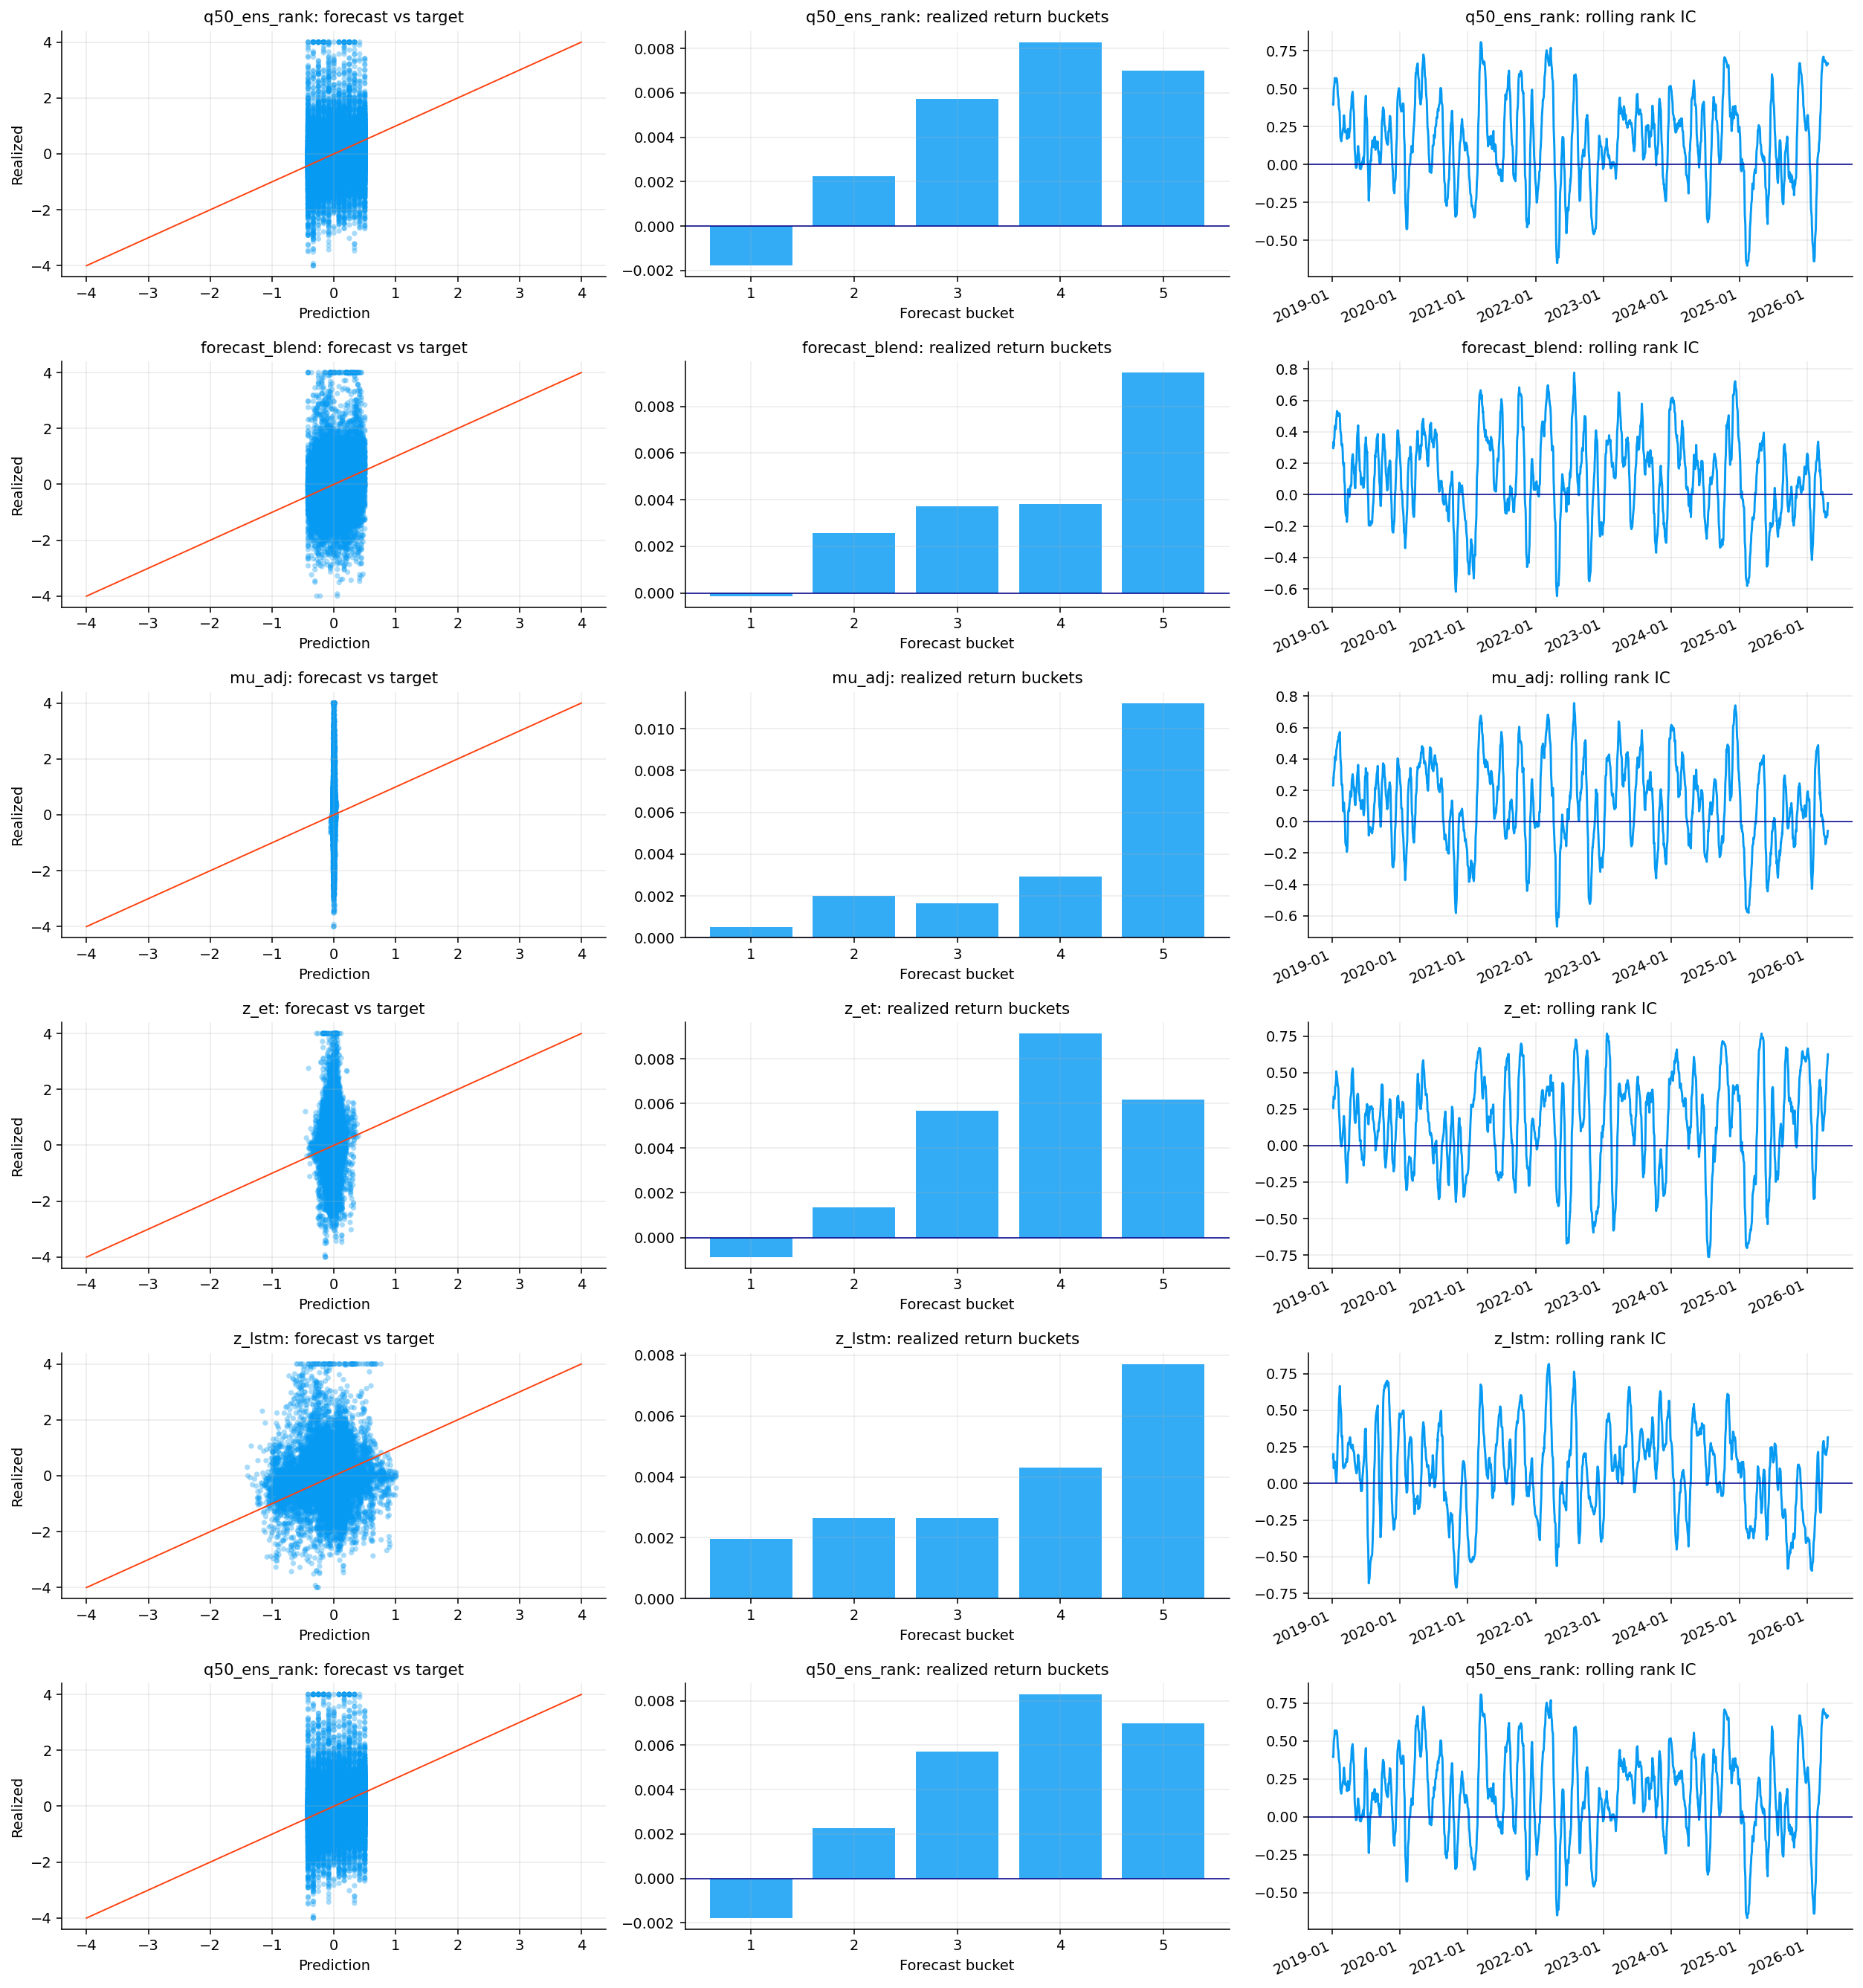

In [71]:

plot_cols = [c for c in [final_signal_col, "forecast_blend", "mu_adj", "z_et", "z_lstm", "q50_ens_rank"] if c in forecast.columns]
fig, axes = plt.subplots(len(plot_cols), 3, figsize=(18, max(4, 3.2 * len(plot_cols))))
axes = np.atleast_2d(axes)
for row_i, col in enumerate(plot_cols):
    model_frame = forecast[forecast["date"] >= test_start].dropna(subset=[col, "y_alpha", "r_ex_21"])
    forecast_scatter(axes[row_i, 0], model_frame, y_col="y_alpha", pred_col=col, title=f"{col}: forecast vs target")
    bucket = forecast_buckets(model_frame, date_col="date", y_col="r_ex_21", score_col=col, n_buckets=5)
    forecast_buckets_chart(axes[row_i, 1], bucket, title=f"{col}: realized return buckets")
    rolling_ic_chart(axes[row_i, 2], model_frame, date_col="date", asset_col="asset", y_col="y_alpha", pred_col=col, title=f"{col}: rolling rank IC")
fig.tight_layout()
plt.show()


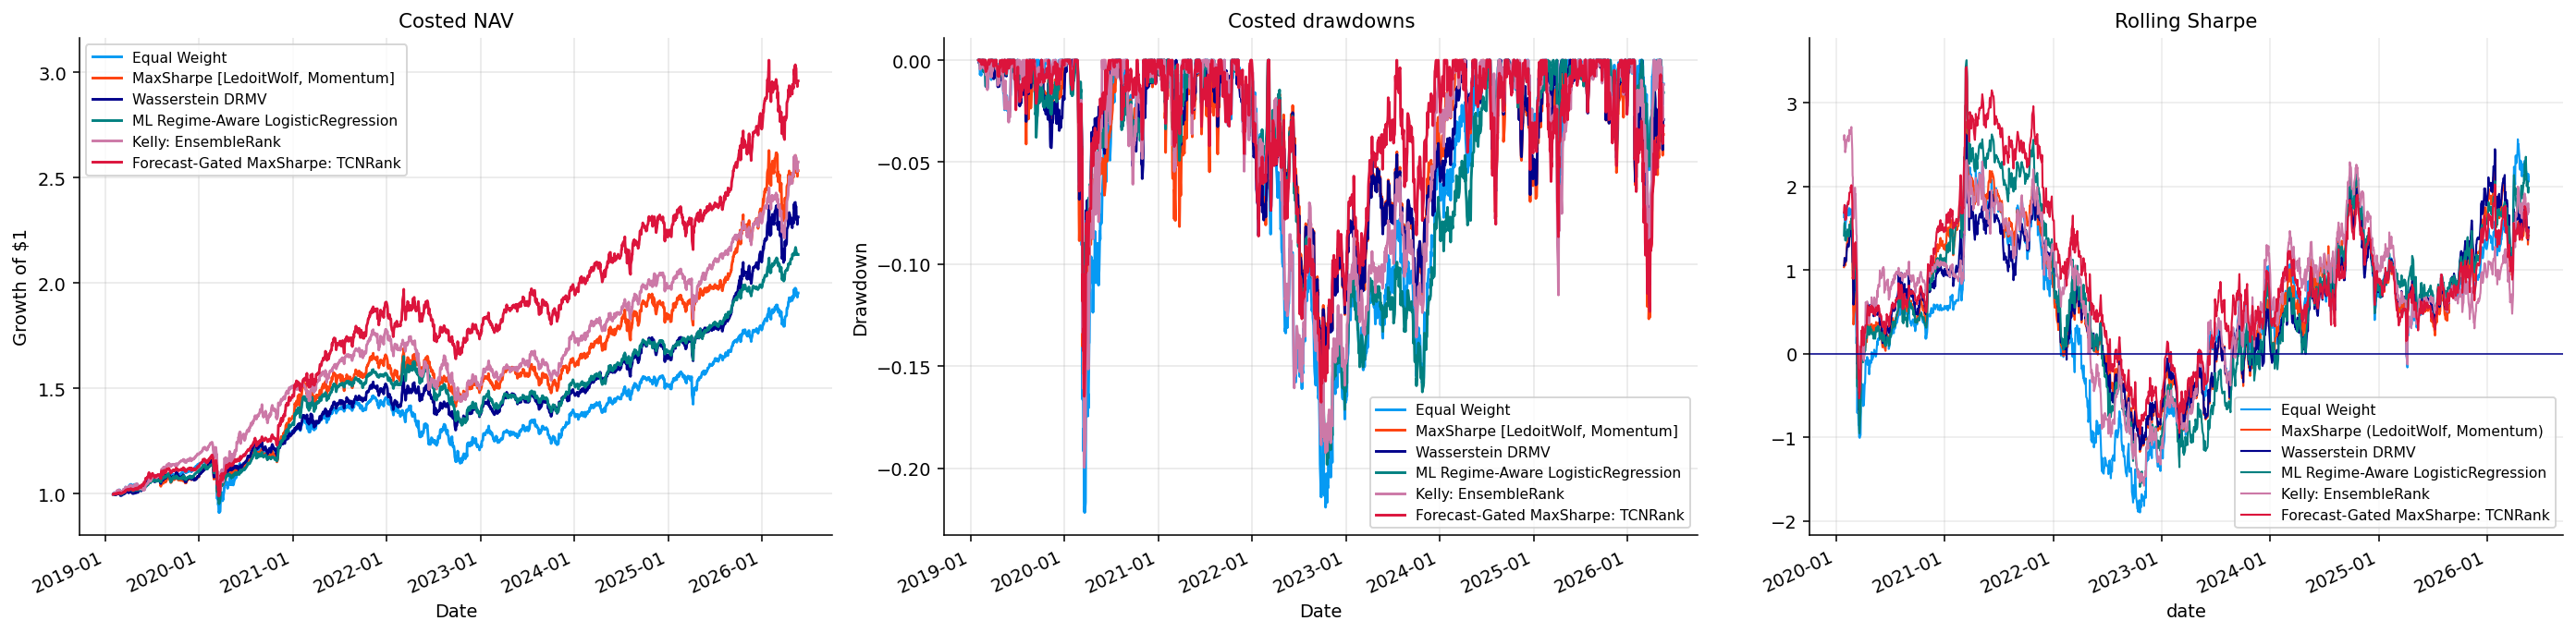

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(20.0, 5.0))
plot_strategy_nav(nav, ax=axes[0], title="Costed NAV")
plot_strategy_drawdowns(nav, ax=axes[1], title="Costed drawdowns")
plot_rolling_sharpe(axes[2], strategy_returns, rf_daily=rf_daily, title="Rolling Sharpe")
fig.tight_layout()
plt.show()

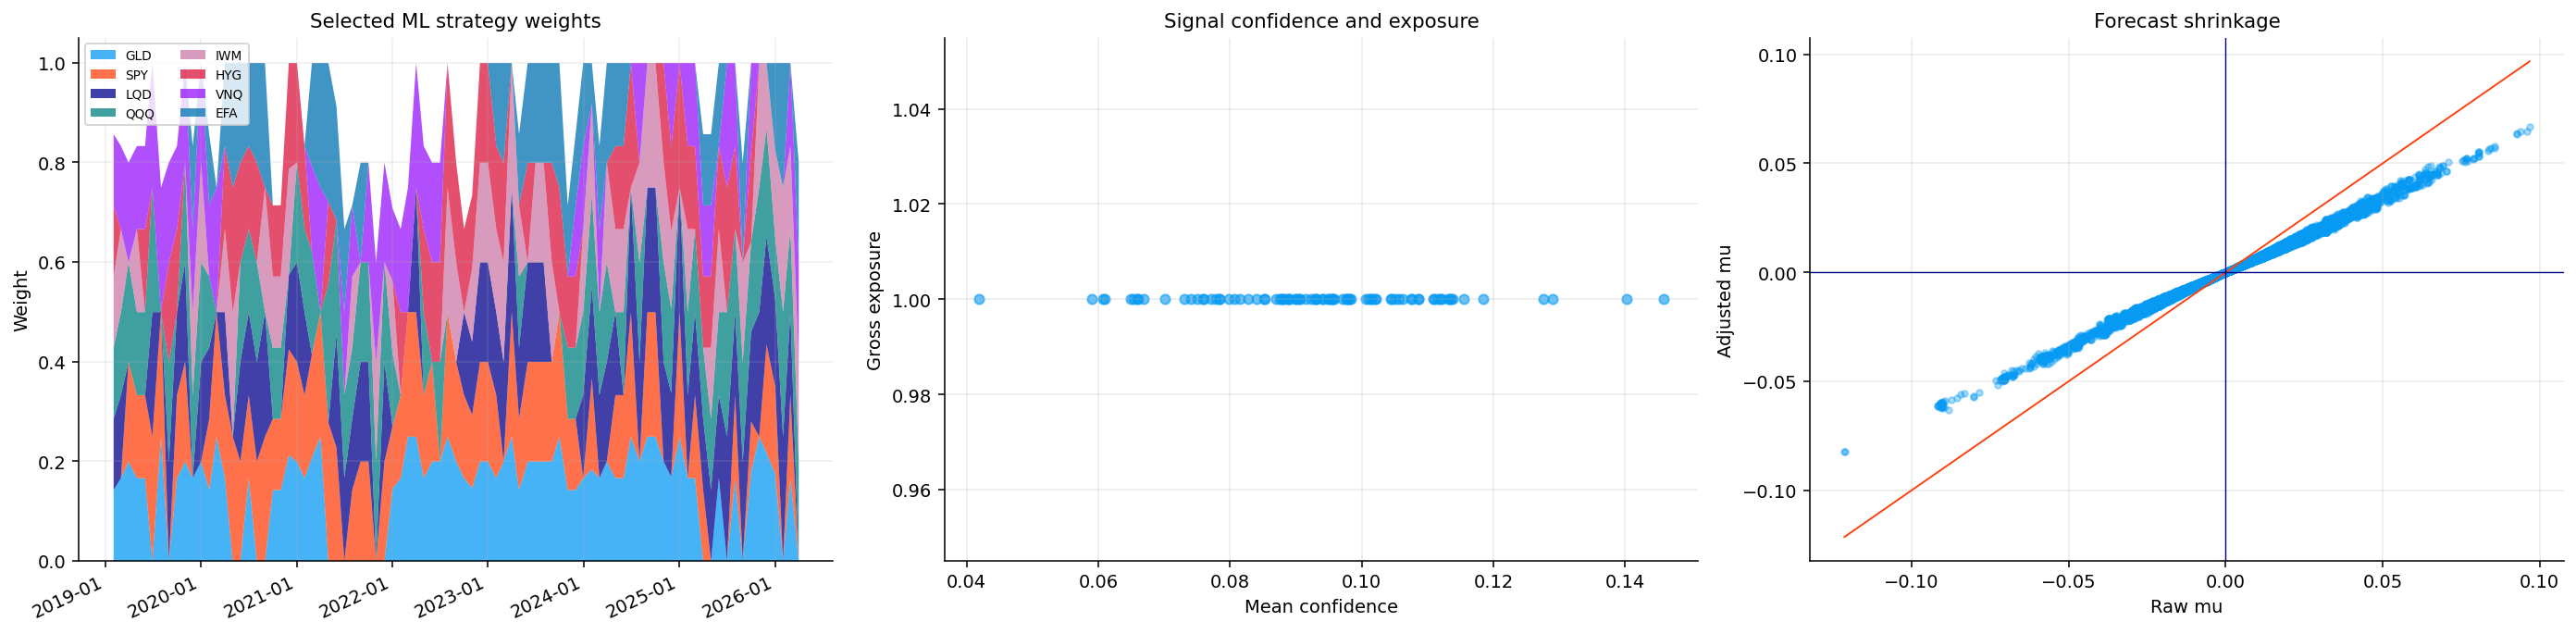

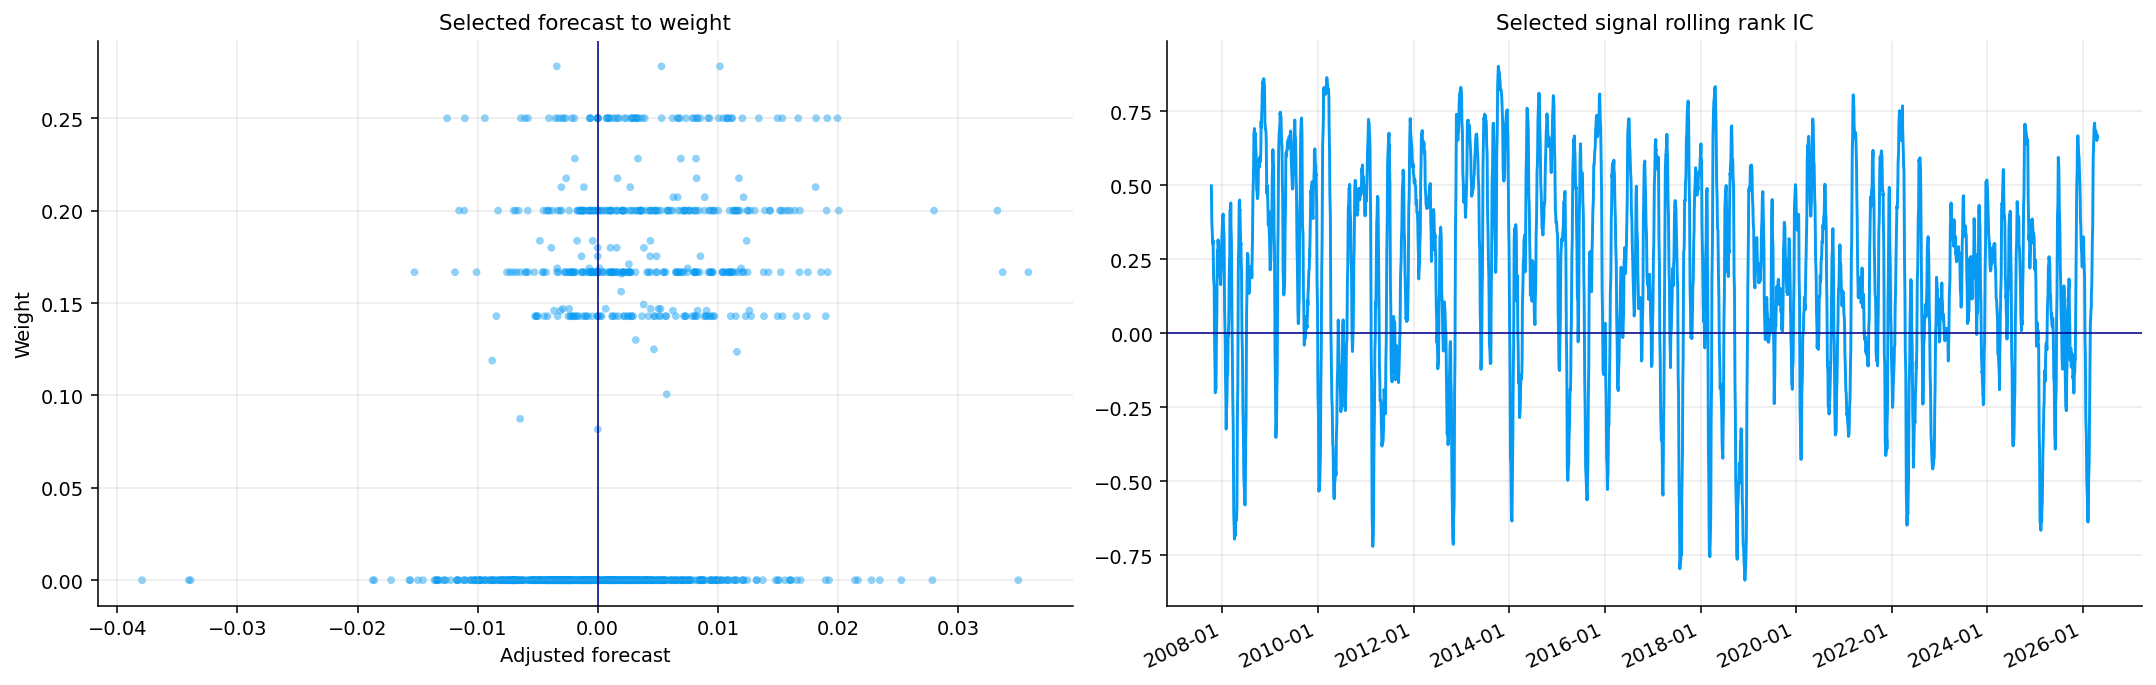

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(20.0, 5.0))
kelly_weight_path(axes[0], w_final.drop(columns=[cash_ticker], errors="ignore"), title="Selected ML strategy weights")
confidence_exposure_map(axes[1], forecast, weight_frame=w_final.drop(columns=[cash_ticker], errors="ignore"), title="Signal confidence and exposure")
kelly_shrinkage_curve(axes[2], forecast, mu_col="mu_hat", mu_adj_col="mu_adj", title="Forecast shrinkage")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.0))
forecast_to_weight_map(axes[0], forecast, weight_frame=w_final.drop(columns=[cash_ticker], errors="ignore"), title="Selected forecast to weight")
rolling_ic_chart(axes[1], forecast, date_col="date", asset_col="asset", y_col="y_alpha", pred_col=final_signal_col, title="Selected signal rolling rank IC")
fig.tight_layout()
plt.show()

In [74]:
latest_final_weights = w_final.tail(1).T.rename(columns={w_final.index[-1]: "latest_weight"})
display(latest_final_weights.sort_values("latest_weight", ascending=False).round(4))

,latest_weight
QQQ,0.2
EFA,0.2
IWM,0.2
EEM,0.2
VNQ,0.2
SPY,0.0
DBC,0.0
GLD,0.0
IEF,0.0
TLT,0.0


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Equal Weight,0.0106,0.0175,0.0115,0.0304,0.0114,0.0176
Forecast-Gated MaxSharpe: TCNRank,0.0120,0.0185,0.0125,0.0227,0.0179,0.0266
Kelly: EnsembleRank,0.0116,0.0190,0.0121,0.0278,0.0192,0.0289
ML Regime-Aware LogisticRegression,0.0093,0.0150,0.0102,0.0206,0.0076,0.0112
"MaxSharpe (LedoitWolf, Momentum)",0.0127,0.0202,0.0133,0.0235,0.0203,0.0295
Wasserstein DRMV,0.0115,0.0183,0.0123,0.0220,0.0225,0.0328


breach_count  breach_rate  \
object                             method                              
Equal Weight                       cf                97       0.0599   
                                   fhs               90       0.0556   
                                   hist              96       0.0593   
Forecast-Gated MaxSharpe: TCNRank  cf                92       0.0568   
                                   fhs               86       0.0531   
                                   hist             100       0.0618   
Kelly: EnsembleRank                cf                95       0.0587   
                                   fhs               93       0.0574   
                                   hist              94       0.0581   
ML Regime-Aware LogisticRegression cf                72       0.0445   
                                   fhs               86       0.0531   
                                   hist              87       0.0537   
MaxSharpe (LedoitWolf, Momentum)   cf                93       0.0574   
                                   fhs               87       0.0537   
                                   hist              96       0.0593   
Wasserstein DRMV                   cf                95       0.0587   
                                   fhs               87       0.0537   
                                   hist              98       0.0605   

                                           coverage_error  abs_coverage_error  \
object                             method                                       
Equal Weight                       cf              0.0099              0.0099   
                                   fhs             0.0056              0.0056   
                                   hist            0.0093              0.0093   
Forecast-Gated MaxSharpe: TCNRank  cf              0.0068              0.0068   
                                   fhs             0.0031              0.0031   
                                   hist            0.0118              0.0118   
Kelly: EnsembleRank                cf              0.0087              0.0087   
                                   fhs             0.0074              0.0074   
                                   hist            0.0081              0.0081   
ML Regime-Aware LogisticRegression cf             -0.0055              0.0055   
                                   fhs             0.0031              0.0031   
                                   hist            0.0037              0.0037   
MaxSharpe (LedoitWolf, Momentum)   cf              0.0074              0.0074   
                                   fhs             0.0037              0.0037   
                                   hist            0.0093              0.0093   
Wasserstein DRMV                   cf              0.0087              0.0087   
                                   fhs             0.0037              0.0037   
                                   hist            0.0105              0.0105   

                                           longest_breach_streak  \
object                             method                          
Equal Weight                       cf                          4   
                                   fhs                         3   
                                   hist                        4   
Forecast-Gated MaxSharpe: TCNRank  cf                          3   
                                   fhs                         2   
                                   hist                        3   
Kelly: EnsembleRank                cf                          4   
                                   fhs                         3   
                                   hist                        4   
ML Regime-Aware LogisticRegression cf                          3   
                                   fhs                         3   
                                   hist                        3   
MaxSharpe (LedoitWolf, Moment

,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 rates/inflation shock,Equal Weight,-0.1865,-0.2110,-0.0324,-0.0392
2022 rates/inflation shock,Forecast-Gated MaxSharpe: TCNRank,-0.0962,-0.1677,-0.0388,-0.0388
2022 rates/inflation shock,Kelly: EnsembleRank,-0.1751,-0.1876,-0.0356,-0.0355
2022 rates/inflation shock,ML Regime-Aware LogisticRegression,-0.1417,-0.1982,-0.0361,-0.0326
2022 rates/inflation shock,"MaxSharpe (LedoitWolf, Momentum)",-0.1100,-0.1633,-0.0368,-0.0346
2022 rates/inflation shock,Wasserstein DRMV,-0.1054,-0.1646,-0.0387,-0.0366
2023 rebound,Equal Weight,0.1391,-0.0876,-0.0151,-0.0240
2023 rebound,Forecast-Gated MaxSharpe: TCNRank,0.1315,-0.0857,-0.0181,-0.0275
2023 rebound,Kelly: EnsembleRank,0.1595,-0.0832,-0.0158,-0.0232


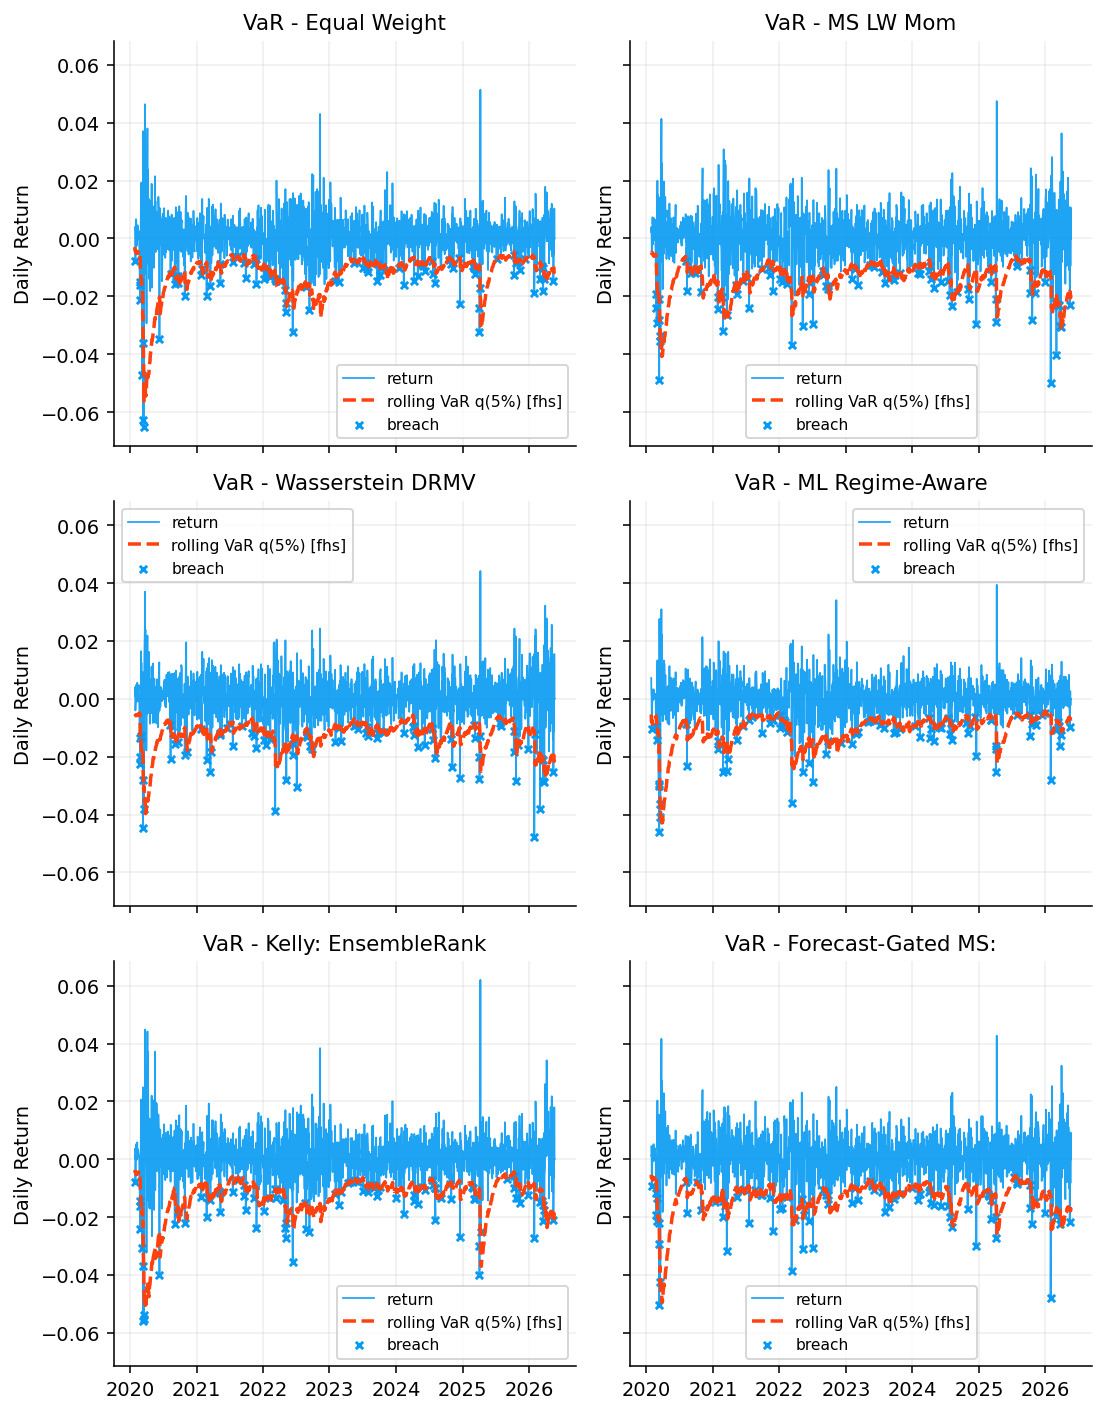

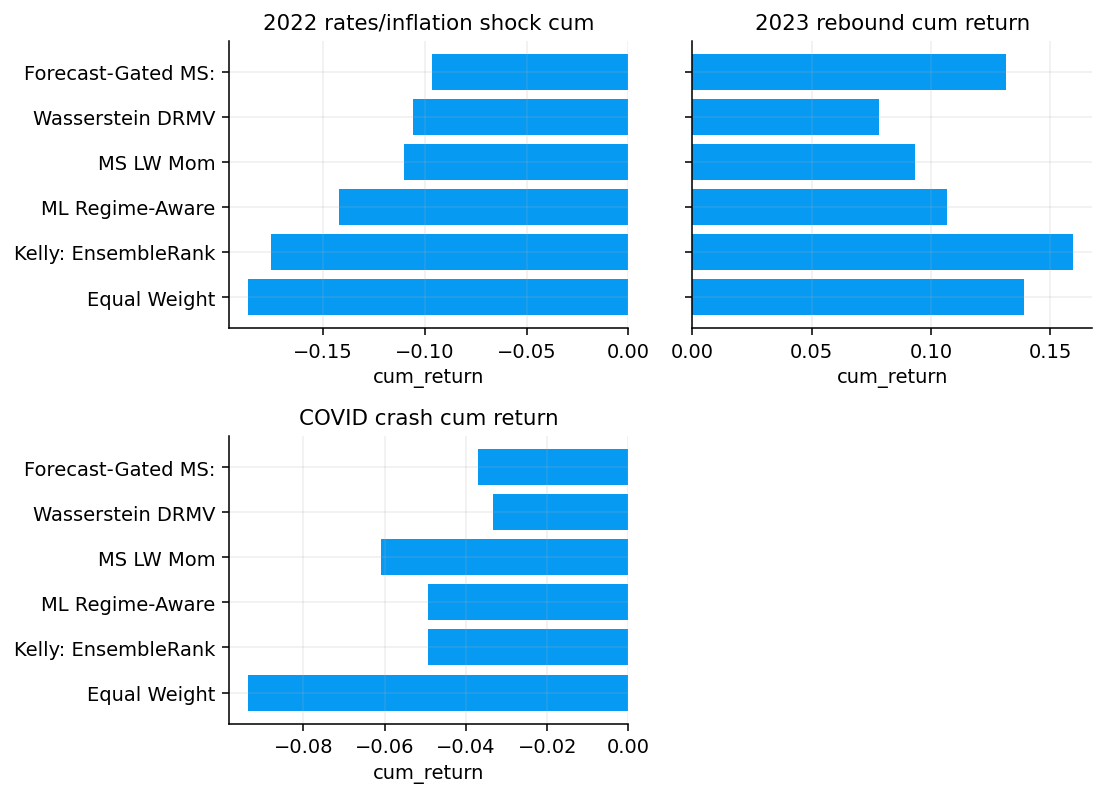

In [75]:
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}
available_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1])
    and strategy_returns.index.max() >= pd.Timestamp(window[0])
}

risk = risk_report(
    objects={name: strategy_returns[name].dropna() for name in strategy_returns.columns},
    market_ret=r_d[benchmark_ticker].reindex(strategy_returns.index).dropna(),
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": available_windows, "worst_only": False},
    output={
        "display_tables": True,
        "show_figures": True,
        "display_table_keys": ["var_es", "var_backtest", "stress"],
        "round_tables": 4,
        "short_labels": False,
    },
)

## Library Extraction

In [76]:
from quantfinlab.ml.features import build_asset_feature_block, build_cross_asset_feature_block, assemble_forecasting_table, feature_availability_by_date, trim_feature_table_by_availability
from quantfinlab.ml.sequence_models import MlpForecast, LstmForecast, TcnForecast, train_torch_model, torch_predictions
from quantfinlab.portfolio.sizing import (
    cap_weights,
    forecast_gated_maxsharpe_weight_frame,
    smooth_weights,
    weights_from_forecasts,
)

library_functions = pd.Series([
    "build_asset_feature_block",
    "build_cross_asset_feature_block",
    "build_fci_feature_block",
    "feature_availability_by_date / trim_feature_table_by_availability",
    "regime_probability_features",
    "MlpForecast / LstmForecast / TcnForecast",
    "train_torch_model / torch_predictions",
    "forecast_metrics / rank_metrics / quantile_metrics",
    "weights_from_forecasts / forecast_gated_maxsharpe_weight_frame",
], name="reusable_function").to_frame()
display(library_functions)

,reusable_function
0,build_asset_feature_block
1,build_cross_asset_feature_block
2,build_fci_feature_block
3,feature_availability_by_date / trim_feature_ta...
4,regime_probability_features
5,MlpForecast / LstmForecast / TcnForecast
6,train_torch_model / torch_predictions
7,forecast_metrics / rank_metrics / quantile_met...
8,weights_from_forecasts / forecast_gated_maxsha...


In [77]:
lib_asset_features = build_asset_feature_block(close, volume, r_d, assets=assets, rf_daily=rf_daily)
lib_cross_features = build_cross_asset_feature_block(close, r_d, assets=assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
lib_check = pd.Series({
    "asset_feature_rows": len(lib_asset_features),
    "cross_feature_columns": lib_cross_features.shape[1],
    "selected_features_tree": len(selected_features_tree),
    "selected_features_nn": len(selected_features_nn),
})
display(lib_check.to_frame("value"))

,value
asset_feature_rows,58764
cross_feature_columns,16
selected_features_tree,46
selected_features_nn,28


## Reusable Module Contract Checks

In [78]:
contract_check = pd.Series({
    "feature_table_has_targets": {"r_ex_21", "sigma_21", "z_21", "y_alpha"}.issubset(data.columns),
    "feature_table_has_regime_columns": {"p_risk_on", "p_neutral", "p_defensive", "regime_confidence"}.issubset(data.columns),
    "main_tabular_metric_rows": len(tabular_metrics),
    "probabilistic_metric_rows": len(prob_metrics),
    "allocator_matrix_rows": len(matrix_summary),
})
display(contract_check.to_frame("value"))

,value
feature_table_has_targets,True
feature_table_has_regime_columns,True
main_tabular_metric_rows,6
probabilistic_metric_rows,4
allocator_matrix_rows,36


## Final Sector Implementation

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9152\2997514606.py:570: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(coverage_s.loc[sector_assets + [cash_ticker]].round(4))


,first_date,last_date,observations,coverage
XLB,2007-01-03,2026-05-22,4966,1.0
XLE,2007-01-03,2026-05-22,4966,1.0
XLF,2007-01-03,2026-05-22,4966,1.0
XLI,2007-01-03,2026-05-22,4966,1.0
XLK,2007-01-03,2026-05-22,4966,1.0
XLP,2007-01-03,2026-05-22,4966,1.0
XLU,2007-01-03,2026-05-22,4966,1.0
XLV,2007-01-03,2026-05-22,4966,1.0
XLY,2007-01-03,2026-05-22,4966,1.0
SHY,2007-01-03,2026-05-22,4966,1.0


,value
sector_first_common_price_date,2007-01-03 00:00:00
sector_raw_target_rows,43938
sector_full_cross_section_target_rows,43938
sector_first_model_date,2007-04-02 00:00:00
sector_rows,43938


,row_count,asset_count,feature_coverage,min_asset_feature_coverage,min_feature_cross_section_coverage,target_complete
date,,,,,,
2007-04-02,9,9,0.7917,0.7917,0.0,1.0
2007-04-03,9,9,0.7917,0.7917,0.0,1.0
2007-04-04,9,9,0.7917,0.7917,0.0,1.0
2007-04-05,9,9,0.7882,0.7604,0.0,1.0
2007-04-09,9,9,0.7882,0.7604,0.0,1.0
2007-04-10,9,9,0.7882,0.7604,0.0,1.0
2007-04-11,9,9,0.7917,0.7917,0.0,1.0
2007-04-12,9,9,0.7917,0.7917,0.0,1.0
2007-04-13,9,9,0.7917,0.7917,0.0,1.0


,selected_features_tree
0,xs_z_vol_63
1,group_rel_sharpe_126
2,rank_vol_63_x_p_defensive
3,vol_63
4,beta_spy_63
5,rel_vol_63_avg
6,vol_of_vol_63
7,xs_z_drawdown_126
8,skew_63
9,p_defensive


...

,selected_lambda_alpha
signal,
RandomForest,1.50
ExtraTrees,0.75
GradientBoosting,0.50
HistGradientBoosting,0.75
QuantileGBM,1.50
TCNRank,1.50
ValidationBlend,1.50
UncertaintyAdjusted,1.50


,Kelly,Forecast-Gated MaxSharpe
RandomForest,0.6408,0.5558
ExtraTrees,0.5178,0.6247
GradientBoosting,0.6693,0.6589
HistGradientBoosting,0.6759,0.8059
QuantileGBM,0.5464,0.6003
TCNRank,0.6382,0.6990
ValidationBlend,0.5830,0.5948
UncertaintyAdjusted,0.5924,0.6949


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
HistGradientBoosting | Forecast-Gated MaxSharpe,HistGradientBoosting | Forecast-Gated MaxSharpe,-,-,0.1887,0.1877,0.8059,-0.3098,0.6092,1.0135,0.3879,33.7463,0.0187,3.0982,0
TCNRank | Forecast-Gated MaxSharpe,TCNRank | Forecast-Gated MaxSharpe,-,-,0.1662,0.1896,0.6990,-0.3150,0.5278,0.8730,0.3861,33.5923,0.0188,3.0812,0
UncertaintyAdjusted | Forecast-Gated MaxSharpe,UncertaintyAdjusted | Forecast-Gated MaxSharpe,-,-,0.1659,0.1906,0.6949,-0.3139,0.5287,0.8685,0.3909,34.0115,0.0191,3.0952,0
HistGradientBoosting | Kelly,HistGradientBoosting | Kelly,-,-,0.1562,0.1800,0.6759,-0.3239,0.4823,0.8447,0.4677,40.6913,0.0246,4.3953,0
GradientBoosting | Kelly,GradientBoosting | Kelly,-,-,0.1565,0.1847,0.6693,-0.3387,0.4621,0.8094,0.3898,33.9143,0.0204,4.3958,0
GradientBoosting | Forecast-Gated MaxSharpe,GradientBoosting | Forecast-Gated MaxSharpe,-,-,0.1509,0.1787,0.6589,-0.3168,0.4763,0.8105,0.3125,27.1908,0.0159,3.1146,0
RandomForest | Kelly,RandomForest | Kelly,-,-,0.1492,0.1812,0.6408,-0.3425,0.4356,0.7682,0.3495,30.4069,0.0193,4.7478,0
TCNRank | Kelly,TCNRank | Kelly,-,-,0.1533,0.1903,0.6382,-0.3593,0.4267,0.7858,0.4522,39.3372,0.0242,4.2937,0
ExtraTrees | Forecast-Gated MaxSharpe,ExtraTrees | Forecast-Gated MaxSharpe,-,-,0.1447,0.1801,0.6247,-0.3168,0.4566,0.7794,0.3230,28.1053,0.0168,3.0837,0


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Forecast-Gated MaxSharpe: HistGradientBoosting,Forecast-Gated MaxSharpe: HistGradientBoosting,-,-,0.1887,0.1877,0.8059,-0.3098,0.6092,1.0135,0.3879,33.7463,0.0187,3.0982,0
"MaxSharpe (LedoitWolf, BayesStein)",MaxSharpe,BayesStein,LedoitWolf,0.1760,0.1887,0.7504,-0.3070,0.5733,0.9458,0.1652,14.3726,0.0083,3.1816,0
Kelly: HistGradientBoosting,Kelly: HistGradientBoosting,-,-,0.1562,0.1800,0.6759,-0.3239,0.4823,0.8447,0.4677,40.6913,0.0246,4.3953,0
Wasserstein DRMV,Wasserstein DRMV,-,-,0.1355,0.1773,0.5887,-0.3057,0.4430,0.7254,0.2055,17.8773,0.0117,3.4000,0
ML Regime-Aware GradientBoosting,ML Regime-Aware GradientBoosting,-,-,0.1320,0.1696,0.5871,-0.3185,0.4145,0.6963,0.1864,16.2149,0.0112,5.7706,0
Equal Weight,Equal Weight,-,-,0.1389,0.1836,0.5863,-0.3669,0.3785,0.6917,0.0193,1.6809,0.0009,9.0000,0


,latest_weight
XLK,0.3333
XLP,0.3333
XLU,0.3333
XLB,0.0000
XLE,0.0000
XLI,0.0000
XLF,0.0000
XLV,0.0000
XLY,0.0000
SHY,0.0000


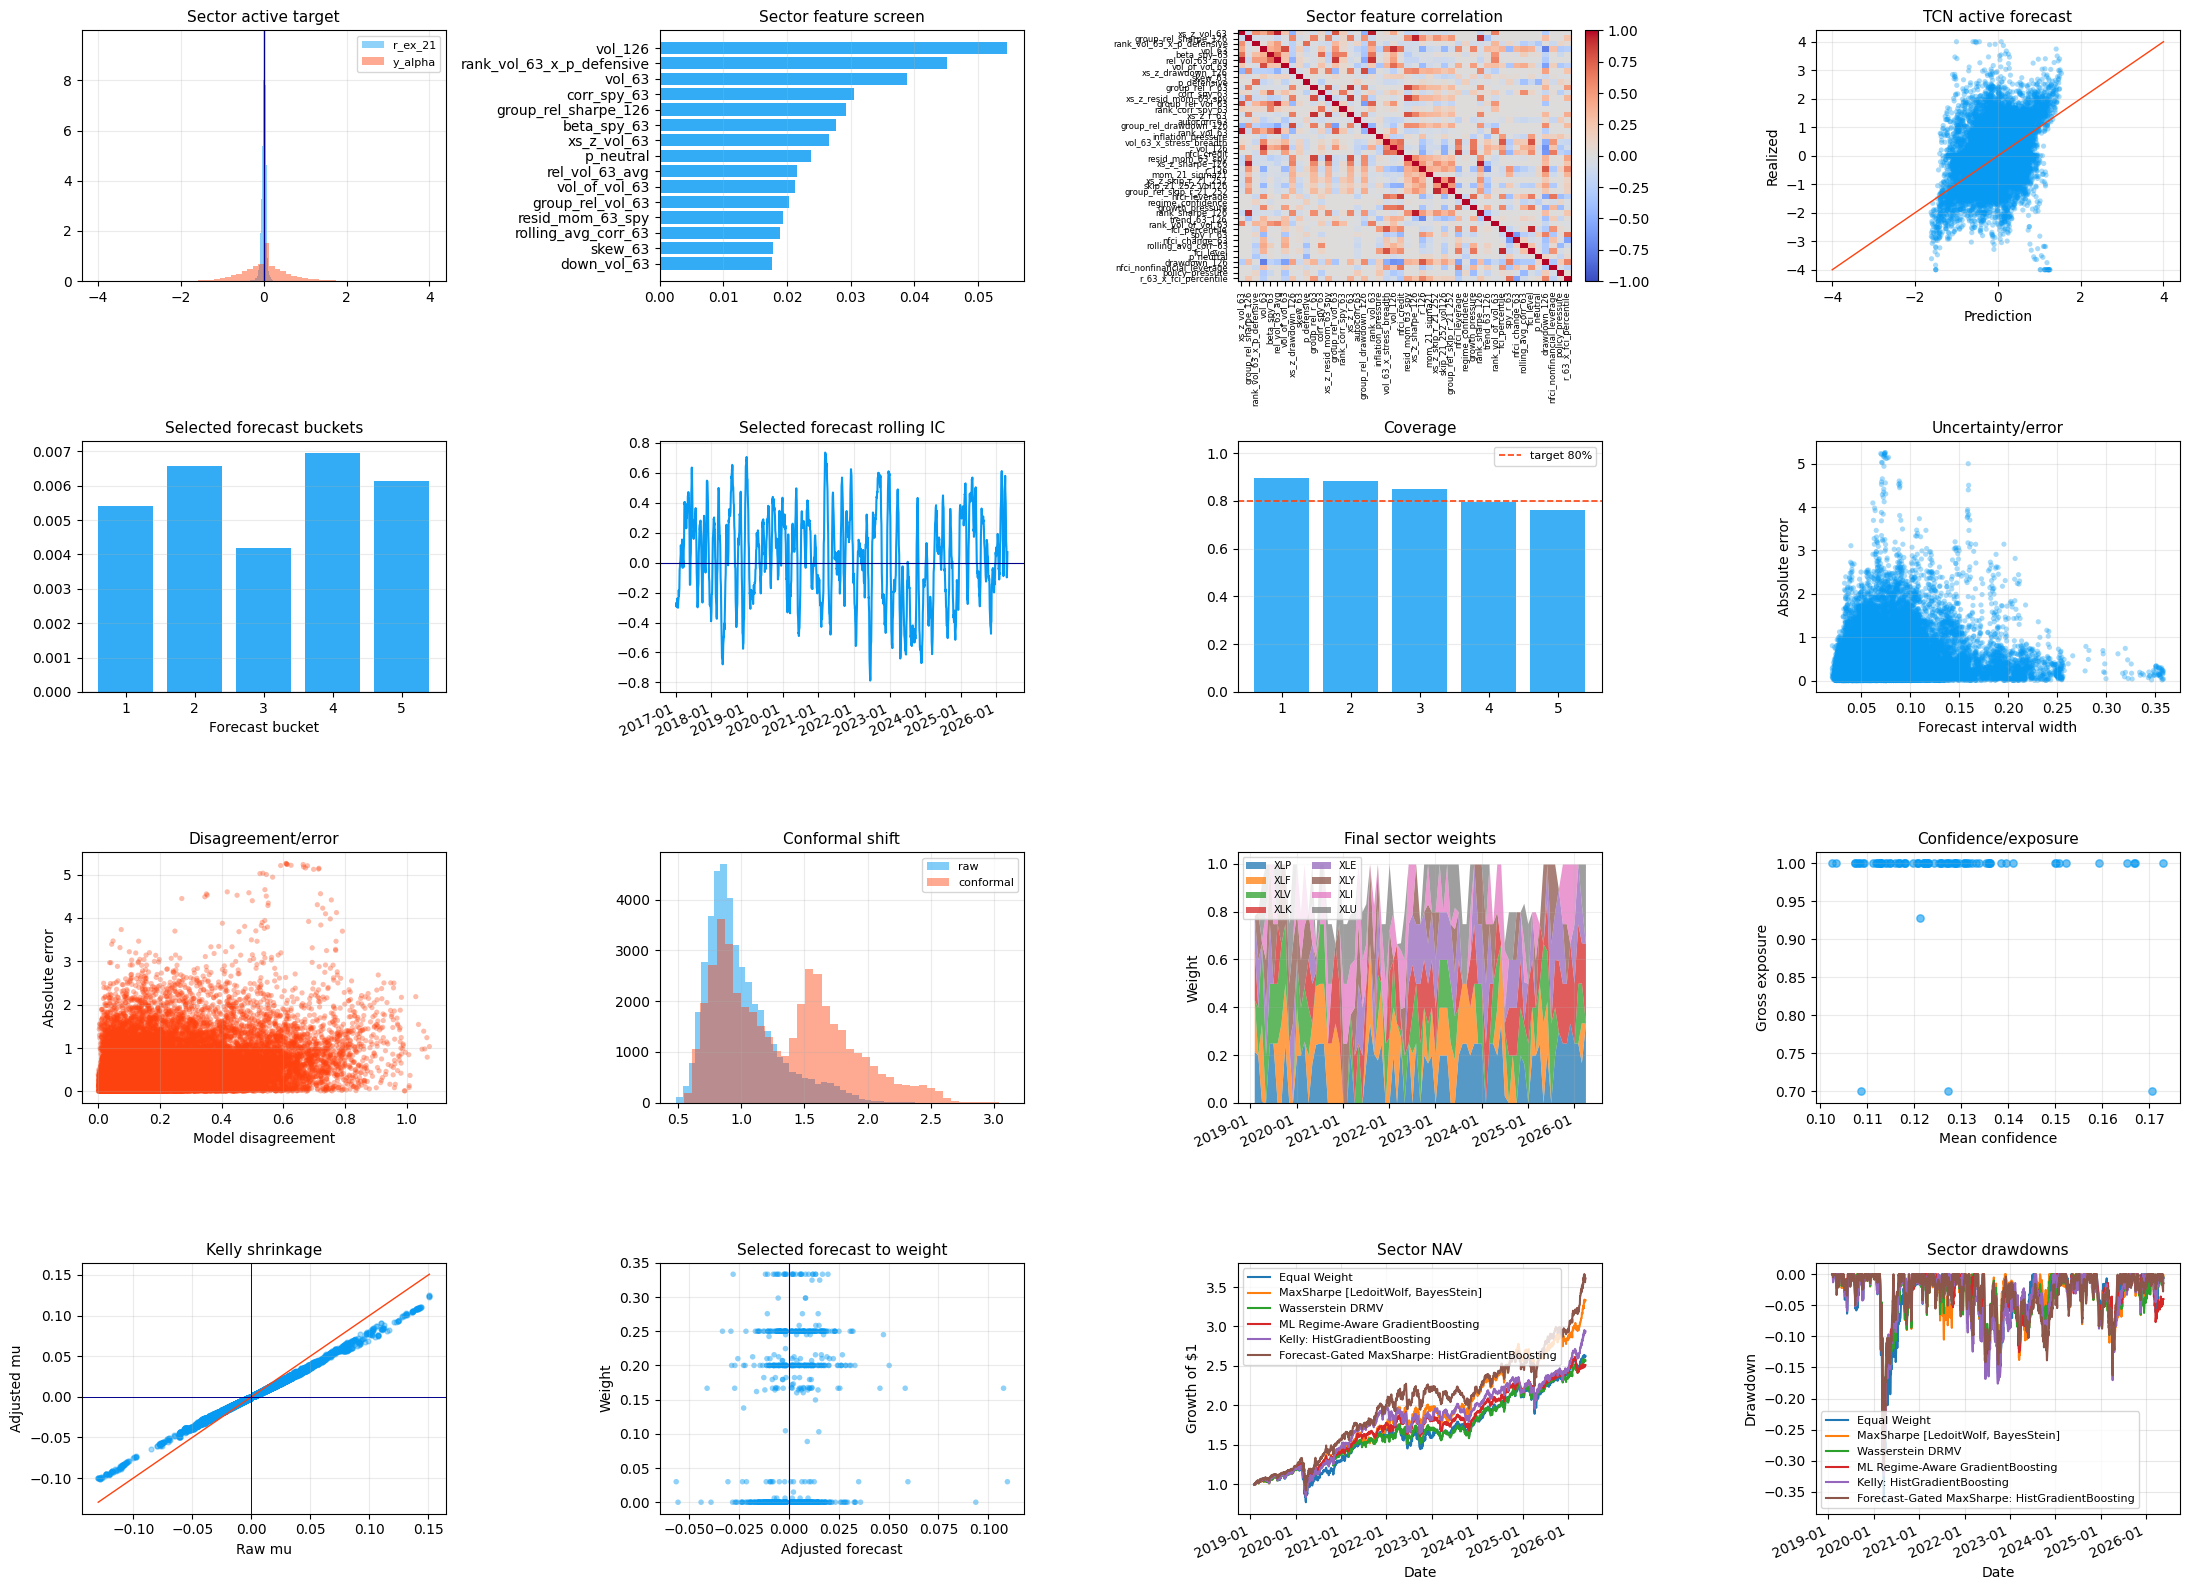

,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Equal Weight,0.0151,0.0274,0.0158,0.0578,0.0103,0.0151
Forecast-Gated MaxSharpe: HistGradientBoosting,0.0168,0.0275,0.0163,0.0485,0.0165,0.0233
Kelly: HistGradientBoosting,0.0159,0.0263,0.0156,0.0466,0.0124,0.0178
ML Regime-Aware GradientBoosting,0.0142,0.0252,0.0137,0.0577,0.0097,0.0152
"MaxSharpe (LedoitWolf, BayesStein)",0.0167,0.0272,0.0164,0.0497,0.0115,0.0168
Wasserstein DRMV,0.0154,0.0256,0.0147,0.0530,0.0115,0.0172


breach_count  \
object                                         method                 
Equal Weight                                   cf                89   
                                               fhs               90   
                                               hist              86   
Forecast-Gated MaxSharpe: HistGradientBoosting cf                93   
                                               fhs               91   
                                               hist              85   
Kelly: HistGradientBoosting                    cf                92   
                                               fhs               83   
                                               hist              83   
ML Regime-Aware GradientBoosting               cf                81   
                                               fhs               91   
                                               hist              81   
MaxSharpe (LedoitWolf, BayesStein)             cf                83   
                                               fhs               81   
                                               hist              79   
Wasserstein DRMV                               cf                86   
                                               fhs               81   
                                               hist              82   

                                                       breach_rate  \
object                                         method                
Equal Weight                                   cf           0.0550   
                                               fhs          0.0556   
                                               hist         0.0531   
Forecast-Gated MaxSharpe: HistGradientBoosting cf           0.0574   
                                               fhs          0.0562   
                                               hist         0.0525   
Kelly: HistGradientBoosting                    cf           0.0568   
                                               fhs          0.0513   
                                               hist         0.0513   
ML Regime-Aware GradientBoosting               cf           0.0500   
                                               fhs          0.0562   
                                               hist         0.0500   
MaxSharpe (LedoitWolf, BayesStein)             cf           0.0513   
                                               fhs          0.0500   
                                               hist         0.0488   
Wasserstein DRMV                               cf           0.0531   
                                               fhs          0.0500   
                                               hist         0.0506   

                                                       coverage_error  \
object                                         method                   
Equal Weight                                   cf              0.0050   
                                               fhs             0.0056   
                                               hist            0.0031   
Forecast-Gated MaxSharpe: HistGradientBoosting cf              0.0074   
                                               fhs             0.0062   
                                               hist            0.0025   
Kelly: HistGradientBoosting                    cf              0.0068   
                                               fhs             0.0013   
                                               hist            0.0013   
ML Regime-Aware GradientBoosting               cf              0.0000   
                                               fhs             0.0062   
                                               hist            0.0000   
MaxSharpe (LedoitWolf, BayesStein)             cf              0.0013   
                                               fhs             0.0000   
                                               hist           -0.

,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 rates/inflation shock,Equal Weight,-0.0620,-0.1703,-0.0378,-0.0743
2022 rates/inflation shock,Forecast-Gated MaxSharpe: HistGradientBoosting,0.0915,-0.1452,-0.0410,-0.1103
2022 rates/inflation shock,Kelly: HistGradientBoosting,-0.0719,-0.1760,-0.0372,-0.0842
2022 rates/inflation shock,ML Regime-Aware GradientBoosting,0.0131,-0.1587,-0.0419,-0.1089
2022 rates/inflation shock,"MaxSharpe (LedoitWolf, BayesStein)",0.1151,-0.1433,-0.0420,-0.1105
2022 rates/inflation shock,Wasserstein DRMV,0.0390,-0.1425,-0.0375,-0.0889
2023 rebound,Equal Weight,0.1388,-0.1019,-0.0178,-0.0488
2023 rebound,Forecast-Gated MaxSharpe: HistGradientBoosting,-0.0015,-0.1270,-0.0236,-0.0397
2023 rebound,Kelly: HistGradientBoosting,0.0950,-0.1142,-0.0206,-0.0455


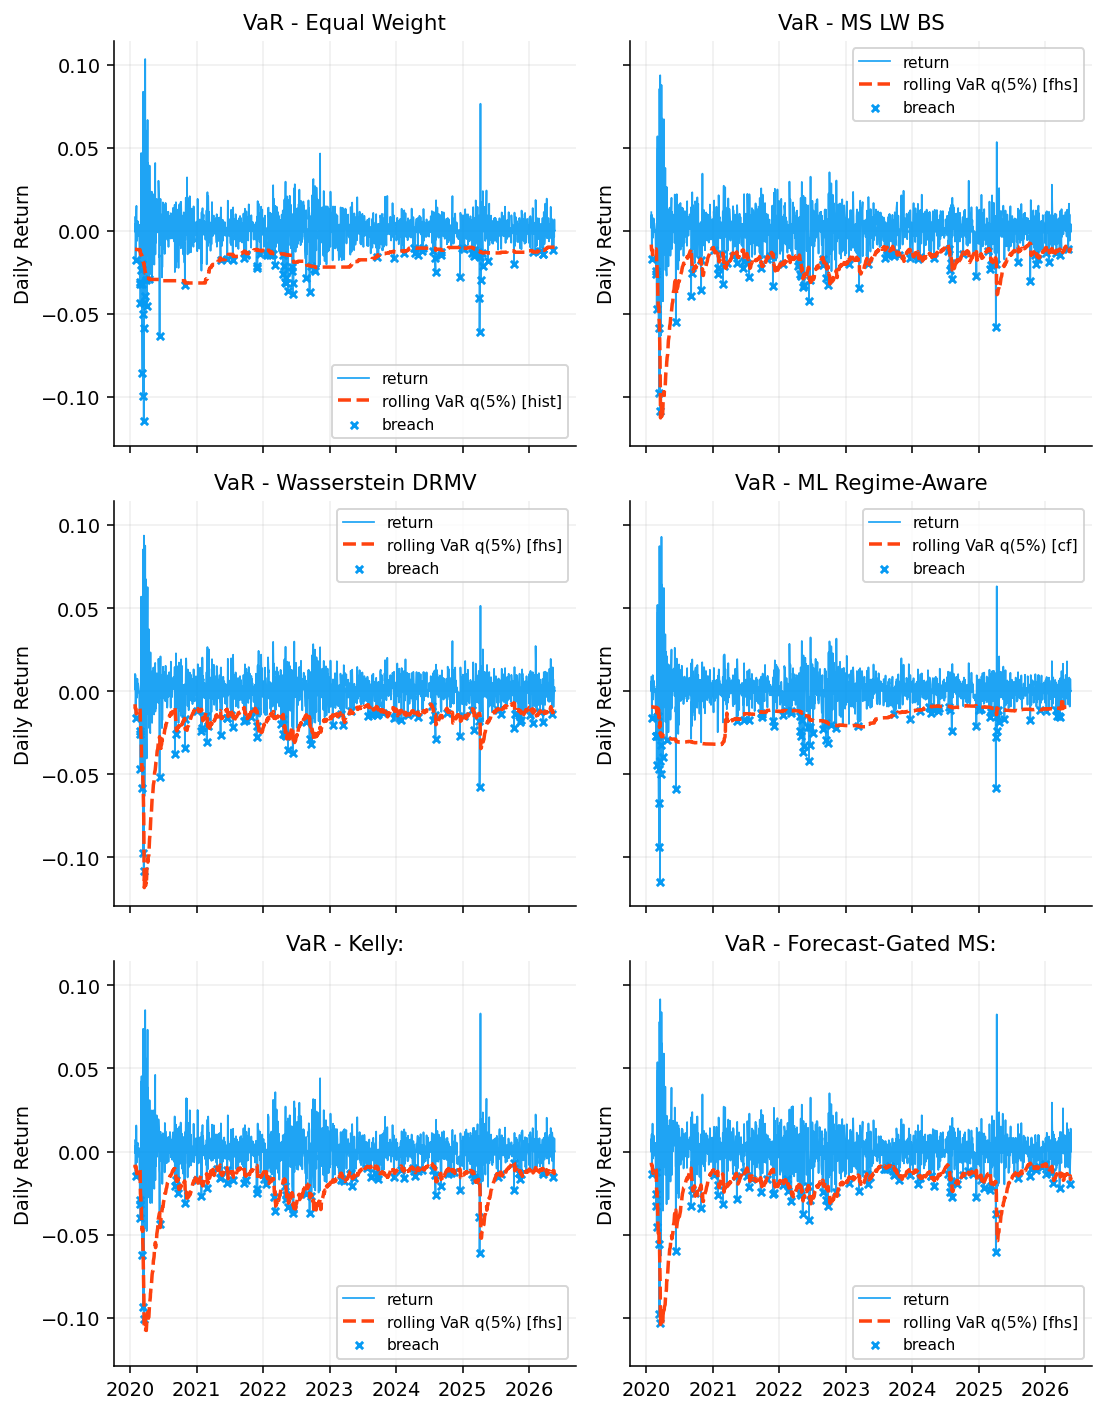

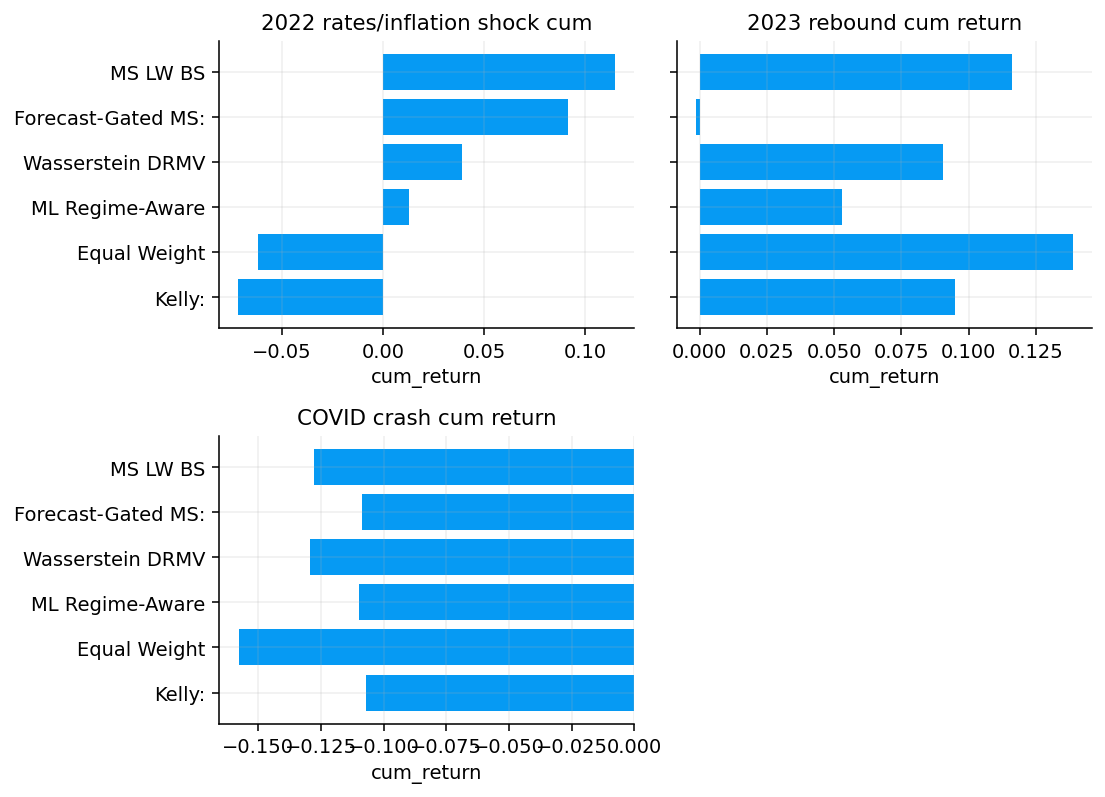

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from joblib import Parallel, delayed
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_nfci, load_yfinance_panel, prices_to_returns_panel
from quantfinlab.ml.evaluation import forecast_buckets, forecast_metrics, quantile_metrics, rank_metrics, walkforward_tabular_predictions
from quantfinlab.ml.probabilistic import apply_rolling_conformal
from quantfinlab.ml.uncertainty import confidence_adjusted_mu, disagreement_confidence, forecast_confidence, model_disagreement
from quantfinlab.plotting.portfolio import (
    confidence_exposure_map,
    conformal_shift_chart,
    coverage_reliability,
    disagreement_error_map,
    feature_correlation_map,
    feature_importance_bars,
    forecast_buckets_chart,
    forecast_scatter,
    forecast_to_weight_map,
    kelly_shrinkage_curve,
    kelly_weight_path,
    plot_strategy_drawdowns,
    plot_strategy_nav,
    rolling_ic_chart,
    target_distribution,
    uncertainty_error_map,
)
from quantfinlab.portfolio import covariance, expected_returns, optimizers
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary
from quantfinlab.portfolio.universe import make_rebalance_dates
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.reports.risk_report import risk_report
from quantfinlab.ml.features import (
    assemble_forecasting_table,
    build_asset_feature_block,
    build_cross_asset_feature_block,
    build_fci_feature_block,
    clean_feature_columns,
    feature_availability_by_date,
    regime_probability_features,
    trim_feature_table_by_availability,
)
from quantfinlab.ml.sequence_models import TcnForecast, auto_device, torch_predictions, train_torch_model
from quantfinlab.portfolio.sizing import (
    align_weight_frame,
    cap_weights,
    forecast_gated_maxsharpe_weight_frame,
    smooth_weights,
    weights_from_forecasts,
)


data_path = Path("../data") if Path("../data/sector_etfs.csv").exists() else Path("data")
macro_factors = load_macro_factors(data_path / "us_macro_factors.csv", start="1990-01-01")
nfci = load_nfci(data_path / "nfci.csv")
rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0
annualization = 252.0
cost_bps = 10.0
horizon = 21
vol_lookback = 63
train_end = pd.Timestamp("2018-12-31")
validation_start = pd.Timestamp("2017-01-01")
test_start = pd.Timestamp("2019-01-01")
train_label_cutoff_s = train_end - pd.tseries.offsets.BDay(horizon)
validation_end_s = train_label_cutoff_s
TABULAR_TRAIN_WINDOW = 252 * 8
cash_ticker = "SHY"
benchmark_ticker = "SPY"
cpu_count = os.cpu_count() or 1
outer_n_jobs = max(1, min(4, cpu_count))
forest_inner_jobs = max(1, cpu_count // outer_n_jobs)

sector_assets = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
sector_universe_signature = ",".join(sector_assets)
sector_tickers = sector_assets + [cash_ticker, benchmark_ticker]
sector_panels = load_yfinance_panel(
    [data_path / "sector_etfs.csv", data_path / "core_cross_asset_etfs.csv"],
    fields=("close", "volume"),
    tickers=sector_tickers,
    source="yfinance_export",
    start="2007-01-01",
)
close_s = sector_panels["close"].reindex(columns=sector_tickers).ffill(limit=3)
volume_s = sector_panels["volume"].reindex(index=close_s.index, columns=sector_tickers).ffill(limit=3)
close_s = close_s.dropna(how="all")
volume_s = volume_s.reindex(close_s.index)
first_common_sector_date = close_s[sector_assets + [cash_ticker, benchmark_ticker]].dropna(how="any").index.min()
close_s = close_s.loc[first_common_sector_date:].copy()
volume_s = volume_s.reindex(close_s.index).copy()

coverage_s = pd.DataFrame({
    "first_date": close_s[sector_assets + [cash_ticker]].apply(pd.Series.first_valid_index),
    "last_date": close_s[sector_assets + [cash_ticker]].apply(pd.Series.last_valid_index),
    "observations": close_s[sector_assets + [cash_ticker]].notna().sum(),
    "coverage": close_s[sector_assets + [cash_ticker]].notna().mean(),
})
r_s = prices_to_returns_panel(close_s, kind="simple").fillna(0.0)
r_log_s = np.log(close_s / close_s.shift(1))
fwd_s = np.log(close_s[sector_assets].shift(-horizon) / close_s[sector_assets])
rf_forward_log_s = horizon * np.log1p(rf_daily)
r_ex_21_s = fwd_s - rf_forward_log_s
sigma_21_s = r_log_s[sector_assets].rolling(vol_lookback, min_periods=vol_lookback).std(ddof=1) * np.sqrt(horizon)
z_21_s = (r_ex_21_s / sigma_21_s.replace(0.0, np.nan)).clip(-4.0, 4.0)
y_alpha_s = z_21_s.sub(z_21_s.median(axis=1), axis=0).clip(-4.0, 4.0)
rebalance_s = make_rebalance_dates(close_s.index, freq="ME", min_history_days=756)
target_s = (
    pd.concat({"r_ex_21": r_ex_21_s, "sigma_21": sigma_21_s, "z_21": z_21_s, "y_alpha": y_alpha_s}, axis=1)
    .stack(level=1)
    .rename_axis(["date", "asset"])
    .reset_index()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
target_s_counts = target_s.groupby("date")["asset"].nunique()
target_s_rows_before_full = len(target_s)
target_s = target_s[target_s["date"].isin(target_s_counts[target_s_counts.eq(len(sector_assets))].index)].copy()
target_s = target_s.sort_values(["date", "asset"]).reset_index(drop=True)
rebalance_s = pd.DatetimeIndex([d for d in rebalance_s if d <= target_s["date"].max()])
base_s = target_s[target_s["date"].isin(rebalance_s)].copy()

fixed_sector_universe = {
    pd.Timestamp(dt): {"tickers": list(sector_assets), "avg_dollar_volume": pd.Series(1.0, index=sector_assets)}
    for dt in rebalance_s
}
sector_grid = run_walkforward_grid(
    returns=r_s[sector_assets],
    close=close_s[sector_assets],
    volume=volume_s[sector_assets],
    rebalance_dates=rebalance_s,
    universe_by_date=fixed_sector_universe,
    cov_models={"LedoitWolf": covariance.ledoit_wolf_covariance},
    mu_models={"BayesStein": expected_returns.bayes_stein_mu},
    optimizers={"EW": optimizers.equal_weight, "MaxSharpe": optimizers.max_sharpe_slsqp},
    strategy_specs=[
        {"name": "Equal Weight", "optimizer": "EW"},
        {
            "name": "MaxSharpe (LedoitWolf, BayesStein)",
            "optimizer": "MaxSharpe",
            "cov_model": "LedoitWolf",
            "mu_model": "BayesStein",
        },
    ],
    cov_lookback=756,
    mu_lookback=252,
    min_cov_observations=755,
    min_mu_observations=251,
    max_weight=0.35,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=10.0,
    rf_daily=rf_daily,
    annualization=annualization,
)
sector_dates = pd.DatetimeIndex(sector_grid.metadata["rebalance_dates"])
w_wasserstein_s = wasserstein_weight_frame(
    sector_grid.cache,
    sector_dates,
    cov_model="LedoitWolf",
    mu_model="BayesStein",
    radius=0.25,
    mv_lambda=3.0,
    w_min=0.0,
    w_max=0.35,
)
w_regime_s = regime_probability_features(
    close_s,
    r_s,
    assets=sector_assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="GradientBoosting",
    horizon=horizon,
    rebalance_dates=sector_dates,
    output="weights",
    max_weight=0.35,
    n_jobs=outer_n_jobs,
)

asset_features_s = build_asset_feature_block(close_s, volume_s, r_s, assets=sector_assets, rf_daily=rf_daily)
cross_features_s = build_cross_asset_feature_block(close_s, r_s, assets=sector_assets, cash_ticker=cash_ticker, benchmark_ticker=benchmark_ticker)
fci_features_s = build_fci_feature_block(macro_factors, nfci, index=close_s.index)
p_regime_s = regime_probability_features(
    close_s,
    r_s,
    assets=sector_assets,
    cash_ticker=cash_ticker,
    benchmark_ticker=benchmark_ticker,
    model="GradientBoosting",
    horizon=horizon,
    rebalance_dates=sector_dates,
    output="features",
    n_jobs=outer_n_jobs,
)
p_regime_s = p_regime_s.reindex(close_s.index.union(p_regime_s.index)).sort_index().ffill().reindex(close_s.index)

data_s = assemble_forecasting_table(target_s, asset_features_s, cross_features_s, fci_features_s, p_regime_s)
data_s = data_s.replace([np.inf, -np.inf], np.nan).dropna(subset=["y_alpha", "z_21", "sigma_21"])
data_s = data_s[data_s["asset"].isin(sector_assets)].copy()
full_sector_data_dates = data_s.groupby("date")["asset"].nunique()
data_s = data_s[data_s["date"].isin(full_sector_data_dates[full_sector_data_dates.eq(len(sector_assets))].index)].copy()
data_s = data_s.sort_values(["date", "asset"]).reset_index(drop=True)

feature_cols_s = [c for c in data_s.columns if c not in {"date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21"}]
initial_stage1_s = clean_feature_columns(data_s, feature_cols_s, max_missing=0.30, max_abs_corr=0.985)
data_s, first_model_date_s, sector_feature_availability = trim_feature_table_by_availability(
    data_s,
    initial_stage1_s,
    target_cols=["y_alpha", "sigma_21"],
    min_feature_coverage=0.75,
    min_asset_count=len(sector_assets),
    min_target_complete=1.0,
)
stage1_s = clean_feature_columns(data_s, feature_cols_s, max_missing=0.30, max_abs_corr=0.985)
for col in stage1_s:
    data_s[col] = data_s.groupby("asset")[col].transform(lambda s: s.fillna(s.expanding().median().shift(1)))
data_s[stage1_s] = data_s[stage1_s].fillna(data_s.loc[data_s["date"] <= train_label_cutoff_s, stage1_s].median()).fillna(0.0)
train_s = data_s[data_s["date"] <= train_label_cutoff_s]

rf_screen_s = RandomForestRegressor(n_estimators=800, max_depth=6, min_samples_leaf=10, max_features="sqrt", random_state=42, n_jobs=-1)
rf_screen_s.fit(train_s[stage1_s], train_s["y_alpha"])
imp_s = pd.Series(rf_screen_s.feature_importances_, index=stage1_s).sort_values(ascending=False)
scaler_screen_s = StandardScaler()
enet_s = ElasticNet(alpha=0.003, l1_ratio=0.25, max_iter=8000, random_state=42)
enet_s.fit(scaler_screen_s.fit_transform(train_s[stage1_s]), train_s["y_alpha"])
coef_s = pd.Series(np.abs(enet_s.coef_), index=stage1_s).sort_values(ascending=False)
selected_s = pd.concat([imp_s.rank(ascending=False), coef_s.rank(ascending=False)], axis=1).mean(axis=1).sort_values().head(46).index.tolist()
selected_s_tree = selected_s[:46]
sector_nn_keywords = ["rank_", "xs_z_", "group_rel_", "r_", "skip_r", "vol_", "sharpe_", "drawdown_", "trend_consistency", "autocorr", "skew", "vol_of_vol", "downside_asym", "corr_", "resid_", "p_risk", "p_neutral", "p_defensive", "regime_confidence", "fci", "stress"]
selected_s_nn = [f for f in selected_s_tree if any(k in f for k in sector_nn_keywords)][:30]
selected_s_nn += [f for f in selected_s_tree if f not in selected_s_nn]
selected_s_nn = selected_s_nn[:30]
selected_s = selected_s_tree

x_s = data_s[selected_s_tree]
x_nn_s = data_s[selected_s_nn]
y_s = data_s["y_alpha"]
dates_s = pd.to_datetime(data_s["date"])
asset_name_s = data_s["asset"]
asset_map_s = {asset: i for i, asset in enumerate(sector_assets)}
asset_id_s = asset_name_s.map(asset_map_s).astype(int)

wf_s = pd.DatetimeIndex([d for d in rebalance_s if d >= validation_start and d in set(dates_s)])
forecast_dates_s = pd.DatetimeIndex(pd.to_datetime(data_s.loc[data_s["date"] >= validation_start, "date"].drop_duplicates())).sort_values()
refit_s = pd.DatetimeIndex(
    pd.Series(forecast_dates_s, index=forecast_dates_s)
    .groupby(forecast_dates_s.to_period("Q"))
    .first()
    .to_list()
)
sector_estimators = {
    "z_rf": RandomForestRegressor(n_estimators=800, max_depth=6, min_samples_leaf=10, max_features="sqrt", random_state=42, n_jobs=forest_inner_jobs),
    "z_et": ExtraTreesRegressor(n_estimators=900, max_depth=6, min_samples_leaf=10, max_features="sqrt", random_state=42, n_jobs=forest_inner_jobs),
    "z_gb": GradientBoostingRegressor(n_estimators=700, learning_rate=0.012, max_depth=2, min_samples_leaf=30, subsample=0.75, random_state=42),
    "z_hgb": HistGradientBoostingRegressor(loss="squared_error", max_iter=650, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
    "q10_gb": HistGradientBoostingRegressor(loss="quantile", quantile=0.10, max_iter=550, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
    "q50_gb": HistGradientBoostingRegressor(loss="quantile", quantile=0.50, max_iter=550, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
    "q90_gb": HistGradientBoostingRegressor(loss="quantile", quantile=0.90, max_iter=550, learning_rate=0.018, max_leaf_nodes=21, min_samples_leaf=30, l2_regularization=0.05, random_state=42),
}

tab_s = walkforward_tabular_predictions(
    x_s,
    y_s,
    dates_s,
    asset_name_s,
    refit_dates=refit_s,
    prediction_dates=forecast_dates_s,
    estimators=sector_estimators,
    train_window=TABULAR_TRAIN_WINDOW,
    horizon=horizon,
    n_jobs=outer_n_jobs,
    inner_threads=forest_inner_jobs,
    min_train=500,
)

scaler_s = StandardScaler()
train_mask_s = dates_s <= train_label_cutoff_s
x_all_s = pd.DataFrame(scaler_s.fit_transform(x_nn_s.loc[train_mask_s]), index=x_nn_s.loc[train_mask_s].index, columns=selected_s_nn)
x_all_s = pd.DataFrame(scaler_s.transform(x_nn_s), index=x_nn_s.index, columns=selected_s_nn)
seq_s = data_s[["date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21"]].join(x_all_s[selected_s_nn]).copy()
seq_s["asset_id"] = asset_id_s
device_s = auto_device()

lookback_s = 63
tcn_models_s = []
for ens_seed in [11, 22, 33]:
    torch.manual_seed(ens_seed)
    model_s = TcnForecast(
        n_features=len(selected_s_nn),
        n_assets=len(sector_assets),
        embedding_dim=4,
        channels=(48, 48, 48),
        kernel_size=3,
        output_size=3,
        dropout=0.16,
        ordered_quantiles=True,
    ).to(device_s)
    model_s, _ = train_torch_model(
        model_s,
        data=seq_s[seq_s["date"] <= train_label_cutoff_s],
        features=selected_s_nn,
        target="y_alpha",
        asset_col="asset_id",
        date_col="date",
        lookback=lookback_s,
        valid_start=validation_start,
        valid_end=validation_end_s,
        epochs=180,
        batch_size=256,
        lr=1e-3,
        weight_decay=1e-4,
        loss_name="pinball",
        quantiles=[0.10, 0.50, 0.90],
        patience=35,
        device=device_s,
    )
    tcn_models_s.append(model_s)

pred_s = []
for i, model_s in enumerate(tcn_models_s):
    p_s = torch_predictions(
        model_s,
        data=seq_s,
        features=selected_s_nn,
        asset_col="asset_id",
        date_col="date",
        lookback=lookback_s,
        batch_size=256,
        device=device_s,
    )
    p_s.columns = [f"q10_tcn_{i}", f"q50_tcn_{i}", f"q90_tcn_{i}"]
    pred_s.append(p_s)
pred_s = pd.concat(pred_s, axis=1)
q_s = pd.DataFrame({
    "q10_tcn": pred_s.filter(like="q10").mean(axis=1),
    "q50_tcn": pred_s.filter(like="q50").mean(axis=1),
    "q90_tcn": pred_s.filter(like="q90").mean(axis=1),
    "d_model": model_disagreement(pred_s.filter(like="q50")),
})
conf_s = data_s.loc[q_s.index, ["date", "asset", "y_alpha"]].join(q_s).reset_index(names="row_id")
conf_s_oos = conf_s[conf_s["date"] >= validation_start]
conf_s_adj = apply_rolling_conformal(
    conf_s_oos,
    date_col="date",
    y_col="y_alpha",
    low_col="q10_tcn",
    high_col="q90_tcn",
    alpha=0.20,
    lookback_days=504,
    gap_days=horizon,
    min_obs=126,
    output_low="q10_c",
    output_high="q90_c",
)
q_s["q10_c"] = q_s["q10_tcn"].astype("float64")
q_s["q90_c"] = q_s["q90_tcn"].astype("float64")
q_s.loc[conf_s_adj["row_id"].to_numpy(dtype=int), "q10_c"] = conf_s_adj["q10_c"].to_numpy(dtype="float64")
q_s.loc[conf_s_adj["row_id"].to_numpy(dtype=int), "q90_c"] = conf_s_adj["q90_c"].to_numpy(dtype="float64")

forecast_s = data_s[["date", "asset", "y_alpha", "z_21", "r_ex_21", "sigma_21", "vol_63", "vol_126"]].copy()
forecast_s = forecast_s.merge(tab_s, on=["date", "asset"], how="left").join(q_s)
base_signal_cols_s = ["z_rf", "z_et", "z_gb", "z_hgb", "q50_gb", "q50_tcn"]
for col in base_signal_cols_s:
    if col in forecast_s.columns:
        forecast_s[f"{col}_rank"] = forecast_s.groupby("date")[col].rank(pct=True) - 0.5
forecast_s["q50_tcn_rank"] = forecast_s.groupby("date")["q50_tcn"].rank(pct=True) - 0.5
forecast_s["mu_hat"] = forecast_s["q50_tcn_rank"] * forecast_s["sigma_21"]
forecast_s["width"] = (forecast_s["q90_c"] - forecast_s["q10_c"]) * forecast_s["sigma_21"]
forecast_s["c_width"] = forecast_confidence(forecast_s["mu_hat"], forecast_s["width"]).values
forecast_s["c_model"] = disagreement_confidence(forecast_s["d_model"]).values
forecast_s["c_total"] = 0.50 + 0.50 * (0.50 * forecast_s["c_width"] + 0.30 * forecast_s["c_model"] + 0.20)
forecast_s["mu_adj"] = forecast_s["mu_hat"] * forecast_s["c_total"]
forecast_s["mu_adj_z"] = forecast_s["mu_adj"].div(forecast_s["sigma_21"].replace(0.0, np.nan))

sector_selection_cols = [
    col for col in ["z_rf", "z_et", "z_gb", "z_hgb", "q50_gb", "q50_tcn"]
    if col in forecast_s.columns
]
sector_selection_cols += [f"{col}_rank" for col in base_signal_cols_s if f"{col}_rank" in forecast_s.columns]
sector_signal_eval = forecast_s[forecast_s["date"].between(validation_start, validation_end_s)].dropna(subset=sector_selection_cols + ["y_alpha"])
if len(sector_signal_eval) >= 100 and sector_selection_cols:
    sector_signal_rank = rank_metrics(
        sector_signal_eval,
        date_col="date",
        asset_col="asset",
        y_col="y_alpha",
        prediction_cols=sector_selection_cols,
    )
    sector_signal_rank["selection_score"] = (
        0.50 * sector_signal_rank["mean_rank_ic"].fillna(0.0)
        + 0.35 * sector_signal_rank["bucket_spread"].fillna(0.0)
        + 0.15 * (sector_signal_rank["top_k_hit_rate"].fillna(0.25) - 0.25)
    )
    top_sector_signals = sector_signal_rank["selection_score"].sort_values(ascending=False).head(3).index.tolist()
else:
    sector_signal_rank = pd.DataFrame()
    top_sector_signals = [col for col in ["q50_tcn_rank", "q50_gb", "z_et"] if col in forecast_s.columns]
sector_final_col = top_sector_signals[0] if top_sector_signals else "q50_tcn_rank"
rank_blend_cols_s = [col for col in top_sector_signals if col in forecast_s.columns]
forecast_s["forecast_blend"] = forecast_s.groupby("date")[rank_blend_cols_s].transform(lambda frame: frame.rank(pct=True)).mean(axis=1) - 0.5 if rank_blend_cols_s else forecast_s["q50_tcn_rank"]
sector_metric_cols = [c for c in sector_selection_cols + ["forecast_blend", "mu_adj_z"] if c in forecast_s.columns]
weight_dates_s = pd.DatetimeIndex([d for d in wf_s if d >= test_start and d in set(forecast_s["date"])])
validation_weight_dates_s = pd.DatetimeIndex([d for d in wf_s if validation_start <= d <= validation_end_s and d in set(forecast_s["date"])])
returns_sector = r_s[sector_assets + [cash_ticker]].copy()

def sector_kelly_weights(mu_col, *, mu_is_z=True, kelly_fraction=0.60, confidence_cols=None, smooth=0.00):
    W = weights_from_forecasts(
        forecast_s,
        date_col="date",
        asset_col="asset",
        mu_col=mu_col,
        sigma_col="sigma_21",
        mu_is_z=mu_is_z,
        returns=returns_sector,
        rebalance_dates=weight_dates_s,
        kelly_fraction=kelly_fraction,
        max_weight=0.35,
        cash_asset=cash_ticker,
        confidence_cols=confidence_cols,
        base_gross=1.0,
        min_gross=0.20,
        max_gross=1.0,
        top_k=None,
        cov_model="ledoit_wolf",
    )
    if W.empty:
        return W
    risky = cap_weights(smooth_weights(W.drop(columns=[cash_ticker], errors="ignore"), strength=smooth), max_weight=0.35)
    risky = risky.mul(W.drop(columns=[cash_ticker], errors="ignore").sum(axis=1).clip(0.0, 1.0), axis=0)
    risky = risky.reindex(columns=sector_assets).fillna(0.0)
    risky[cash_ticker] = 1.0 - risky.sum(axis=1)
    return risky.reindex(columns=sector_assets + [cash_ticker]).fillna(0.0)

def select_sector_lambda(mu_col, *, mu_is_z=True):
    rows = []
    if len(validation_weight_dates_s) < 6:
        return 0.10, pd.DataFrame()
    for lam in [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50]:
        W = forecast_gated_maxsharpe_weight_frame(
            forecast_s,
            date_col="date",
            asset_col="asset",
            alpha_col=mu_col,
            sigma_col="sigma_21",
            alpha_is_z=mu_is_z,
            width_col="width",
            confidence_cols=["c_width", "c_model", "c_total"],
            returns=returns_sector,
            rebalance_dates=validation_weight_dates_s,
            assets=sector_assets + [cash_ticker],
            cash_asset=cash_ticker,
            prior_model="bayes_stein",
            lambda_alpha=lam,
            rf_daily=rf_daily,
            annualization=annualization,
            horizon=horizon,
            max_weight=0.35,
        )
        if W.empty:
            continue
        bt = run_many_weights_backtests({f"lambda={lam:.2f}": W}, returns=returns_sector, cost_bps=cost_bps, rf_daily=rf_daily)
        summary = build_strategy_summary(bt, rf_daily=rf_daily, annualization=annualization)
        rows.append({"lambda_alpha": lam, "Sharpe": float(summary.iloc[0]["Sharpe"]) if len(summary) else np.nan})
    table = pd.DataFrame(rows)
    if table.empty or table["Sharpe"].dropna().empty:
        return 0.10, table
    return float(table.sort_values("Sharpe", ascending=False).iloc[0]["lambda_alpha"]), table

sector_signal_specs = {
    "RandomForest": {"col": "z_rf", "mu_is_z": True},
    "ExtraTrees": {"col": "z_et", "mu_is_z": True},
    "GradientBoosting": {"col": "z_gb", "mu_is_z": True},
    "HistGradientBoosting": {"col": "z_hgb", "mu_is_z": True},
    "QuantileGBM": {"col": "q50_gb", "mu_is_z": True},
    "TCNRank": {"col": "q50_tcn_rank", "mu_is_z": True},
    "ValidationBlend": {"col": "forecast_blend", "mu_is_z": True},
    "UncertaintyAdjusted": {"col": "mu_adj", "mu_is_z": False},
}
sector_signal_specs = {
    name: spec for name, spec in sector_signal_specs.items()
    if spec["col"] in forecast_s.columns and forecast_s[spec["col"]].notna().sum() > 100
}
sector_allocator_specs = ["Kelly", "Forecast-Gated MaxSharpe"]
sector_matrix_weights = {}
sector_lambda_rows = []
for signal_name, spec in sector_signal_specs.items():
    col = spec["col"]
    sector_matrix_weights[(signal_name, "Kelly")] = sector_kelly_weights(
        col,
        mu_is_z=spec["mu_is_z"],
        kelly_fraction=0.60,
        confidence_cols=["c_total"] if col == "mu_adj" else None,
        smooth=0.00,
    )
    lam, _ = select_sector_lambda(col, mu_is_z=spec["mu_is_z"])
    sector_lambda_rows.append({"signal": signal_name, "selected_lambda_alpha": lam})
    sector_matrix_weights[(signal_name, "Forecast-Gated MaxSharpe")] = forecast_gated_maxsharpe_weight_frame(
        forecast_s,
        date_col="date",
        asset_col="asset",
        alpha_col=col,
        sigma_col="sigma_21",
        alpha_is_z=spec["mu_is_z"],
        width_col="width",
        confidence_cols=["c_width", "c_model", "c_total"],
        returns=returns_sector,
        rebalance_dates=weight_dates_s,
        assets=sector_assets + [cash_ticker],
        cash_asset=cash_ticker,
        prior_model="bayes_stein",
        lambda_alpha=lam,
        rf_daily=rf_daily,
        annualization=annualization,
        horizon=horizon,
        max_weight=0.35,
    )

sector_matrix_backtests = run_many_weights_backtests(
    {f"{sig} | {alloc}": weights for (sig, alloc), weights in sector_matrix_weights.items()},
    returns=returns_sector,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
)
sector_matrix_summary = build_strategy_summary(sector_matrix_backtests, rf_daily=rf_daily, annualization=annualization)
sector_sharpe_matrix = pd.DataFrame(index=sector_signal_specs.keys(), columns=sector_allocator_specs, dtype=float)
for signal_name in sector_signal_specs:
    for allocator in sector_allocator_specs:
        key = f"{signal_name} | {allocator}"
        if key in sector_matrix_summary.index:
            sector_sharpe_matrix.loc[signal_name, allocator] = sector_matrix_summary.loc[key, "Sharpe"]

best_sector_signal_by_allocator = sector_sharpe_matrix.idxmax(axis=0).dropna()
selected_sector_model_weights = {
    f"{allocator}: {signal_name}": sector_matrix_weights[(signal_name, allocator)]
    for allocator, signal_name in best_sector_signal_by_allocator.items()
}
sector_lambda_selection = pd.DataFrame(sector_lambda_rows).set_index("signal") if sector_lambda_rows else pd.DataFrame()
if len(best_sector_signal_by_allocator):
    sector_final_col = sector_signal_specs[best_sector_signal_by_allocator.iloc[0]]["col"]

sector_fallback_dates = weight_dates_s if len(weight_dates_s) else pd.DatetimeIndex([d for d in sector_dates if d >= test_start])
weight_dates_s = pd.DatetimeIndex(sector_fallback_dates)
benchmark_weights_s = {
    "Equal Weight": align_weight_frame(sector_grid.weights["Equal Weight"], target_dates=weight_dates_s, fallback_dates=sector_fallback_dates, assets=sector_assets, cash_asset=cash_ticker),
    "MaxSharpe (LedoitWolf, BayesStein)": align_weight_frame(sector_grid.weights["MaxSharpe (LedoitWolf, BayesStein)"], target_dates=weight_dates_s, fallback_dates=sector_fallback_dates, assets=sector_assets, cash_asset=cash_ticker),
    "Wasserstein DRMV": align_weight_frame(w_wasserstein_s, target_dates=weight_dates_s, fallback_dates=sector_fallback_dates, assets=sector_assets, cash_asset=cash_ticker),
    "ML Regime-Aware GradientBoosting": align_weight_frame(w_regime_s, target_dates=weight_dates_s, fallback_dates=sector_fallback_dates, assets=sector_assets, cash_asset=cash_ticker),
}
sector_model_weights_s = {
    name: align_weight_frame(weights, target_dates=weight_dates_s, fallback_dates=sector_fallback_dates, assets=sector_assets, cash_asset=cash_ticker)
    for name, weights in selected_sector_model_weights.items()
}
weights_s = {**benchmark_weights_s, **sector_model_weights_s}
w_final_s = next(iter(sector_model_weights_s.values())) if sector_model_weights_s else benchmark_weights_s["Equal Weight"]
backtests_s = run_many_weights_backtests(weights_s, returns=returns_sector, cost_bps=cost_bps, rf_daily=rf_daily)
sector_summary = build_strategy_summary(backtests_s, rf_daily=rf_daily, annualization=annualization).sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
sector_returns = pd.DataFrame({name: result.net_returns for name, result in backtests_s.items()}).dropna(how="all")
sector_nav = pd.DataFrame({name: result.net_values for name, result in backtests_s.items()}).dropna(how="all")

display(coverage_s.loc[sector_assets + [cash_ticker]].round(4))
display(pd.Series({
    "sector_first_common_price_date": first_common_sector_date,
    "sector_raw_target_rows": target_s_rows_before_full,
    "sector_full_cross_section_target_rows": len(target_s),
    "sector_first_model_date": first_model_date_s,
    "sector_rows": len(data_s),
}).to_frame("value"))
display(sector_feature_availability.head(10).round(4))
display(pd.DataFrame({"selected_features_tree": selected_s_tree}))
display(pd.DataFrame({"selected_features_nn": selected_s_nn}))
display(pd.Series({
    "sector_validation_signal": sector_final_col,
    "sector_selected_allocators": len(best_sector_signal_by_allocator),
    "sector_final_allocation": next(iter(sector_model_weights_s.keys())) if sector_model_weights_s else "Equal Weight",
}).to_frame("selection"))
if not sector_signal_rank.empty:
    display(sector_signal_rank.sort_values("selection_score", ascending=False).round(4))
display(forecast_metrics(forecast_s[forecast_s["date"] >= test_start], y_col="y_alpha", prediction_cols=sector_metric_cols).round(4))
display(rank_metrics(forecast_s[forecast_s["date"] >= test_start], date_col="date", asset_col="asset", y_col="y_alpha", prediction_cols=sector_metric_cols).round(4))
display(quantile_metrics(forecast_s[forecast_s["date"] >= test_start].dropna(subset=["q10_gb", "q50_gb", "q90_gb", "q10_c", "q90_c"]), y_col="y_alpha", quantile_sets={"GBM Quantile": ("q10_gb", "q50_gb", "q90_gb"), "TCN Ensemble Conformal": ("q10_c", "q50_tcn", "q90_c")}).round(4))
display(sector_lambda_selection.round(4))
display(sector_sharpe_matrix.round(4))
display(sector_matrix_summary.sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False]).head(12).round(4))
display(sector_summary.round(4))
display(w_final_s.tail(1).T.rename(columns={w_final_s.index[-1]: "latest_weight"}).sort_values("latest_weight", ascending=False).round(4))

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
axes = axes.ravel()
target_distribution(axes[0], forecast_s, raw_col="r_ex_21", scaled_col="y_alpha", title="Sector active target")
feature_importance_bars(axes[1], imp_s.head(15), title="Sector feature screen")
feature_correlation_map(axes[2], data_s[selected_s].corr(), title="Sector feature correlation")
forecast_scatter(axes[3], forecast_s, y_col="y_alpha", pred_col="q50_tcn", title="TCN active forecast")
forecast_buckets_chart(axes[4], forecast_buckets(forecast_s.dropna(subset=[sector_final_col]), date_col="date", y_col="r_ex_21", score_col=sector_final_col), title="Selected forecast buckets")
rolling_ic_chart(axes[5], forecast_s, date_col="date", asset_col="asset", y_col="y_alpha", pred_col=sector_final_col, title="Selected forecast rolling IC")
coverage_reliability(axes[6], forecast_s, y_col="y_alpha", low_col="q10_c", high_col="q90_c", title="Coverage")
uncertainty_error_map(axes[7], forecast_s, width_col="width", y_col="y_alpha", pred_col="q50_tcn", title="Uncertainty/error")
disagreement_error_map(axes[8], forecast_s, disagreement_col="d_model", y_col="y_alpha", pred_col="q50_tcn", title="Disagreement/error")
conformal_shift_chart(axes[9], forecast_s, raw_low="q10_tcn", raw_high="q90_tcn", conf_low="q10_c", conf_high="q90_c", title="Conformal shift")
kelly_weight_path(axes[10], w_final_s.drop(columns=[cash_ticker], errors="ignore"), title="Final sector weights")
confidence_exposure_map(axes[11], forecast_s, weight_frame=w_final_s.drop(columns=[cash_ticker], errors="ignore"), title="Confidence/exposure")
kelly_shrinkage_curve(axes[12], forecast_s, mu_col="mu_hat", mu_adj_col="mu_adj", title="Kelly shrinkage")
forecast_to_weight_map(axes[13], forecast_s, weight_frame=w_final_s.drop(columns=[cash_ticker], errors="ignore"), title="Selected forecast to weight")
plot_strategy_nav(sector_nav, ax=axes[14], title="Sector NAV")
plot_strategy_drawdowns(sector_nav, ax=axes[15], title="Sector drawdowns")
fig.tight_layout()
plt.show()


stress_windows_s = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}
available_windows_s = {
    name: window
    for name, window in stress_windows_s.items()
    if sector_returns.index.min() <= pd.Timestamp(window[1])
    and sector_returns.index.max() >= pd.Timestamp(window[0])
}

risk_sector = risk_report(
    objects={name: sector_returns[name].dropna() for name in sector_returns.columns},
    market_ret=r_s[benchmark_ticker].reindex(sector_returns.index).dropna(),
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    stress_settings={"windows": available_windows_s, "worst_only": False},
    output={"display_tables": True, "show_figures": True, "display_table_keys": ["var_es", "var_backtest", "stress"], "short_labels": False},
)
